In [1]:
import numpy as np 
import random
import matplotlib.pyplot as plt
import math
import matplotlib.cm as cm
import pickle
import os
import pandas as pd
import random
plt.rcParams['figure.figsize'] = [10, 7]
from matplotlib.colors import LinearSegmentedColormap
#import mpl_scatter_density # adds projection='scatter_density'
from scipy.stats import gaussian_kde
from scipy import optimize
from molmass import Formula
import csv
import re
import copy
import gc
import time
import molmass as ms
from tqdm import tqdm
import torch
import mmap

def random_char(y):
    return ''.join(random.choice(string.ascii_letters) for x in range(y))
_number_pattern = re.compile(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?')
def pull_number(string):
    match = _number_pattern.search(string)
    return float(match.group()) if match else np.nan
def pull_letter(string, symbols = False):
    letters = ''
    accepted_chars = 'ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
    if symbols:
        accepted_chars += '_+=-,.<>?;[]{}\|!@#$%^&*() '
    for char in string:
        if char in accepted_chars:
            letters += char
    return letters
def concat_all(*args):
    return ''.join(str(arg) for arg in args)
def identify_binaries(digits):
    """Returns numpy array of all unique binaries possible given a number of digits"""
    if 2**digits > 1E7:
        return(str(f"imagine there are {2**digits} of combinations supplied here. We aren't paid enough to actually generate them :P"))
    digits = int(digits)
    binaries = np.zeros((2,digits))
    binaries[1,0] = 1
    
    for b in range(1,digits):
        new_binaries = np.copy(binaries)
        new_binaries[:,b] = 1
        binaries = np.append(binaries, new_binaries, axis = 0)
        
    return binaries.astype(int)

def safe_float(x):
    try:
        return float(x)
    except:
        return 0.0
    
def Fe2O3_FeO_ratio(fO2, T, P, composition, use_torch = False):
    """
    Calculate ln(X_Fe2O3 / X_FeO) using Equation 7 from Kress & Carmichael (1991).

    Parameters:
    - fO2: oxygen fugacity (in atm or bar, same unit used in the original calibration)
    - T: temperature in Kelvin
    - P: pressure in Pa
    - composition: array (n x 5) of oxide compositions, NORMALIZED to sigma(X_i) = 1
        'Al2O3', 'FeO*', 'CaO', 'Na2O', 'K2O'

    Returns:
    - X_Fe2O3 / X_FeO
    """

    # Constants from Table 7 for natural melts
    a = 0.196
    b = 1.1492e4
    c = -6.675
    """d = {
        'Al2O3': -2.243,
        'FeO*': -1.828,
        'CaO': 3.201,
        'Na2O': 5.854,
        'K2O': 6.215
    }"""
    d = np.array([-2.243, -1.828, 3.201, 5.854, 6.215]).reshape(5,1) # set up for matrix multiplication for sum term
    e = -3.36
    f = -7.01e-7
    g = -1.54e-10
    h = 3.85e-17
    T0 = 1673.0  # Kelvin

    if use_torch:
        #print(f"fO2 size: {fO2.size()}")
        #print(f"T size: {T.size()}")
        #print(f"P size: {P.size()}")
        d = torch.tensor(d, dtype = torch.float)
        
        dX_sum = composition @ d
        #print(f"Sum Size inner function: {dX_sum.size()}")
        
        ln_ratio = (
            a * torch.log(fO2) +
            b / T +
            c +
            dX_sum.flatten() +
            e * (1 - (T0 / T) - (torch.log(T / T0))) +
            f * P / T +
            g * (T - T0) * P / T +
            h * P ** 2 / T
        )
        #print(f"Return size inner function: {torch.exp(ln_ratio)}")
        return torch.exp(ln_ratio)
    
    else:
        dX_sum = composition @ d
        
        ln_ratio = (
            a * np.log(fO2) +
            b / T +
            c +
            dX_sum +
            e * (1 - (T0 / T) - (np.log(T / T0))) +
            f * P / T +
            g * (T - T0) * P / T +
            h * P ** 2 / T
        )
    
        return np.exp(ln_ratio)

safe_convert = np.vectorize(safe_float)

def blur_binary_boundaries(arr):
    """
    For blurring boundaries between phase occurence and disappearence for training.
    Given a 2D binary array (0s and 1s), modifies boundary transitions (column-wise)
    such that:
    - A 1 that borders a 0 is set to 0.7
    - A 0 that borders a 1 is set to 0.3

    Returns a new array with blurred boundaries.
    """
    arr = arr.astype(float)  # Ensure output is float to allow fractional values
    blurred = arr.copy()

    # Shifted arrays for comparison: above and below
    above = np.roll(arr, 1, axis=0)
    below = np.roll(arr, -1, axis=0)

    # Identify boundaries (only between 1s and 0s)
    boundary_mask = (arr != above) | (arr != below)

    # Only consider cases where neighbors are valid (not from wrap-around)
    boundary_mask[0, :] &= (arr[0, :] != below[0, :])  # Top row: compare only below
    boundary_mask[-1, :] &= (arr[-1, :] != above[-1, :])  # Bottom row: compare only above

    # Set blurred values
    blurred[(boundary_mask) & (arr == 1)] = 0.7
    blurred[(boundary_mask) & (arr == 0)] = 0.3

    return blurred
def grid_sample(params, table=np.array([])):
    """Generates a numpy array grid sample recursively for arbitrary parameters.
    Let params be a nested list, with each sublist of [min, max, len] passed to np.linspace.
    Order of params determines column order in the output table."""
    
    params = list(params)  # Copy to avoid side-effects
    param = params.pop()
    new_col = np.linspace(*param).reshape((-1,1))
    
    if not table.shape[0]:
        table = new_col
    else:
        table = np.append(np.repeat(new_col, table.shape[0], axis=0),
                          np.tile(table, (new_col.shape[0], 1)), axis=1)
    
    if len(params):
        return grid_sample(params, table)
    else:
        return table

In [2]:
"""Define all labeling systems / dictionaries for this module"""

component_indices = {
    'System_main': {
        'Pressure': 0,
        'Temperature': 1,
        'logfO2-QFM': 2
    },
    'olivine': {
        'mass (gm)': 3,
        'tephroite': 4,
        'fayalite': 5,
        'ni-olivine': 6,
        'monticellite': 7,
        'forsterite': 8
    },
    'orthopyroxene': {
        'mass (gm)': 9,
        'diopside': 10,
        'clinoenstatite': 11,
        'hedenbergite': 12,
        'alumino-buffonite': 13,
        'buffonite': 14,
        'essenite': 15,
        'jadeite': 16
    },
    'clinopyroxene': {
        'mass (gm)': 17,
        'diopside': 18,
        'clinoenstatite': 19,
        'hedenbergite': 20,
        'alumino-buffonite': 21,
        'buffonite': 22,
        'essenite': 23,
        'jadeite': 24
    },
    'spinel': {
        'mass (gm)': 25,
        'chromite': 26,
        'hercynite': 27,
        'magnetite': 28,
        'spinel': 29,
        'ulvospinel': 30
    },
    'plagioclase': {
        'mass (gm)': 31,
        'albite': 32,
        'anorthite': 33,
        'highsanidine': 34
    },
    'alkali-feldspar': {
        'mass (gm)': 35,
        'albite': 36,
        'anorthite': 37,
        'sanidine': 38
    },
    'k-feldspar': {
        'mass (gm)': 35,
        'albite': 36,
        'anorthite': 37,
        'sanidine': 38
    },
    'garnet': {
        'mass (gm)': 39,
        'almandine': 40,
        'grossular': 41,
        'pyrope': 42
    },
    'nepheline': {
        'mass (gm)': 43,
        'na-nepheline': 44,
        'k-nepheline': 45,
        'vc-nepheline': 46,
        'ca-nepheline': 47
    },
    'leucite': {
        'mass (gm)': 48,
        'leucite': 49,
        'analcime': 50,
        'na-leucite': 51
    },
    'biotite': {
        'mass (gm)': 52,
        'annite': 53,
        'phlogopite': 54
    },
    'rhm-oxide': {
        'mass (gm)': 55,
        'geikielite': 56,
        'hematite': 57,
        'ilmenite': 58,
        'pyrophanite': 59,
        'corundum':60 
    },
    'alloy-solid': {
        'mass (gm)': 61,
        'Fe-metal': 62
        #'Ni-metal': 63
    },
    'analcime': { #USED TO BE ALLOY LIQUID
        'mass (gm)': 63,
        'leucite': 64,
        'analcime': 65,
        'na-leucite': 66
        #'Fe-liquid': 64,
        #'Ni-liquid': 65
    },
    'apatite': {
        'mass (gm)': 67
    },
    'whitlockite': {
        'mass (gm)': 68
    },
    'quartz': {
        'mass (gm)': 69
    },
    'tridymite': {
        'mass (gm)': 70
    },
    'cristobalite': {
        'mass (gm)': 71
    },
    'amphibole': {
        'mass (gm)': 72
    },
    'muscovite': {
        'mass (gm)': 73
    },
    'fluid': {
        'mass (gm)': 74
    },
    'water': {
        'mass (gm)': 74
    },
    'melts-liquid': {
        'liq mass (gm)': 75,
        'wt% SiO2': 76,
        'wt% TiO2': 77,
        'wt% Al2O3': 78,
        'wt% FeO': 79,
        'wt% MgO': 80,
        'wt% CaO': 81,
        'wt% Na2O': 82,
        'wt% K2O': 83,
        'wt% P2O5': 84,
        'wt% MnO': 85,
        'wt% H2O': 86,
        'wt% Cr2O3': 87,
        'wt% NiO': 88,
        'wt% Fe2O3': 89
    }
}

database_headers = []
for pha, val in component_indices.items():
    if pha not in ['alkali-feldspar', 'water']:
        for com in list(val.keys()):
            database_headers.append(f"{com}({pha})")

component_indices['System_main']['viscosity'] = 90
database_headers.append("viscocity(System_main)")
component_indices['System_main']['H'] = 91
database_headers.append("H(System_main)")
component_indices['System_main']['Cp'] = 92
database_headers.append("Cp(System_main)")
# Now add rho and viscosity fields sequentially

next_index = 93

# List of phases (in order of appearance)
phases_in_order = [ #This refers to original table, can contain unused phases
    'olivine', 'orthopyroxene', 'clinopyroxene', 'spinel',
    'plagioclase', 'alkali-feldspar', 'garnet', 'nepheline', 'leucite',
    'biotite', 'rhm-oxide', 'alloy-solid', 'analcime', 'apatite', 'whitlockite', 'quartz', 'tridymite',
    'amphibole', 'muscovite', 'fluid'
]


# Add density, enthalpy field
for phase in phases_in_order:
    component_indices[phase]['rho (gm/cc)'] = next_index
    next_index += 1
    database_headers.append(f"{'rho (gm/cc)'}({phase})")
    component_indices[phase]['H (kJ)'] = next_index
    next_index += 1
    database_headers.append(f"{'H'}({phase})")

# Add viscosity field for melt only
component_indices['melts-liquid']['liq rho (gm/cc)'] = next_index
component_indices['melts-liquid']['liq vis (log 10 poise)'] = next_index + 1
component_indices['melts-liquid']['liq H (kJ)'] = next_index + 2
database_headers.append('rho (gm/cc)(melts-liquid)')
database_headers.append('liq vis (log 10 poise)')
database_headers.append('liq H (kJ)')

print(component_indices)

mass_indices = [] #exclude amphibole
for phase, props in component_indices.items():
    if phase not in ['amphibole', 'cristobalite']:
        for key, ind in list(props.items()):
            if 'mass' in key:
                mass_indices.append(ind)
mass_indices = np.unique(mass_indices)

WRkeysOld = ['SiO2','TiO2', 'Al2O3', 'FeO', 'MgO', 'CaO', 'Na2O', 'K2O', 'P2O5', 'MnO', 'H2O', 'Cr2O3', 'NiO']
OxidesOld = WRkeysOld + ['Fe2O3']
ElkeysOld = ['Si','Ti','Al','Fe','Mg','Ca','Na','K','P','Mn','H','Cr','Ni']
MtotOld = np.array([ms.Formula(MM).mass for MM in OxidesOld]).reshape(14,1) #  14x1 , For phase molar mass from oxide moles
compToOxOld = pd.read_csv('compToOx - Copy (2).csv').to_numpy()[:,1:].astype(np.float32)
MinvOld = np.diag([1/ms.Formula(MM).mass for MM in OxidesOld])
MMOld = np.diag([ms.Formula(mm).mass for mm in OxidesOld])
oxToElOld = pd.read_csv('OxToEl_olderJuly2525.csv').to_numpy()[:,1:].astype(np.float32).T

WRkeys = ['SiO2','TiO2', 'Al2O3', 'FeO', 'MgO', 'CaO', 'Na2O', 'K2O', 'P2O5', 'H2O', 'Cr2O3']
Oxides = WRkeys + ['Fe2O3']
Elkeys = ['Si','Ti','Al','Fe','Mg','Ca','Na','K','P','H','Cr']
Mtot = np.array([ms.Formula(MM).mass for MM in Oxides]).reshape(len(Oxides),1) # For phase molar mass from oxide moles
compToOx = pd.read_csv('compToOx.csv').to_numpy()[:,1:].astype(np.float32)
Minv = np.diag([1/ms.Formula(MM).mass for MM in Oxides])
MM = np.diag([ms.Formula(MM).mass for MM in Oxides])
oxToEl = pd.read_csv('OxToEl.csv').to_numpy()[:,1:].astype(np.float32).T

label_indices = {} # Not really used anymore...
old_label_indices = {}
label_names = []
detail_label_indices = {} # More used for index mapping
label_indices_comp = {} # Mapping to compositionally variable output

detail_ind = 0
index = 0
old_index = 0
for phase, components in component_indices.items(): # Build indices for ML-ready data, will direct translation to element moles
    if phase == 'cristobalite':
        old_label_indices[phase] = [old_index]
        old_index += 1
    if phase not in ['System_main', 'alkali-feldspar','water', 'amphibole', 'melts-liquid',
                     'cristobalite']:
        phase_inds = []
        old_phase_inds = []
        if len(components) > 3 and phase != 'alloy-solid':
            detail_label_indices[phase] = {}
            comp_inds = []
            for component in components:
                if component not in ['liq rho (gm/cc)', 'liq vis (log 10 poise)','liq H (kJ)', 
                                     'liq mass (gm)','mass (gm)', 'rho (gm/cc)', 'H (kJ)']:
                        old_phase_inds += [old_index]
                        old_index += 1
                        if component not in ['tephroite', 'co-olivine', 'ni-olivine', 'pyrophanite',
                                        'Mn', 'Ni']:
                            phase_inds += [index]
                            if component != 'Fe-metal':
                                detail_label_indices[phase][component] = detail_ind
                                comp_inds.append(detail_ind)
                                detail_ind +=1
                            index += 1
                            label_names.append(component)
            label_indices_comp[phase] = np.array(comp_inds)
        else: 
            phase_inds += [index]
            old_phase_inds += [old_index]
            index += 1
            old_index += 1
            label_names.append(phase)
        label_indices[phase] = phase_inds
        old_label_indices[phase] = old_phase_inds
label_indices['melts-liquid'] = list(range(index,index+len(Elkeys)))
old_label_indices['melts-liquid'] = list(range(old_index,old_index+len(ElkeysOld)))
label_names += Elkeys

detail_label_indices['melts-liquid'] = {}
comp_inds = []
for key in Elkeys:
    detail_label_indices['melts-liquid'][key] = detail_ind
    comp_inds.append(detail_ind)
    detail_ind += 1
label_indices_comp['melts-liquid'] = np.array(comp_inds)
    
compositional_component_subset = []
compositionally_variable_phases = []
cj = 0
comp_phasedict = {}
mass_phasedict = {}
all_phases = []
for i, phase in enumerate(list(label_indices.keys())):
    all_phases.append(phase)
    mass_phasedict[phase] = i
    if len(label_indices[phase]) > 1:
        compositionally_variable_phases.append(phase)
        compositional_component_subset += label_indices[phase]

        comp_phasedict[phase] = cj
        cj += 1
        
        
ncomps = label_indices['melts-liquid'][-1]+1 #(C)
ncompsVaried = label_indices_comp['melts-liquid'][-1]+1 #(V)
nphases = mass_phasedict['melts-liquid']+1 #(P)

compositionally_variable_binaries = []
compositionally_variable_subset = []
phaseToCompMap = np.zeros((nphases,ncomps)) #(P,C) General
variedToAllComp = np.zeros((ncompsVaried,ncomps)) #(V,C)

for p, phase in enumerate(list(label_indices.keys())):
    phaseToCompMap[p,label_indices[phase]] = 1
    if phase in compositionally_variable_phases:
        compositionally_variable_binaries.append(1)
        compositionally_variable_subset += label_indices[phase]
        variedToAllComp[label_indices_comp[phase], label_indices[phase]] = 1
    else:
        compositionally_variable_binaries.append(0)

oxide_dict = {}
for i, ox in enumerate(Oxides):
    oxide_dict[ox] = i

chem_list = []
j = 0
k = 0
comp_binariesL = []
comp_mappingsL = []
comp_map = {}
for i, (label, inds) in enumerate(label_indices.items()):
    n_components = len(inds)
    if n_components > 1:
        comp_list = np.arange(k, k+n_components)
        k += n_components
        comp_map[label] = comp_list
        
for i, (label, inds) in enumerate(label_indices.items()):
    n_components = len(inds)
    if n_components > 1:
        comp_binariesL.append(i)
        comp_mappingsL = comp_mappingsL + np.repeat(j, n_components).tolist()
        j += 1
comp_binaries = np.array(comp_binariesL)
comp_mappings = np.zeros((j, len(comp_mappingsL))) # Build Binary Matrix to project phases to components
#comp_mappings_tensor = torch.zeros(j, len(comp_mappingsL))
for col, row in enumerate(comp_mappingsL):
    comp_mappings[row, col] = 1
    
    

Oxide_Lower_Bounds = [['melts-liquid', 'SiO2', 37],
                      ['nepheline', 'Na2O', 12.5],
                      ['garnet', 'FeO', 5],
                      ['k-feldspar', 'K2O', 8],
                      ['clinopyroxene', 'CaO', 7],
                      ['orthopyroxene', 'MgO', 13]]

easy_build_oxide_upper_bounds = {'melts-liquid': [ ['NiO', 1], ['MgO', 50], ['TiO2', 6], ['MnO', 1]],
                                 'rhm-oxide': [['MnO', 7]],
                                 'nepheline': [['K2O', 11]],
                                 'k-feldspar': [['CaO', 1]],
                                 'plagioclase': [['K2O', 3]],
                                 'clinopyroxene': [ ['TiO2', 6], ['Al2O3', 13], ['Na2O', 4], ['Fe2O3', 3] ],
                                 'orthopyroxene': [ ['TiO2', 2], ['Al2O3', 7], ['Na2O', 0.2], ['Fe2O3', 3], ['CaO', 4] ],
                                 'olivine': [ ['CaO', 0.6], ['NiO', 2], ['MnO', 1] ]
                                }
                                      
Oxide_Upper_Bounds = []

for phase, boundlist in easy_build_oxide_upper_bounds.items():
    for ox, bound in boundlist:
        Oxide_Upper_Bounds.append([phase, ox, bound])
print(Oxide_Upper_Bounds)    

active_ox_dict = {'olivine':[oxide_dict[ox] for ox in ['MgO', 'FeO', 'CaO']],
 'orthopyroxene':[oxide_dict[ox] for ox in ['CaO', 'MgO', 'FeO', 'Fe2O3', 'Na2O', 'Al2O3', 'TiO2']],
 'clinopyroxene':[oxide_dict[ox] for ox in ['CaO', 'MgO', 'FeO', 'Fe2O3', 'Na2O', 'Al2O3', 'TiO2']],
 'spinel':[oxide_dict[ox] for ox in ['Cr2O3', 'MgO', 'FeO', 'Fe2O3', 'Al2O3', 'TiO2']],
 'plagioclase':[oxide_dict[ox] for ox in ['Na2O', 'K2O', 'CaO']],
 'k-feldspar':[oxide_dict[ox] for ox in ['Na2O', 'K2O', 'CaO']],
 'garnet':[oxide_dict[ox] for ox in ['FeO', 'CaO', 'MgO']],
 'nepheline':[oxide_dict[ox] for ox in ['Na2O', 'K2O', 'CaO', 'Al2O3']],
 'leucite':[oxide_dict[ox] for ox in ['Na2O', 'K2O', 'H2O']],
 'biotite':[oxide_dict['MgO']],
 'rhm-oxide':[oxide_dict[ox] for ox in ['MgO', 'FeO', 'Fe2O3', 'TiO2']],
 #'alloy-solid':[oxide_dict['NiO']],
 'analcime':[oxide_dict[ox] for ox in ['Na2O', 'K2O', 'H2O']],
 #'alloy-liquid':[oxide_dict['NiO']],
 'melts-liquid':[oxide_dict[ox] for ox in Oxides]}

{'System_main': {'Pressure': 0, 'Temperature': 1, 'logfO2-QFM': 2, 'viscosity': 90, 'H': 91, 'Cp': 92}, 'olivine': {'mass (gm)': 3, 'tephroite': 4, 'fayalite': 5, 'ni-olivine': 6, 'monticellite': 7, 'forsterite': 8, 'rho (gm/cc)': 93, 'H (kJ)': 94}, 'orthopyroxene': {'mass (gm)': 9, 'diopside': 10, 'clinoenstatite': 11, 'hedenbergite': 12, 'alumino-buffonite': 13, 'buffonite': 14, 'essenite': 15, 'jadeite': 16, 'rho (gm/cc)': 95, 'H (kJ)': 96}, 'clinopyroxene': {'mass (gm)': 17, 'diopside': 18, 'clinoenstatite': 19, 'hedenbergite': 20, 'alumino-buffonite': 21, 'buffonite': 22, 'essenite': 23, 'jadeite': 24, 'rho (gm/cc)': 97, 'H (kJ)': 98}, 'spinel': {'mass (gm)': 25, 'chromite': 26, 'hercynite': 27, 'magnetite': 28, 'spinel': 29, 'ulvospinel': 30, 'rho (gm/cc)': 99, 'H (kJ)': 100}, 'plagioclase': {'mass (gm)': 31, 'albite': 32, 'anorthite': 33, 'highsanidine': 34, 'rho (gm/cc)': 101, 'H (kJ)': 102}, 'alkali-feldspar': {'mass (gm)': 35, 'albite': 36, 'anorthite': 37, 'sanidine': 38, 'r

In [3]:
detail_label_indices

{'olivine': {'fayalite': 0, 'monticellite': 1, 'forsterite': 2},
 'orthopyroxene': {'diopside': 3,
  'clinoenstatite': 4,
  'hedenbergite': 5,
  'alumino-buffonite': 6,
  'buffonite': 7,
  'essenite': 8,
  'jadeite': 9},
 'clinopyroxene': {'diopside': 10,
  'clinoenstatite': 11,
  'hedenbergite': 12,
  'alumino-buffonite': 13,
  'buffonite': 14,
  'essenite': 15,
  'jadeite': 16},
 'spinel': {'chromite': 17,
  'hercynite': 18,
  'magnetite': 19,
  'spinel': 20,
  'ulvospinel': 21},
 'plagioclase': {'albite': 22, 'anorthite': 23, 'highsanidine': 24},
 'k-feldspar': {'albite': 25, 'anorthite': 26, 'sanidine': 27},
 'garnet': {'almandine': 28, 'grossular': 29, 'pyrope': 30},
 'nepheline': {'na-nepheline': 31,
  'k-nepheline': 32,
  'vc-nepheline': 33,
  'ca-nepheline': 34},
 'leucite': {'leucite': 35, 'analcime': 36, 'na-leucite': 37},
 'biotite': {'annite': 38, 'phlogopite': 39},
 'rhm-oxide': {'geikielite': 40,
  'hematite': 41,
  'ilmenite': 42,
  'corundum': 43},
 'analcime': {'leucit

In [4]:
"""BigMetaTable for large objects: memmap"""

"""class BigMetaTable:
    def __init__(self, filename, memmap_mode='r+', rebuild_memmap=False, allow_differing_lengths = False):
        self.filename = filename
        self.memmap_file = self.filename + '.npy'
        self.csv_file = self.filename + '.csv'
        self.txt_file = self.filename + '.txt'

        self.meta = []
        self.run_indices = []
        self.MELTSversion = []
        self.metadata = []
        t_start = time.time()
        
        try:
            with open(self.csv_file, newline='') as csvfile:
                reader = csv.reader(csvfile)
                self.header = next(reader)  # First row = header
        except: 
            #print('No Header! Please assign a header (self.header = ...) before saving...')
            print('No Header! Assuming global database_headers apply')
            self.header = database_headers
        
        with open(self.txt_file, 'r') as f:
            for line in f:
                line = line.strip()
                self.meta.append(line)
                parts = line.split(' ', 1)
                id_parts = parts[0].split(':')
                if len(id_parts) == 1: # Handle non-labeling of MELTS runs...
                    self.run_indices.append('')
                    self.MELTSversion.append(id_parts[0])
                else:
                    self.run_indices.append(id_parts[0] + id_parts[1])
                    self.MELTSversion.append(id_parts[2])
                self.metadata.append(parts[1] if len(parts) > 1 else '')
        print(f"[TIMER] Parsed Metadata to Lists: completed in {time.time() - t_start:.2f} seconds")
        
        t_start = time.time()
        self.meta = np.array(self.meta, dtype=str)
        self.run_indices = np.array(self.run_indices, dtype=str)
        self.MELTSversion = np.array(self.MELTSversion, dtype=str)
        self.metadata = np.array(self.metadata, dtype=object)
        gc.collect()
        print(f"[TIMER] Metadata Lists to arrays: completed in {time.time() - t_start:.2f} seconds")
    
        
        if rebuild_memmap or not os.path.exists(self.memmap_file):
            self.filename = filename + '_working' # Prevent nasty cycle of unmixing metadata from table, never overwrite original data by default
            self.memmap_file = self.filename + '.npy'
            self.txt_file = self.filename + '.txt'
            with open(self.csv_file, newline='') as f:
                reader = csv.reader(f)
                self.header = next(reader)
            self._csv_to_memmap()
        
        self.table = np.load(self.memmap_file, mmap_mode=memmap_mode, allow_pickle=True)
        
        if os.path.exists(filename + 'blurredbinaries.npy'):
            self.blurredbinaries = np.load(filename + 'blurredbinaries.npy', mmap_mode='r+') 
            if self.blurredbinaries.shape[0] != self.table.shape[0]:
                print('Blurred binaries have differing rows than main table! Deleting Blurredbinaries')
                del self.blurredbinaries
                gc.collect()
                self.blurredbinaries = None
        else:
            self.blurredbinaries = None # Only relevant if building blurred binary labels
        
        self.csv_file = self.filename + '.csv'
        self.filename = filename + '_working' # Prevent nasty cycle of unmixing metadata from table, never overwrite original data by default
        self.memmap_file = self.filename + '.npy'
        self.txt_file = self.filename + '.txt'
        
        
        if len(self.meta) != self.table.shape[0] and not allow_differing_lengths:
            rows = self.table.shape[0]
            del self.table
            gc.collect()
            raise ValueError(f'Metadata length {len(self.meta)} does not match data rows: {rows}')            


    def _csv_to_memmap(self, chunk_size=100000):
        #Convert CSV to memmap, storing header and deleting NaN-containing rows.

        t_start = time.time()
        num_cols = len(self.header)

        # Count total number of rows
        with open(self.csv_file, newline='') as f:
            total_rows = sum(1 for _ in f) - 1  # minus header

        print(f"[INFO] Preparing to process ~{total_rows} rows with {num_cols} columns...")

        # Create memmap with provisional shape (max size)
        memmap = np.lib.format.open_memmap(
            self.memmap_file,
            mode='w+',
            dtype=np.float32,
            shape=(total_rows, num_cols)
        )

        valid_row_count = 0
        skip_indices = []

        with open(self.csv_file, newline='') as f:
            reader = csv.reader(f)
            next(reader)  # Skip header
            buffer = []

            for i, row in enumerate(tqdm(reader, desc = f'Reading {self.csv_file}', leave = False)):
                try:
                    values = [float(x) for x in row]
                    if any(np.isnan(values)):
                        skip_indices.append(i)
                        continue
                    buffer.append(values)
                except ValueError:
                    skip_indices.append(i)
                    #buffer.append([np.nan for x in range(num_cols)]) # uuse this and comment out above line to included NaNs
                    continue

                # Process full chunk
                if len(buffer) >= chunk_size:
                    chunk = np.array(buffer, dtype=np.float32)
                    memmap[valid_row_count:valid_row_count + len(chunk)] = chunk
                    valid_row_count += len(chunk)
                    buffer.clear()

            # Write any remaining rows
            if buffer:
                chunk = np.array(buffer, dtype=np.float32)
                memmap[valid_row_count:valid_row_count + len(chunk)] = chunk
                valid_row_count += len(chunk)

        print(f"[INFO] Loaded {valid_row_count} valid rows into memmap (skipped {len(skip_indices)})")
        print(f"[TIMER] Completed in {time.time() - t_start:.2f} seconds")

        # Resize memmap to match actual row count
        memmap.flush()
        if skip_indices:
            old_memmap_name = self.memmap_file
            new_memmap = np.lib.format.open_memmap(self.filename + '_temp.npy', mode='w+', dtype=np.float32, shape=(valid_row_count, num_cols))

            # Copy only valid data
            new_memmap[:] = memmap[:valid_row_count]
            new_memmap.flush()

            del memmap
            del new_memmap
            gc.collect()

            #Delete original .npy file
            os.replace(self.filename + '_temp.npy', old_memmap_name)

            #self.save_txt(self.filename+'_raw.txt')
            self._mark_nan_rows_for_deletion(np.array(skip_indices, dtype=int))
            self.save_txt(self.txt_file)"""

def collect_indices(csv_path, mass_indices, known_total_rows=None, 
                    batch_size=100_000, maximum_indices=4_000_000, 
                    random_state=None, has_header=True):
    """
    Memory-efficient version of collect_indices.
    """
    rng = np.random.default_rng(random_state)

    selected = []   # indices of rows with nonzero
    total_rows = 0

    usecols = mass_indices[:-1]
    #header_offset = 1 if has_header else 0
    header_offset = 0 # I think this was adding 1 to all indices incorrectly, below pandas reader takes care of the header.
    
    # Stream the CSV in chunks
    reader = pd.read_csv(
        csv_path,
        chunksize=batch_size,
        header=0 if has_header else None
    )

    for chunk in tqdm(reader, desc="Collecting Subliquidus Indices..."):
        # Absolute index offset for this chunk
        idx_offset = total_rows + header_offset
        total_rows += len(chunk)

        # Boolean mask for nonzero rows
        mask = (chunk.iloc[:, usecols] != 0).any(axis=1)
        nonzero_idx = np.flatnonzero(mask) + idx_offset

        if len(nonzero_idx) > 0:
            selected.append(nonzero_idx)

    # Concatenate results into one array
    if selected:
        selected = np.concatenate(selected)
    else:
        selected = np.array([], dtype=np.int64)

    # Compute remaining candidates *without* materializing full setdiff
    all_indices = np.arange(header_offset, total_rows, dtype=np.int64)
    mask = np.ones(len(all_indices), dtype=bool)

    pos = selected - header_offset
    pos = pos[(pos >= 0) & (pos < len(mask))]  # safety check
    mask[pos] = False

    remaining = all_indices[mask]

    # Balance positives and random negatives
    n_to_sample = min(len(selected), len(remaining))
    random_indices = rng.choice(remaining, size=n_to_sample, replace=False)

    final_indices = np.sort(np.concatenate([selected, random_indices]))

    # Reduce if too big
    if len(final_indices) > maximum_indices:
        print(f"{len(final_indices)} collected; reducing to {maximum_indices}")
        final_indices = rng.choice(final_indices, size=int(maximum_indices), replace=False)
        final_indices.sort()

    return final_indices




class BigMetaTable:
    def __init__(self, filename, memmap_mode='r+', rebuild_memmap=False,
                 allow_differing_lengths=False, reduce_superliquidus = False):
        self.filename = filename
        self.memmap_file = self.filename + '.npy'
        self.csv_file = self.filename + '.csv'
        self.txt_file = self.filename + '.txt'

        self.meta = []
        self.run_indices = []
        self.MELTSversion = []
        self.metadata = []
        
        t_start = time.time()

        with open(self.csv_file, newline='') as f:
            file_rows = sum(1 for _ in f) - 1
        
        self.file_rows = file_rows
        
        # --- Read header from CSV
        try:
            with open(self.csv_file, newline='') as csvfile:
                reader = csv.reader(csvfile)
                self.header = next(reader)  # first row = header
        except:
            print('No Header! Assuming global database_headers apply')
            self.header = database_headers

        if reduce_superliquidus:
            idx = collect_indices(csv_path = self.csv_file, mass_indices = mass_indices, known_total_rows = file_rows)
            total_rows = len(idx)
        else:
            # --- Count total rows (without header)
            total_rows = file_rows
            idx = np.arange(total_rows)

        self.total_rows = total_rows
        self.idx = idx
        print(f"Preparing to read {file_rows} rows of text")
        self.idx_set = set(idx)
        # --- Read TXT metadata (only the slice)
        with open(self.txt_file, 'r') as f:
            for i, line in tqdm(enumerate(f), desc = 'Reading Text...', total=int(file_rows)):
                if i not in self.idx_set:
                    continue
                line = line.strip()
                self.meta.append(line)
                parts = line.split(' ', 1)
                id_parts = parts[0].split(':')
                if len(id_parts) == 1:
                    self.run_indices.append('')
                    self.MELTSversion.append(id_parts[0])
                else:
                    self.run_indices.append(id_parts[0] + id_parts[1])
                    self.MELTSversion.append(id_parts[2])
                self.metadata.append(parts[1] if len(parts) > 1 else '')
        print(f"[TIMER] Parsed {total_rows} Metadata to Lists: completed in {time.time() - t_start:.2f} seconds")

        # --- Convert lists to arrays
        t_start = time.time()
        self.meta = np.array(self.meta, dtype=str)
        self.run_indices = np.array(self.run_indices, dtype=str)
        self.MELTSversion = np.array(self.MELTSversion, dtype=str)
        self.metadata = np.array(self.metadata, dtype=object)
        gc.collect()
        print(f"[TIMER] Metadata Lists to arrays: completed in {time.time() - t_start:.2f} seconds")

        # --- Build memmap if needed
        if rebuild_memmap or not os.path.exists(self.memmap_file):
            self.filename = filename + '_working'
            self.memmap_file = self.filename + '.npy'
            self.txt_file = self.filename + '.txt'
            with open(self.csv_file, newline='') as f:
                reader = csv.reader(f)
                self.header = next(reader)
            self._csv_to_memmap()

        self.table = np.load(self.memmap_file, mmap_mode=memmap_mode, allow_pickle=True)

        # --- Handle blurred binaries
        if os.path.exists(filename + 'blurredbinaries.npy'):
            self.blurredbinaries = np.load(filename + 'blurredbinaries.npy', mmap_mode='r+')
            if self.blurredbinaries.shape[0] != self.table.shape[0]:
                print('Blurred binaries have differing rows than main table! Deleting Blurredbinaries')
                del self.blurredbinaries
                gc.collect()
                self.blurredbinaries = None
        else:
            self.blurredbinaries = None

        self.csv_file = self.filename + '.csv'
        self.filename = filename + '_working'
        self.memmap_file = self.filename + '.npy'
        self.txt_file = self.filename + '.txt'

        if len(self.meta) != self.table.shape[0] and not allow_differing_lengths:
            rows = self.table.shape[0]
            del self.table
            gc.collect()
            raise ValueError(f'Metadata length {len(self.meta)} does not match data rows: {rows}')

    
    def _csv_to_memmap(self, chunk_size=100000):
        """Convert CSV to memmap, storing header."""
        t_start = time.time()
        num_cols = len(self.header)

        # Count total rows (done_earlier)
        file_rows = self.file_rows
        total_batches = np.ceil(file_rows/chunk_size)

        nrows = self.total_rows

        print(f"[INFO] Preparing to process {nrows} of {file_rows} total rows with {num_cols} columns...")

        # Create memmap with provisional shape (max size)
        memmap = np.lib.format.open_memmap(
            self.memmap_file,
            mode='w+',
            dtype=np.float32,
            shape=(nrows, num_cols)
        )


        valid_row_count = 0
        skip_indices = []

        with open(self.csv_file, newline='') as f:
            reader = csv.reader(f)
            next(reader)  # skip header
            buffer = []

            for i, row in enumerate(tqdm(reader, desc=f'Reading {self.csv_file}', leave=False, total=int(total_batches))):
                if i not in self.idx_set:
                    continue
                """try:
                    values = [float(x) for x in row]
                    if any(np.isnan(values)):
                        skip_indices.append(i)
                        continue
                    buffer.append(values)
                except ValueError:
                    skip_indices.append(i)
                    continue"""
                try:
                    values = [float(x) if x.strip() != '' else 0.0 for x in row]
                except:
                    print(len(values))
                    print(row)
                    break
                buffer.append(values)
                
                if len(buffer) >= chunk_size:
                    chunk = np.array(buffer, dtype=np.float32)
                    memmap[valid_row_count:valid_row_count + len(chunk)] = chunk
                    valid_row_count += len(chunk)
                    buffer.clear()

            if buffer:
                chunk = np.array(buffer, dtype=np.float32)
                memmap[valid_row_count:valid_row_count + len(chunk)] = chunk
                valid_row_count += len(chunk)

        print(f"[INFO] Loaded {valid_row_count} valid rows into memmap")# (skipped {len(skip_indices)})")
        print(f"[TIMER] Completed in {time.time() - t_start:.2f} seconds")

        memmap.flush()
        """if skip_indices:
            old_memmap_name = self.memmap_file
            new_memmap = np.lib.format.open_memmap(
                self.filename + '_temp.npy',
                mode='w+',
                dtype=np.float32,
                shape=(valid_row_count, num_cols)
            )
            new_memmap[:] = memmap[:valid_row_count]
            new_memmap.flush()

            del memmap
            del new_memmap
            gc.collect()

            os.replace(self.filename + '_temp.npy', old_memmap_name)
            self._mark_nan_rows_for_deletion(np.array(skip_indices, dtype=int))
            self.save_txt(self.txt_file)"""

            
    def _try_close_memmap_array(self, arr):
        """Try to close underlying mmap for numpy memmap-like arrays."""
        if arr is None:
            return
        # numpy.memmap objects (and arrays from open_memmap) may expose _mmap
        m = getattr(arr, '_mmap', None)
        if m is not None:
            try:
                m.close()
            except Exception:
                pass
        # Sometimes the mmap object is in .base
        base = getattr(arr, 'base', None)
        if base is not None:
            # base might itself be an mmap or numpy.memmap
            if hasattr(base, '_mmap'):
                try:
                    base._mmap.close()
                except Exception:
                    pass
            elif isinstance(base, mmap.mmap):
                try:
                    base.close()
                except Exception:
                    pass
        # As a last-ditch attempt, delete the object and gc
        try:
            del arr
        except Exception:
            pass
        gc.collect()
            
    def _mark_nan_rows_for_deletion(self, nan_mask):
        """Delete corresponding metadata rows after filtering NaN rows."""
        nan_indices = np.where(nan_mask)[0]
        self.meta = np.delete(self.meta, nan_indices)
        self.run_indices = np.delete(self.run_indices, nan_indices)
        self.MELTSversion = np.delete(self.MELTSversion, nan_indices)
        self.metadata = np.delete(self.metadata, nan_indices)

    
    def save_csv_streaming(self, name, chunk_size=100000):
        with open(name + '.csv', 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(self.header)  # write header

            for i in tqdm(range(0, self.table.shape[0], chunk_size), desc="Saving Large csv file ...", leave=False):
                chunk = self.table[i:i+chunk_size]
                writer.writerows(chunk)

    def run_ind(self, indices):
        return self.run_indices[np.array(indices)]

    def version(self, indices):
        return self.MELTSversion[np.array(indices)]

    def ID(self, code):
        return np.arange(len(self.metadata))[self.run_indices == code]

    def delete(self, indices, save_text = True):
        """Efficient delete that preserves memory-mapping by rewriting."""
        keep_mask = np.ones(self.table.shape[0], dtype=bool)
        keep_mask[indices] = False
        new_shape = (np.sum(keep_mask), self.table.shape[1])
        
        # Apply operation to blurred binary data first to call assertion before we get too deep.
        if self.blurredbinaries is not None:
            binary_name = self.filename + 'blurredbinaries.npy'
            if os.path.exists(binary_name):
                temp_binary_filename = self.filename + 'blurredbinaries_temp.npy'
            else: 
                temp_binary_filename = binary_name
                
            assert np.shape(self.blurredbinaries)[0] == np.shape(self.table)[0], "Shape of binary and main tables are not equal!"
            new_binary_memmap = np.lib.format.open_memmap(temp_binary_filename, dtype='float32', mode='w+', shape=(new_shape[0], self.blurredbinaries.shape[1]))

            # Write filtered rows to new memmap file
            new_binary_memmap[:] = self.blurredbinaries[keep_mask]
            new_binary_memmap.flush()

            # Clear memory mapping and update file
            del new_binary_memmap, self.blurredbinaries
            gc.collect()
            
            if os.path.exists(self.filename + 'blurredbinaries_temp.npy'):
                os.replace(temp_binary_filename, binary_name)

            # Update reference to new memmap in read mode
            self.blurredbinaries = np.load(binary_name, mmap_mode='r+')
        
        # Prepare output memmap
        temp_filename = self.filename + '_temp.npy'
        new_memmap = np.lib.format.open_memmap(temp_filename, dtype='float32', mode='w+', shape=new_shape)

        # Write filtered rows to new memmap file
        new_memmap[:] = self.table[keep_mask]
        new_memmap.flush()
        
        # Clear memory mapping and update file
        del new_memmap
        del self.table
        gc.collect()
        ##############################
        # Replace the end of your existing delete() with the following block
        # (keep the earlier parts that create new_memmap, write, flush, delete etc.)

        """# Try to safely replace the file. Windows can hold file open; retry a few times.
        temp_path = temp_filename
        target_path = self.memmap_file

        max_attempts = 6
        for attempt in range(1, max_attempts + 1):
            try:
                # final attempt to close any lingering memmap objects attached to this instance
                self._try_close_memmap_array(getattr(self, 'table', None))
                self._try_close_memmap_array(getattr(self, 'blurredbinaries', None))
                # os.replace will atomically replace on all supported platforms
                os.replace(temp_path, target_path)
                break
            except PermissionError as e:
                # last try: small synchronous pause to give OS time to drop locks
                if attempt == max_attempts:
                    # give a helpful error
                    raise PermissionError(
                        f"Failed to replace memmap file after {max_attempts} attempts. "
                        f"This usually means some process or object still has '{target_path}' open. "
                        "Common causes: other Python process, file open in Explorer/preview, antivirus scanner, "
                        "or another lingering memmap reference. Use Process Explorer / Handle to find open handles."
                    ) from e
                # try to be aggressive about closing memmaps before retrying
                time.sleep(0.12 * attempt)  # short synchronous backoff
                gc.collect()
                continue

        # Update reference to new memmap
        self.table = np.load(self.memmap_file, mmap_mode='r+')"""
        
        os.replace(temp_filename, self.memmap_file)
        
        # Update reference to new memmap
        self.table = np.load(self.memmap_file, mmap_mode='r+')

        # Update metadata arrays (all in RAM)
        if save_text:
            self.meta = self.meta[keep_mask]
            self.run_indices = self.run_indices[keep_mask]
            self.MELTSversion = self.MELTSversion[keep_mask]
            self.metadata = self.metadata[keep_mask]
            self.save_txt()


    def save(self, name=None, save_csv = True):
        if name is None:
            name = self.filename + '_filtered'
        np.save(name + '.npy', self.table)
        if self.blurredbinaries is not None:
            np.save(name + 'blurredbinaries.npy', self.blurredbinaries)
        if save_csv:
            self.save_csv_streaming(name = name)
        with open(name + '.txt', 'w') as f:
            for line in self.meta:
                f.write(line + '\n')
    
    def save_txt(self, name=None):
        if name is None:
            name = self.txt_file
        if '.txt' not in name:
            name += '.txt'
        with open(name, 'w') as f:
            for line in self.meta:
                f.write(line + '\n')
                
    def split(self, proportion):
        """
        Splits the BigMetaTable into two, moving a proportion of entries to a new BigMetaTable.

        Parameters:
        - proportion (float): Between 0 and 1. Fraction of entries to move to the new table.

        Returns:
        - new_table (BigMetaTable): A new BigMetaTable with the specified proportion of rows.
        """

        if not (0.0 < proportion < 1.0):
            raise ValueError("Proportion must be a float between 0 and 1 (exclusive).")

        total_rows = self.table.shape[0]
        num_to_move = int(total_rows * proportion)

        # Randomly select indices to move (without replacement)
        all_indices = np.arange(total_rows)
        move_indices = np.random.choice(all_indices, size=num_to_move, replace=False)
        keep_mask = np.ones(total_rows, dtype=bool)
        keep_mask[move_indices] = False
        keep_indices = all_indices[keep_mask]

        # Sort indices to preserve row order
        move_indices.sort()
        keep_indices.sort()

        # Create memmap files for both splits
        dtype = self.table.dtype
        col_count = self.table.shape[1]

        new_filename = f"{self.filename}_split"
        new_path = f"{new_filename}.npy"
        remaining_filename = f"{self.filename}_remaining"

        # Write moved data
        new_table_data = np.lib.format.open_memmap(
            new_path, mode='w+', dtype=dtype, shape=(num_to_move, col_count)
        )
        new_table_data[:] = self.table[move_indices]
        new_table_data.flush()

        #...and moved text
        with open(new_filename+'.txt', 'w') as f:
            for line in self.meta[move_indices]:
                f.write(line + '\n')
        
        # Write kept data
        remaining_data = np.lib.format.open_memmap(
            remaining_filename+'.npy', mode='w+', dtype=dtype, shape=(total_rows - num_to_move, col_count)
        )
        remaining_data[:] = self.table[keep_indices]
        remaining_data.flush()
        
        #...and kept text
        self.meta = self.meta[keep_indices]
        self.run_indices = self.run_indices[keep_indices]
        self.MELTSversion = self.MELTSversion[keep_indices]
        self.metadata = self.metadata[keep_indices]
            
        # Now clear memmaps, reinitialize new memmap, and replace memmaps for this object
        del new_table_data
        del remaining_data
        del self.table
        gc.collect()
        
        
        
        #self.table = np.load(remaining_filename+'.npy', mmap_mode='r+')
        self.filename = remaining_filename 
        self.csv_file = self.filename + '.csv'
        self.memmap_file = self.filename + '.npy'
        self.txt_file = self.filename + '.txt'
        
        self.save_txt()
        
        # Build new BigMetaTable
        new_table = BigMetaTable(new_filename)
        
        # Move BlurredBinaries
        if self.blurredbinaries is not None:
            new_table.blurredbinaries = np.lib.format.open_memmap(
            new_filename+'blurredbinaries.npy', mode='w+', dtype=np.float32, shape=(num_to_move, len(mass_indices))
            )
            new_table.blurredbinaries[:] = self.blurredbinaries[move_indices]
            new_table.blurredbinaries.flush()
            print(f"First Row blurredbinaries split Memmap write mode:{new_table.blurredbinaries[0]}")
            #Reopen blurred binaries for split data in read mode
            del new_table.blurredbinaries
            gc.collect()
            new_table.blurredbinaries = np.load(new_filename+'blurredbinaries.npy', mmap_mode = 'r')
            assert np.shape(new_table.blurredbinaries)[0] == np.shape(new_table.table)[0], "Shape of split binary and main tables are not equal!"
            print(f"First Row blurredbinaries split Memmap read mode:{new_table.blurredbinaries[0]}")
            
            
            #Update remaining blurredboundaries object
            binary_name = self.filename + 'blurredbinaries.npy'
            if os.path.exists(binary_name):
                temp_binary_filename = self.filename + 'blurredbinaries_temp.npy'
            else: 
                temp_binary_filename = binary_name
                
            new_binary_memmap = np.lib.format.open_memmap(temp_binary_filename, dtype=np.float32, mode='w+', shape=(total_rows - num_to_move, len(mass_indices)))

            # Write filtered rows to new memmap file
            new_binary_memmap[:] = self.blurredbinaries[keep_indices]
            new_binary_memmap.flush()

            # Clear memory mapping and update file
            del new_binary_memmap, self.blurredbinaries
            gc.collect()
            
            if os.path.exists(self.filename + 'blurredbinaries_temp.npy'):
                os.replace(temp_binary_filename, binary_name)

            # Update reference to new memmap in read mode
            #self.blurredbinaries = np.load(binary_name, mmap_mode='r')
            
        del self
        gc.collect()
        newself = BigMetaTable(remaining_filename)
            
        return newself, new_table


    def filter_twophase(self, ExFail):
        to_delete = []

        for i, failsim in enumerate(tqdm(ExFail.metadata, desc="Filtering Instances of Multiple Phases", leave=False)):
            if not failsim:
                continue

            clusters = failsim.split()
            lowlist = [int(c.split('-')[1]) for c in clusters]
            highlist = [pull_number(c.split('-')[2]) for c in clusters]
            lo, hi = min(lowlist), max(highlist)

            code = ExFail.run_indices[i]
            inds = self.ID(code)
            if not len(inds):
                continue

            stepnos = self.metadata[inds]
            stepnos_num = np.array([pull_number(stp) for stp in stepnos], dtype=int)
            mask = (stepnos_num >= lo) & (stepnos_num <= hi)

            if np.any(mask):
                to_delete.extend(inds[mask])

        if to_delete:
            self.delete(np.array(to_delete, dtype=int))
            print(f"Deleted: {len(to_delete)} Assemblages With 2 Phases")
        else:
            print("Deleted: 0 Assemblages With 2 Phases")

    def filter_jumps(self, thresholds = np.array([6,12,4,4,4,5])):
        IDs = np.unique(self.run_indices)
        to_delete = set()

        relevant_cols = [component_indices['System_main']['Temperature'],
                 component_indices['melts-liquid']['liq mass (gm)'],
                 component_indices['melts-liquid']['wt% TiO2'],
                 component_indices['melts-liquid']['wt% P2O5'],
                 component_indices['melts-liquid']['wt% MnO'],
                 component_indices['melts-liquid']['wt% NiO']]

        for ID in tqdm(IDs, desc="Trimming Unstable Jumps", leave=False):
            indices = self.ID(ID)
            
            if len(indices) < 2:
                continue
      
            data = self.table[np.ix_(indices, relevant_cols)]
            deltas = np.abs(data[:-1] - data[1:])

            # Check where any delta exceeds the threshold
            over_threshold = deltas > thresholds
            any_jump = np.any(over_threshold, axis=1)

            if np.any(any_jump):
                jump_index = np.argmax(any_jump)  # First occurrence
                to_delete.update(indices[jump_index:])  # delete from this index onward

        if to_delete:
            self.delete(np.array(sorted(to_delete), dtype=int))
            print(f"Deleted total {len(to_delete)} simulations with large jumps")
            
    def filter_jumps_with_phase_matrix(self,  thresholds = np.array([6,12,4,4,4,5,100])):
        IDs = np.unique(self.run_indices)
        to_delete = set()
        num_rows = np.shape(self.table)[0]
        num_phases = len(mass_indices)
        broke_count = 0
        
        
        relevant_cols = [component_indices['System_main']['Temperature'],
                 component_indices['melts-liquid']['liq mass (gm)'],
                 component_indices['melts-liquid']['wt% TiO2'],
                 component_indices['melts-liquid']['wt% P2O5'],
                 component_indices['melts-liquid']['wt% MnO'],
                 component_indices['melts-liquid']['wt% NiO'],
                 component_indices['System_main']['Pressure']]
        
        table_labels = ['Temperature','liq mass (gm)', 'wt% TiO2', 'wt% P2O5','wt% MnO','wt% NiO','Pressure']
        
        self.blurredbinaries = np.lib.format.open_memmap( # Flags of present phases
                self.filename+'blurredbinaries.npy',
                mode='w+',
                dtype=np.float32,
                shape=(num_rows, num_phases)
        )

        for ID in tqdm(IDs, desc="Trimming Unstable Jumps", leave=False):
            indices = self.ID(ID)
            
            if np.any(np.abs(np.diff(indices))>1):
                raise ValueError(f'Non-consectutive indices for ID: {ID}')
            
            if len(indices) < 3:
                print(f"Small simulation (Less that 3 assemblages) for ID: {ID}")
                to_delete.update(indices)
                continue
      
            data = self.table[np.ix_(indices, relevant_cols)]
            
            deltas = np.abs(data[:-1] - data[1:])
            # Check where any delta exceeds the threshold
            over_threshold = deltas > thresholds

            # Build Binary labels with blurred boundaries
            binary_mask = (self.table[np.ix_(indices,mass_indices)]>0).astype(np.float32)
            # Check where any delta exceeds the threshold
            any_jump = np.any(over_threshold, axis=1)

            if np.any(any_jump):
                jump_index = np.argmax(any_jump)  # First occurrence
                to_delete.update(indices[jump_index:])  # delete from this index onward
                #to_delete.update(real_indices[jump_index:])  # delete from this index onward
                if jump_index == 0:
                    print(f'We had to delete ALL of run {ID}')
                    """print(data)
                    print(binary_mask)
                    print(over_threshold)
                    print(any_jump)"""
                else:
                    self.blurredbinaries[indices[:jump_index]] = blur_binary_boundaries(binary_mask[:jump_index]) # Do not blur for excluded steps with potentially weird phases 
                    #self.blurredbinaries[real_indices[:jump_index]] = blur_binary_boundaries(binary_mask[:jump_index]) # Do not blur for excluded steps with potentially weird phases
            else:
                #self.blurredbinaries[real_indices] = blur_binary_boundaries(binary_mask)
                self.blurredbinaries[indices] = blur_binary_boundaries(binary_mask)
                
        #Now reload binary_labels in safer read mode.
        self.blurredbinaries.flush()
        del self.blurredbinaries
        gc.collect()        

        self.blurredbinaries = np.load(self.filename+'blurredbinaries.npy', mmap_mode='r+')
        
        if to_delete:
            self.delete(np.array(sorted(to_delete), dtype=int))
            print(f"Deleted total {len(to_delete)} simulations with large jumps")
            
            
    
    def filter_legal(self):
        TiO2_col = component_indices['melts-liquid']['wt% TiO2']
        SiO2_col = component_indices['melts-liquid']['wt% SiO2']
        FO2_col = component_indices['System_main']['logfO2-QFM']
        
        TiO2_excess = self.table[:, TiO2_col] > self.table[:, SiO2_col]
        FO2_out = (self.table[:, FO2_col] > 5) | (self.table[:, FO2_col] < -5)
        amphibole_bearing = self.table[:, component_indices['amphibole']['mass (gm)']] > 0
        cristobalite_bearing = self.table[:, component_indices['cristobalite']['mass (gm)']] > 0
        SiO2_deficit = (self.table[:, SiO2_col] < 20) * (self.table[:, SiO2_col] != 0)
      
        self.delete(np.where(TiO2_excess | FO2_out | amphibole_bearing | cristobalite_bearing | SiO2_deficit)[0])
        print(f"Deleted {np.sum(TiO2_excess)} for TiO2 dominant liquids")
        print(f"Deleted {np.sum(FO2_out)} for out-of-bounds fO2")
        print(f"Deleted {np.sum(amphibole_bearing)} for having amphibole")
        print(f"Deleted {np.sum(SiO2_deficit)} for low (<20%) SiO2 liquids")
          
    def filter_full_metadata(self):
        """Deletes rows where metadata contain unsupported phases."""
        # Try parsing each metadata entry
        mask_keep = np.array([
            entry.strip().isdigit() for entry in self.metadata
        ])

        # Delete where mask is False
        if np.sum(~mask_keep):
            print(f"Deleted {np.sum(~mask_keep)} entries for unsupported phases")
            indices_to_delete = np.where(~mask_keep)[0]
            self.delete(indices_to_delete)

    def filter_all(self, generate_binaries = False, thresholds = None):#, ExFail, name = None):
        """Blanket filtering from scratch"""

        if generate_binaries:
            if thresholds is None:
                thresholds = np.array([6,12,4,4,4,5,100])
            t_start = time.time()
            self.filter_jumps_with_phase_matrix()
            print(f"[TIMER] Filtering Large Jumps and Blurred Binaries Generated in {time.time() - t_start:.2f} seconds")
        else:
            if thresholds is None:
                thresholds = np.array([6,12,4,4,4,5])
            t_start = time.time()
            self.filter_jumps()
            print(f"[TIMER] Filtering Large Jumps Completed in {time.time() - t_start:.2f} seconds")
        
        t_start = time.time()
        self.filter_legal()
        print(f"[TIMER] Filtering For legal TiO2 and fO2 Completed in {time.time() - t_start:.2f} seconds")
        
        """t_start = time.time()
        self.filter_full_metadata()
        print(f"[TIMER] Filtering Out Assemblages with Untracked Phases Completed in {time.time() - t_start:.2f} seconds")
        """
    def resample_rare_phase(self, phase_column, multiplier_bounds, n_resamples, overwrite = False):
        """
        Resamples entries that contain a rare phase (nonzero in `phase_column`).

        Parameters:
        - phase_column (int): Index of the column indicating presence of the rare phase.
        - multiplier_bounds (tuple/list of two floats): (min, max) range for random multipliers.
        - n_resamples (int): Number of times to replicate/resample each rare-phase entry.

        Appends the resampled entries (with perturbed mass columns) to the table.
        """
        min_multiplier, max_multiplier = multiplier_bounds
        if min_multiplier >= max_multiplier:
            raise ValueError("Invalid multiplier bounds: min must be less than max.")
        if not isinstance(n_resamples, int) or n_resamples < 1:
            raise ValueError("n_resamples must be a positive integer.")

        # Identify entries with the rare phase present
        rare_mask = self.table[:, phase_column] > 0
        rare_rows = self.table[rare_mask]
        
        if rare_rows.shape[0] == 0:
            print("[INFO] No rare-phase entries found. No resampling performed.")
            return

        #Define Sizings
        n_rare = rare_rows.shape[0]
        n_masscols = len(mass_indices)
        total_new = n_rare * n_resamples
        old_rows, n_cols = self.table.shape
        new_total = old_rows + total_new
        
        #Apply all operations to blurred binary too, done early for assertion to occur before opening new memmap
        if self.blurredbinaries is not None:
            assert np.shape(self.blurredbinaries)[0] == np.shape(self.table)[0], 'Shape mismatch between main table and binarylabel table!'
            rare_binaries = self.blurredbinaries[rare_mask]
            resampled_binaries = np.repeat(rare_binaries, n_resamples, axis=0)
            old_binary_filename = self.blurredbinaries.filename
            new_binary_path = f"{old_binary_filename.split('.')[0]}_resampledblurredbinaries.npy"
            new_binary_table = np.lib.format.open_memmap(
                new_binary_path, mode='w+', dtype=self.blurredbinaries.dtype, shape=(new_total, len(mass_indices))
            )
        
            new_binary_table[:old_rows] = self.blurredbinaries
            new_binary_table[old_rows:] = resampled_binaries
            new_binary_table.flush()
            
            
            
            #reload resampled binaries in read mode
            del new_binary_table, self.blurredbinaries
            gc.collect()
            
            if overwrite:
                os.replace(new_binary_path, old_binary_filename)
                self.blurredbinaries = np.load(old_binary_filename, mmap_mode='r+')
            else:
                self.blurredbinaries = np.load(new_binary_path, mmap_mode='r+')
                

        multipliers = np.random.uniform(
            low=min_multiplier, high=max_multiplier, size=(total_new, n_masscols)
        )
        

        # Repeat original rare rows
        resampled = np.repeat(rare_rows, n_resamples, axis=0)

        # Apply multipliers to specified mass columns
        resampled[:,mass_indices] = resampled[:,mass_indices] * multipliers
        
        totals = np.sum(resampled[:,mass_indices], axis = 1).reshape((-1,1))
        
        resampled[:,mass_indices] = resampled[:,mass_indices] * 100/totals

        # Expand underlying memmap
        new_path = f"{self.table.filename.split('.')[0]}_resampled.npy"
        old_path = self.table.filename
        new_table = np.lib.format.open_memmap(
            new_path, mode='w+', dtype=self.table.dtype, shape=(new_total, n_cols)
        )

        new_table[:old_rows] = self.table
        new_table[old_rows:] = resampled
        new_table.flush()
            
        del self.table, new_table
        gc.collect()
        
        # Update self in-place
        if overwrite:
            os.replace(new_path, old_path)
            self.table = np.load(old_path, mmap_mode='r+')
        else:
            self.table = np.load(new_path, mmap_mode='r+')

        self.meta = np.append(self.meta,[m + 'RESAMPLE' for m in np.repeat(self.meta[rare_mask], n_resamples)])
        self.run_indices = np.append(self.run_indices, np.repeat(self.run_indices[rare_mask], n_resamples))
        self.MELTSversion = np.append(self.MELTSversion, np.repeat(self.MELTSversion[rare_mask], n_resamples))
        self.metadata = np.append(self.metadata, np.repeat(self.metadata[rare_mask], n_resamples))
        
    def separate_analcime_old(self):
        
        """Used to move columns into right place after changing structure of MELTS metatable to separate K and Na/H2O rich
        leucites"""
        
        #Go through and delete rare instances of alloy-liquid
        alloy_pres = np.where(self.table[:,component_indices['analcime']['leucite']] > 0)[0] # Old alloy-liquid mass slot
        if len(alloy_pres):
            self.delete(alloy_pres)
            print(f"Deleting {len(alloy_pres)} assemblages for alloy liquid presence")
        
        analcime_pres = np.where((self.table[:,component_indices['leucite']['mass (gm)']]>0) & (self.table[:,component_indices['leucite']['leucite']]<0.4))[0]
        print(f"Total Length:{np.shape(self.table)[0]}, Leucites: {np.sum(self.table[:,component_indices['leucite']['mass (gm)']]>0)}, of which {len(analcime_pres)} are analcime")
        
        
        oldIDX = []
        newIDX = []
        for key, idx in component_indices['leucite'].items():
            oldIDX.append(idx)
            newIDX.append(component_indices['analcime'][key])
            
        oldIDX = np.array(oldIDX)
        newIDX = np.array(newIDX)

        self.table[np.ix_(analcime_pres,newIDX)] = self.table[np.ix_(analcime_pres,oldIDX)]
        self.table[np.ix_(analcime_pres,oldIDX)] = 0
        self.table.flush() # Write to disc
        
        self.header = database_headers # Need to track the change in the table when saving
        
def merge_big_meta_tables(tables, new_filename, chunk_size=100_000, clear_old_tables = False):
    """
    Merges multiple BigMetaTable instances into a new memmapped BigMetaTable.
    Edited 6/30/25 to initialize merged BigMetaTable using .__init__() for stability
    MUST BE DONE AFTER ANALCIME IS ISOLATED BECAUSE THE NEW TABLE WILL INHERIT THE GLOBAL COLUMNS

    Parameters:
    - tables: list/tuple of BigMetaTable instances to merge.
    - new_filename: base name for output .npy file (no extension needed).
    - chunk_size: number of rows per chunk when copying (default: 100,000).

    Returns:
    - A new BigMetaTable instance with combined memmapped data.
    """
    
    if table[0] is None: # SAFEGUARD FOR ITERATIVE USE
        return table[1]
    
    # Ensure consistent shape/dtype
    col_count = tables[0].table.shape[1]
    dtype = tables[0].table.dtype
    
    
        
    
    for t in tables:
        if t.table.shape[1] != col_count:
            raise ValueError("Column count mismatch among tables.")
        if t.table.dtype != dtype:
            raise ValueError("Dtype mismatch among tables.")

    # Compute total number of rows
    total_rows = sum(t.table.shape[0] for t in tables)

    # Create memmap file
    mmap_path = f"{new_filename}.npy"
    merged_array = np.lib.format.open_memmap(
        mmap_path, mode='w+', dtype=dtype, shape=(total_rows, col_count)
    )
    
    # Move BlurredBinaries
    if np.all(np.array([t.blurredbinaries is not None for t in tables])):
        move_blurred = True
        print('MERGING BLURRED BOUNDARIES')
        merged_blurredbinaries = np.lib.format.open_memmap(
        new_filename+'blurredbinaries.npy', mode='w+', dtype=dtype, shape=(total_rows, len(mass_indices))
        )
    else:
        move_blurred = False
        print('Not merging blurred boundaries')
        

    # Copy in chunks
    current_row = 0
    new_meta = []

    for t in tables:
        table_rows = t.table.shape[0]
        for start in range(0, table_rows, chunk_size):
            end = min(start + chunk_size, table_rows)
            merged_array[current_row:current_row + (end - start)] = t.table[start:end]
            
            if move_blurred:
                merged_blurredbinaries[current_row:current_row + (end - start)] = t.blurredbinaries[start:end]
            
            current_row += (end - start)
            
        # merge metadata
        new_meta.append(t.meta)
    
    # Save metadata
    new_meta = np.concatenate(new_meta)
    
    assert merged_array.shape[0] == len(new_meta), 'Metadata length does not equal table rows!'
            
    # Flush memmap(s) to disk
    merged_array.flush()
    del merged_array
    if move_blurred:
        merged_blurredbinaries.flush()
        del merged_blurredbinaries
    if clear_old_tables:
        for t in tables:
            del t.table
            if t.blurredbinaries is not None:
                del t.blurredbinaries
            del t
            
    gc.collect()
    
    # Write metadata 
    with open(new_filename+'.txt', 'w') as f:
        for line in new_meta:
            f.write(line + '\n')

    # Build new BigMetaTable
    new_table = BigMetaTable(new_filename)

    return new_table


def count_assemblages(MELTS, filename): #CURRENTLY CHOKES 5/21/25
    important_phase_ind = []
    important_phase_names = list(label_indices.keys())
    totalassemblages = np.shape(MELTS.table)[0]
    with open(filename, 'w') as F:
        for name in important_phase_names:
            ind = list(component_indices[name].values())[0]
            percent_rep = 100*np.sum(MELTS.table[:,ind]>0)/totalassemblages
            important_phase_ind.append(ind)
            F.write(f'{name} present in {round(percent_rep,2)}% of dataset assemblages\n')

    important_phase_ind = np.array(important_phase_ind)

    permutations = identify_binaries(len(important_phase_ind)).astype(bool)
    present_phases_bool = MELTS.table[:,important_phase_ind]>0

    permutation_catchment_bins = np.zeros(np.shape(permutations)[0])
    sim = present_phases_bool[0]

    for sim in present_phases_bool:
        match = np.all(sim == permutations, axis = 1)
        permutation_catchment_bins += match

    with open(filename, 'a') as F:
        for i, permutation in enumerate(tqdm(permutations, desc = f'Counting Unique Assemblages', leave = False)):
            phase_txt = ' + '.join(np.array(important_phase_names, dtype = object)[permutation])
            if not len(phase_txt):
                phase_txt = 'None'
            if permutation_catchment_bins[i] > 0:
                print(phase_txt + ': ' + str(int(permutation_catchment_bins[i])))
                F.write(phase_txt + ': ' + str(int(permutation_catchment_bins[i]))+' \n')
            
def safe_delete_batched(filename, delete_indices, batch_size=200000):
    """
    Filters a .npy file by removing rows listed in delete_indices.
    Creates a temporary file and replaces the original.
    """
    delete_indices_set = set(delete_indices)
    original = np.load(filename, mmap_mode='r')
    n_rows = original.shape[0]

    # Create temporary file
    tmp_filename = filename + '.tmp.npy'
    with open(tmp_filename, 'wb') as f:
        # We don't know final shape yet, so write later
        kept_rows = []
        print("Deleting!")
        for start in range(0, n_rows, batch_size):
            end = min(start + batch_size, n_rows)
            batch_indices = np.arange(start, end)
            mask = [i not in delete_indices_set for i in batch_indices]
            batch = original[start:end][mask]  # Only keep good rows
            kept_rows.append(batch)

        # Stack and write to temp file
        print('Saving!')
        result = np.vstack(kept_rows)
        np.save(f, result)
    
    del original
    gc.collect()
    
    os.replace(tmp_filename, filename)  # Overwrite original

    
"""def deep_filter(filename, Component_Lower_Bounds, Component_Upper_Bounds, Oxide_Lower_Bounds, Oxide_Upper_Bounds, Mass_Upper_Bounds, batch_size=200_000):
    
    components = np.load(filename + 'labels.npy', mmap_mode='r')
    features = np.load(filename + 'features.npy', mmap_mode='r')
    binary_labels = np.load(filename + 'binary_labels.npy', mmap_mode='r') 
    
    
    delete_indices = np.array([], dtype=int)
    
    # === Full-array filters for components (cheap)
    for phase, comp, bound in Component_Lower_Bounds:
        idx = label_dict[phase][comp]
        to_delete = np.where((components[:, idx] < bound)*(components[:, idx] != 0))[0]
        print(f"Deleting {len(to_delete)} for {bound} Lower Bound {phase} {comp}")
        delete_indices = np.append(delete_indices, to_delete)

    for phase, comp, bound in Component_Upper_Bounds:
        idx = label_dict[phase][comp]
        to_delete = np.where(components[:, idx] > bound)[0]
        print(f"Deleting {len(to_delete)} for {bound} Upper Bound {phase} {comp}")
        delete_indices = np.append(delete_indices, to_delete)

    # === Batch filtering for expensive mass/oxide filters
    n_rows = components.shape[0]
    
    for phase in all_phases:
        print(f"{phase} present in {(100*np.sum(binary_labels[:,mass_phasedict[phase]]>0.5))/n_rows}% of assemblages")
    
    print(f"Rows before deleting: {n_rows}")
    converter = MELTS_Converter()
    #print(dir(converter))
    for start in range(0, n_rows, batch_size):
        end = min(start + batch_size, n_rows)

        comp_batch = torch.tensor(components[start:end])
        feat_batch = torch.tensor(features[start:end])

        # Convert to oxide and mass tensors
        massTens, oxideTens = converter.convertMolToIntensiveWt(comp_batch, feat_batch)
        oxideArr = oxideTens.detach().numpy()
        massArr = massTens.detach().numpy()

        del massTens, oxideTens, comp_batch, feat_batch
        gc.collect()

        batch_indices = np.arange(start, end)

        # Oxide Lower Bounds
        for phase, ox, bound in Oxide_Lower_Bounds:
            i = comp_phasedict[phase]
            j = oxide_dict[ox]
            failing = np.where((oxideArr[:, i, j] < bound)*(oxideArr[:, i, j] != 0))[0]
            print(f"Deleting {len(failing)} for {bound} Lower Bound {phase} {ox}")
            delete_indices = np.append(delete_indices, batch_indices[failing])

        # Oxide Upper Bounds
        for phase, ox, bound in Oxide_Upper_Bounds:
            i = comp_phasedict[phase]
            j = oxide_dict[ox]
            failing = np.where(oxideArr[:, i, j] > bound)[0]
            print(f"Deleting {len(failing)} for {bound} Upper Bound {phase} {ox}")
            delete_indices = np.append(delete_indices, batch_indices[failing])

        # Mass Upper Bounds
        for phase, bound in Mass_Upper_Bounds:
            i = mass_phasedict[phase]
            failing = np.where(massArr[:, i] > bound)[0]
            print(f"Deleting {len(failing)} for {bound} Upper Bound {phase} mass")
            delete_indices = np.append(delete_indices, batch_indices[failing])

        del oxideArr, massArr, batch_indices
        gc.collect()

    delete_indices = np.unique(delete_indices)
    print(f"Rows after deleting: {n_rows-len(delete_indices)}")

    del components, features, binary_labels
    gc.collect()
    
    # Perform safe batch delete
    safe_delete_batched(filename + 'labels.npy', delete_indices)
    safe_delete_batched(filename + 'features.npy', delete_indices)
    safe_delete_batched(filename + 'binary_labels.npy', delete_indices)

    gc.collect()
    
    return delete_indices"""

def deep_filter(filename, Component_Lower_Bounds=None, Component_Upper_Bounds=None, Oxide_Lower_Bounds=None, Oxide_Upper_Bounds=None, Mass_Upper_Bounds=None, batch_size=200_000):
    
    components = np.load(filename + 'labels.npy', mmap_mode='r')
    binary_labels = np.load(filename + 'binary_labels.npy', mmap_mode='r') 
    
    
    delete_indices = np.array([], dtype=int)
    
        # === Full-array filters for components (cheap)
    if Component_Lower_Bounds is not None:
        for phase, comp, bound in Component_Lower_Bounds:
            idx = detail_label_indices[phase][comp]
            to_delete = np.where((components[:, idx] < bound)*(components[:, idx] != 0))[0]
            print(f"Deleting {len(to_delete)} for {bound} Lower Bound {phase} {comp}")
            delete_indices = np.append(delete_indices, to_delete)
            
    if Component_Upper_Bounds is not None:
        for phase, comp, bound in Component_Upper_Bounds:
            idx = detail_label_indices[phase][comp]
            to_delete = np.where(components[:, idx] > bound)[0]
            print(f"Deleting {len(to_delete)} for {bound} Upper Bound {phase} {comp}")
            delete_indices = np.append(delete_indices, to_delete)

    # === Batch filtering for expensive mass/oxide filters
    n_rows = components.shape[0]
    
    for phase in all_phases:
        print(f"{phase} present in {(100*np.sum(binary_labels[:,mass_phasedict[phase]]>0.5))/n_rows}% of assemblages")
    
    print(f"Rows before deleting: {n_rows}")
  
    for start in range(0, n_rows, batch_size):
        end = min(start + batch_size, n_rows)

        comp_batch = components[start:end]

        batch_indices = np.arange(start, end)

        # Oxide Lower Bounds
        if Oxide_Lower_Bounds is not None:
            for phase, ox, bound in Oxide_Lower_Bounds:
                oxides_GT = (comp_batch[:,label_indices_comp[phase]] @ compToOx[label_indices[phase]]) 
                #if phase == 'melts-liquid':
                    #oxides_GT = Emulator102GPU.Iron_Speciator(torch.tensor(oxides_GT, device = 'cuda', dtype = torch.float32), torch.tensor(validation_features[subset], device = 'cuda', dtype = torch.float32))
                    #oxides_GT = oxides_GT.detach().cpu().numpy()

                oxides_GT = oxides_GT @ MM
                oxides_GT = oxides_GT * (100/np.sum(oxides_GT,axis=1)).reshape(-1,1)

                failing = np.where((oxides_GT[:,oxide_dict[ox]] < bound)*(oxides_GT[:,oxide_dict[ox]] != 0))[0]
                print(f"Deleting {len(failing)} for {bound} Lower Bound {phase} {ox}")
                delete_indices = np.append(delete_indices, batch_indices[failing])

        # Oxide Upper Bounds
        if Oxide_Upper_Bounds is not None:
            for phase, ox, bound in Oxide_Upper_Bounds:
                oxides_GT = (comp_batch[:,label_indices_comp[phase]] @ compToOx[label_indices[phase]]) 
                #if phase == 'melts-liquid':
                    #oxides_GT = Emulator102GPU.Iron_Speciator(torch.tensor(oxides_GT, device = 'cuda', dtype = torch.float32), torch.tensor(validation_features[subset], device = 'cuda', dtype = torch.float32))
                    #oxides_GT = oxides_GT.detach().cpu().numpy()

                oxides_GT = oxides_GT @ MM
                oxides_GT = oxides_GT * (100/np.sum(oxides_GT,axis=1)).reshape(-1,1)

                failing = np.where((oxides_GT[:,oxide_dict[ox]] > bound)*(oxides_GT[:,oxide_dict[ox]] != 0))[0]
                print(f"Deleting {len(failing)} for {bound} Upper Bound {phase} {ox}")
                delete_indices = np.append(delete_indices, batch_indices[failing])

        del comp_batch, batch_indices, oxides_GT
        gc.collect()
            
    delete_indices = np.unique(delete_indices)
    print(f"Rows after deleting: {n_rows-len(delete_indices)}")

    del components, binary_labels
    gc.collect()
    
    # Perform safe batch delete
    safe_delete_batched(filename + 'labels.npy', delete_indices)
    safe_delete_batched(filename + 'features.npy', delete_indices)
    safe_delete_batched(filename + 'binary_labels.npy', delete_indices)
    safe_delete_batched(filename + 'molar_labels.npy', delete_indices)
    safe_delete_batched(filename + 'mass_labels.npy', delete_indices)
    
    gc.collect()
    
    return delete_indices

    
def report_phase_presence_by_melt_bin(filename, bin_width=10):
    """Prints how often each phase appears in each melt-fraction bin (0%, 0–10%, ..., 90–100%)"""
    # Load data
    components = np.load(filename + 'labels.npy', mmap_mode='r')
    features = np.load(filename + 'features.npy', mmap_mode='r')
    binary_labels = np.load(filename + 'binary_labels.npy', mmap_mode='r')

    # Convert molar to intensive wt%
    massTens, _ = Converter.convertMolToIntensiveWt(torch.tensor(components), torch.tensor(features))

    melt_idx = mass_phasedict['melts-liquid']
    melt_mass = massTens[:, melt_idx]

    # Define melt bins: subsolidus + 10% melt fraction bins up to 100
    bins = [(None, 0)] + [(i, i + bin_width) for i in range(0, 100, bin_width)]

    for low, high in bins:
        if low is None:
            # Subsolidus
            mask = melt_mass == 0
            label = "Subsolidus (0%)"
        else:
            mask = (melt_mass > low) & (melt_mass <= high)
            label = f"{low:2d}–{high:3d}% melt"

        indices = np.where(mask)[0]
        sampleNo = len(indices)
        print(f"\n{label} — {sampleNo} samples\n{'-' * (len(label) + 15)}")

        if len(indices) == 0:
            print("No samples in this bin.")
            continue

        for phase_name, phase_idx in mass_phasedict.items():
            count = binary_labels[indices, phase_idx].sum()
            print(f"{phase_name:<20}: {100*int(count)/sampleNo}%")

    # Cleanup
    del components, features, binary_labels

def F_phase_plots(partition_directory, filename):

    if not os.path.exists(partition_directory):
        os.makedirs(partition_directory)

    validation_binaries = np.load(filename+"binary_labels.npy", mmap_mode='r')
    validation_labels = np.load(filename+"labels.npy", mmap_mode='r')
    validation_features = np.load(filename+"features.npy", mmap_mode='r')
    Converter = MELTS_Converter()

    if len(validation_binaries) > 500000:
        subset = np.random.choice(np.arange(0, len(validation_binaries)), size=500000, replace=False)
    else: 
        subset = np.arange(len(validation_binaries))

    #normedFeats = Emulator.norm_features.norm(torch.tensor(validation_features[subset,:15]))
    #outOfBoundsRows = ((normedFeats > 1).to(torch.float) + (normedFeats < 0).to(torch.float)).sum(axis = 1)
    #subset = subset[outOfBoundsRows==0] 
    #print(f'Excluded {outOfBoundsRows.sum()} validation features that are beyond the calibration of this model')

    #component_hat = Emulator.forward(torch.tensor(validation_features[subset]))

    massMatTrue, compMatTrue = Converter.convertMolToIntensiveWt(components=torch.tensor(validation_labels[subset]), features = torch.tensor(validation_features[subset]))
    #massMatPred, compMatPred = Emulator.convertMolToIntesiveWt(components=component_hat, features = torch.tensor(validation_features[subset]))


    compMatTrue = compMatTrue.detach().numpy()
    massMatTrue = massMatTrue.detach().numpy()
    #compMatPred = compMatPred.detach().numpy()
    #massMatPred = massMatPred.detach().numpy()
    #component_hat = component_hat.detach().numpy()
    #binary_hat = Emulator.forward_binary(validation_features[subset])
    #binary_hat = (binary_hat > 0.5).float().detach().numpy()
    #correct_phases = np.all(validation_binaries[subset] == binary_hat, axis = 1)   
    correct_phases = np.ones_like(subset).astype(bool)
    print(np.shape(correct_phases))
    datalen = len(validation_labels[subset])
    j = 0
    gc.collect()

    #with open(partition_directory+'/Err_stats.txt', 'w') as F: # Create blank file
    #    F.write(f'Proportion of validation dataset described correctly by binary saturation model: {100*np.sum(correct_phases)/len(validation_binaries[subset])}%\n')

    for i, (phase, indices) in enumerate(label_indices.items()):
        if phase == 'cristobalite':
            continue
        #if i == 1:
        #    break
        realPos = (validation_binaries[subset,i] > 0.5)
        #predPos = (binary_hat[:,i] > 0.5).astype(float)
        #plotable = np.logical_or(realPos, predPos)
        plotable = realPos
        #FP = np.sum(realPos[plotable]==0)/len(realPos)
        #FN = np.sum(predPos[plotable]==0)/len(predPos)
        prop_correct_plotable = 100*np.sum(plotable*correct_phases)/np.sum(plotable)
        #statable = (realPos*predPos).astype(bool)
        #binary_condition = (statable*correct_phases).astype(bool) # condition for correct binary output and phase present

        plt.title(f'{phase} mass 1:1 Plot')
        #plt.scatter(massMatTrue[plotable*~correct_phases,i],massMatPred[plotable*~correct_phases,i], color = 'red', s = 0.1*(datalen/np.sum(realPos)), alpha = 0.2, label =f'Assemblage Miss ({100 - prop_correct_plotable}%)')
        plt.scatter(massMatTrue[plotable*correct_phases,mass_phasedict['melts-liquid']], massMatTrue[plotable*correct_phases,i], color = 'blue', s = 0.1*(datalen/np.sum(realPos)), alpha = 0.2, label =f'Complete Assemblage Recovered ({prop_correct_plotable}%)')
        #plt.scatter(massMatTrue[~correct_phases,i],massMatPred[~correct_phases,i], color = 'red', s = 0.1, alpha = 0.2, label =f'Assemblage Miss ({100 - prop_correct_plotable}%)')
        #plt.scatter(massMatTrue[correct_phases,i],massMatPred[correct_phases,i], color = 'blue', s = 0.1, alpha = 0.2, label =f'Complete Assemblage Recovered ({prop_correct_plotable}%)')
        #plt.scatter(massMatTrue[~correct_phases,i],massMatPred[~correct_phases,i], color = 'red', s = 0.1, alpha = 0.2, label =f'Assemblage Miss ({100 - prop_correct_plotable}%)')


        plt.ylabel(f'True wt% {phase}')
        plt.xlabel(f'Melt F')
        #xlim = plt.xlim()
        #ylim = plt.ylim()
        #plt.plot([xlim[0],xlim[1]], [xlim[0],xlim[1]], linestyle = '--', color = 'black')
        #plt.legend()
        plt.tight_layout()
        plt.savefig(partition_directory + '/ '[0] + phase + '_mass.jpg', dpi = 256)
        plt.show()



        if phase in compositionally_variable_phases:
            for relOxInd in active_ox_dict[phase]: 
                plt.title(f'{phase} {Oxides[relOxInd]} wt% 1:1 Plot')
                #plt.scatter(compMatTrue[plotable*~correct_phases,comp_phasedict[phase],relOxInd],compMatPred[plotable*~correct_phases,comp_phasedict[phase],relOxInd], color = 'red', s = 0.1*(datalen/np.sum(realPos)), alpha = 0.2, label =f'Assemblage Miss ({100 - prop_correct_plotable}%)')
                plt.scatter(massMatTrue[plotable*correct_phases,mass_phasedict['melts-liquid']],compMatTrue[plotable*correct_phases,comp_phasedict[phase],relOxInd], color = 'blue', s = 0.1*(datalen/np.sum(realPos)), alpha = 0.2)
                plt.ylabel(f'True {Oxides[relOxInd]} wt% {phase}')
                plt.xlabel(f'Melt F')

                #lims = (min(compMatTrue[plotable*~correct_phases,comp_phasedict[phase],relOxInd]), max(compMatTrue[plotable*~correct_phases,comp_phasedict[phase],relOxInd]))
                #plt.ylim(lims)
                #plt.xlim(lims)
                #plt.plot([lims[0],lims[1]], [lims[0],lims[1]], linestyle = '--', color = 'black')
                #plt.legend()
                plt.tight_layout()
                plt.savefig(partition_directory + '/ '[0] + phase + Oxides[relOxInd] + 'wt_Intesive.jpg', dpi = 256)
                plt.show()


        for ind in indices:
            name = phase
            if name != label_names[ind]:
                name += ' ' + label_names[ind]



            plt.title(f'{name} 1:1 Plot')
            #plt.scatter(validation_labels[subset[plotable*~correct_phases],j],component_hat[plotable*~correct_phases,j], color = 'red', s = 0.1*(datalen/np.sum(realPos)), alpha = 0.2, label =f'Assemblage Miss ({100 - prop_correct_plotable}%)')
            plt.scatter(massMatTrue[plotable*correct_phases,mass_phasedict['melts-liquid']], validation_labels[subset[plotable*correct_phases],ind], color = 'blue', s = 0.1*(datalen/np.sum(realPos)), alpha = 0.2, label =f'Complete Assemblage Recovered ({prop_correct_plotable}%)')
            plt.ylabel(f'True molar {label_names[ind]}')
            plt.xlabel(f'Melt F')
            #xlim = plt.xlim()
            #ylim = plt.ylim()
            #plt.plot([xlim[0],xlim[1]], [xlim[0],xlim[1]], linestyle = '--', color = 'black')
            #plt.legend()
            plt.tight_layout()
            plt.savefig(partition_directory + '/ '[0] + name + '.jpg', dpi = 256)
            plt.show()
            j += 1


    del validation_binaries, validation_labels, validation_features
    gc.collect()
    
def retrieve_component_moles(self, multiplier_bounds = [1,1]):
    """Generates matrix of assemblage in absolute component form. Multipliers to reweight """
    total_rows = np.shape(self.table1)[0]
    num_cols = label_indices['melts-liquid'][-1]+1
    
    self.molar = np.lib.format.open_memmap(
            self.filename+'component_moles.npy',
            mode='w+',
            dtype=np.float32,
            shape=(total_rows, num_cols)
        )
    
    for phase in list(label_indices.keys()):
        mass_multipliers = np.random.uniform(*multiplier_bounds, size = total_rows).reshape(-1,1) # Vary proportions of equilibrium assemblages
        #First, Find molar mass of phase
        if phase != 'melts-liquid':
            if len(label_indices[phase]) > 1: #Variable componsition. Components to Molar oxides per formula unit to Molar Mass
                compnames = np.array(label_names)[label_indices[phase]]
                X_ind = np.array([component_indices[phase][compname] for compname in compnames])
                MM = (self.table1[:,X_ind] @ compToOx[label_indices[phase]]) @ Mtot
                #Then moles of each component is multiplied by the total moles of phase (phase mass/MM)
                zero_mat = np.zeros_like(MM, dtype=float) 
                self.molar[:,label_indices[phase]] = self.table1[:,X_ind] * mass_multipliers* np.divide(np.atleast_2d(self.table1[:,list(component_indices[phase].values())[0]]).T, MM, out=zero_mat, where=MM != 0)                                                           
            else: #Invariant Phase Composition, moles = mass / MM
                #print(np.shape(mass_multipliers))
                #print(np.shape(self.table[:,component_indices[phase]['mass (gm)']]))
                #print(np.shape((compToOx[label_indices[phase],:] @ Mtot).T))
                self.molar[:,label_indices[phase]] = ((mass_multipliers*self.table1[:,component_indices[phase]['mass (gm)']].reshape(-1,1) / (compToOx[label_indices[phase],:] @ Mtot)).T).T
        else: # Liquid is weight percent. First, go to moles, then do the rest of the calculation
           # X_ind = np.array(list(component_indices[phase].values()))[np.arange(1,len(Oxides)+1)]
            X_ind = np.array([component_indices['melts-liquid'][f"wt% {wrk}"] for wrk in Oxides])
            UnNormed = self.table1[:,X_ind] @ Minv[:len(X_ind), :len(X_ind)] # Moles oxides
            tot_unnormed = np.sum(UnNormed, axis = 1).reshape(-1,1)
            zero_mat = np.zeros_like(UnNormed, dtype=float) 
            molar_X_liquid = np.divide(UnNormed,tot_unnormed, out=zero_mat, where=tot_unnormed != 0)
            MM = molar_X_liquid @ Mtot[:len(X_ind), :len(X_ind)]
            zero_mat = np.zeros_like(MM, dtype=float) 
            self.molar[:,label_indices[phase]] = (molar_X_liquid * mass_multipliers * np.divide(self.table1[:,list(component_indices[phase].values())[0]].reshape(-1,1), MM.reshape(-1,1), out=zero_mat, where=MM != 0)) @ oxToEl[:len(X_ind), :len(X_ind)]                                                  

def retrieve_bulk_elements(self):
    """Generates matrix of assemblage in absolute component form. Multipliers to reweight """
    total_rows = np.shape(self.table1)[0]
    num_cols = len(Elkeys)
    
    self.bulk = np.lib.format.open_memmap(
            self.filename+'bulk_elements.npy',
            mode='w+',
            dtype=np.float32,
            shape=(total_rows, num_cols)
        )
    retrieve_component_moles(self)
    try:
        self.bulk[:] = self.molar @ compToOx @ oxToEl
        row_sums = np.sum(self.bulk, axis=1)
        row_sums[row_sums == 0] = 1.0
        self.bulk[:] = self.bulk / row_sums[np.newaxis, :]
    finally:
        self.bulk.flush()
    
    
    
    
def resampling_to_datasets(self, resample_bounds = [[1,1]], clear_old_tables=False):
    """Builds features and labels for training"""
    sampleNo = len(resample_bounds)
    
    num_rows = np.shape(self.table)[0]
    total_rows = np.shape(self.table)[0]
    num_components_intensive = label_indices_comp['melts-liquid'][-1]+1
    #num_components_extensive = label_indices['melts-liquid'][-1]+1
    num_phases = len(mass_indices)
    print('INITIALIZE')
    
    if clear_old_tables:
        del self.binarylabels
        del self.features
        del self.labels
        del self.masslabels
        del self.table1
        del self.molar
        gc.collect()
        
    new_file = self.filename + '_temp.npy'
    self.table1 = np.lib.format.open_memmap(
            new_file,
            mode='w+',
            dtype=self.table.dtype,
            shape=self.table.shape
    )

    # Copy data in blocks or all at once (depending on size)
    self.table1[:] = self.table[:]
    self.table1.flush()
    
    if self.blurredbinaries is None:
        binary_mask = (self.table[:,mass_indices]>0).astype(int)
    else:
        assert self.blurredbinaries.shape[0] == self.table.shape[0], "Table of labels and blurred binaries must have the same number of rows!"
        print('Using Blurred Binaries to generate binary labels...')
        binary_mask = self.blurredbinaries
        
    self.molarlabels =np.lib.format.open_memmap( # Molar abundances
            self.filename+ 'molar_labels.npy',
            mode='w+',
            dtype=np.float32,
            shape=(num_rows*len(resample_bounds), num_phases)
    )
        
    self.binarylabels = np.lib.format.open_memmap( # Flags of present phases
            self.filename+'binary_labels.npy',
            mode='w+',
            dtype=np.float32,
            shape=(num_rows*len(resample_bounds), num_phases)
    )
    
    self.masslabels = np.lib.format.open_memmap( # Masses in grams, normed to 100
            self.filename+'mass_labels.npy',
            mode='w+',
            dtype=np.float32,
            shape=(num_rows*len(resample_bounds), num_phases)
    )
    
    self.features = np.lib.format.open_memmap( # Input, PTfO2, Bulk chemistry X in element moles, normed to sum of 1
            self.filename+'features.npy',
            mode='w+',
            dtype=np.float32,
            shape=(num_rows*len(resample_bounds), 3 + len(Elkeys))
        )
    
    self.labels = np.lib.format.open_memmap( # Components in moles, intensive only
            self.filename+'labels.npy',
            mode='w+',
            dtype=np.float32,
            shape=(num_rows*len(resample_bounds), num_components_intensive)
        )
    
    try:
        for i, bounds in enumerate(tqdm(resample_bounds, desc = 'Generating Molar Features and Labels', leave = False)):
            print(f"SAMPLE: {i}")
            mass_multipliers = np.random.uniform(*bounds, size = total_rows*num_phases).reshape(total_rows,num_phases) # Vary proportions of equilibrium assemblages
            self.table1[:,mass_indices] *= mass_multipliers
            self.table1[:,mass_indices] *= 100/np.sum(self.table1[:,mass_indices], axis = 1, keepdims = True)
            self.table1.flush()
            
            # Get molar quantities
            retrieve_component_moles(self)
            Inmoles = (self.molar @ compToOx) @ oxToEl
            InTot = np.sum(Inmoles, axis = 1).reshape(-1,1)
            
            # --- Binary labels
            sl = np.s_[i*num_rows:(i+1)*num_rows]
            self.binarylabels[sl] = binary_mask
            self.binarylabels.flush()
            del sl

            # --- Mass labels
            sl = np.s_[i*num_rows:(i+1)*num_rows]
            self.masslabels[sl] = self.table1[:, mass_indices]
            self.masslabels.flush()
            del sl

            # --- Features (bulk composition slices)
            sl = np.s_[i*num_rows:(i+1)*num_rows, 3:]
            self.features[sl] = (Inmoles / InTot)
            self.features.flush()
            del sl

            sl = np.s_[i*num_rows:(i+1)*num_rows, :3]
            self.features[sl] = self.table[:, :3]
            self.features.flush()
            del sl

            # --- Molar labels
            sl = np.s_[i*num_rows:(i+1)*num_rows]
            self.molarlabels[sl] = (self.molar / InTot) @ phaseToCompMap.T
            self.molarlabels.flush()
            del sl

            # Explicitly collect to close lingering references
            gc.collect()

            
            """self.binarylabels[i*num_rows:(i+1)*num_rows] = binary_mask
            self.binarylabels.flush()
            self.masslabels[i*num_rows:(i+1)*num_rows] = self.table1[:,mass_indices]
            self.masslabels.flush()
            
            self.features[i*num_rows:(i+1)*num_rows, 3:] = (Inmoles / InTot) # Normalize to 1 mole total inputs
            self.features[i*num_rows:(i+1)*num_rows, :3] = self.table[:,:3] # PTfO2
            self.features.flush()
            self.molarlabels[i*num_rows:(i+1)*num_rows] = (self.molar / InTot) @ phaseToCompMap.T # Apply same scaling to molar labels as features.
            self.molarlabels.flush()"""
            #gc.collect()
            
            
            for phase, compdict in detail_label_indices.items(): # Move components into the right space. Already Normed to 1.
                for component, ind in compdict.items():
                    if phase != 'melts-liquid':
                        #self.labels[i*num_rows:(i+1)*num_rows, ind] = self.table[:,component_indices[phase][component]]
                        
                        # --- Labels (phase components)
                        sl = np.s_[i*num_rows:(i+1)*num_rows, ind]
                        self.labels[sl] = self.table[:, component_indices[phase][component]]
                        self.labels.flush()
                        del sl
                        
                        print(f"{component_indices[phase][component]} to {ind}")
                        # Liquid needs to be normed
                        #print(f'{component_indices[phase][f"wt% {Oxides[oxind]}"]} {Oxides[oxind]} to {component} {ind}')
                    else:
                        pass
                if phase == 'melts-liquid':
                    liq_mol = self.molar[:,label_indices[phase]] # Non-normalized liquid element moles
                    liq_tot = np.sum(liq_mol, axis = 1)
                    liqNonzero = liq_tot != 0
                    liq_mol[liqNonzero] = liq_mol[liqNonzero] / liq_tot[liqNonzero].reshape(-1,1) # Normalize to sum 1
                    
                    # --- Labels (phase components)
                    sl = np.s_[i*num_rows:(i+1)*num_rows, label_indices_comp[phase]]
                    self.labels[sl] = liq_mol
                    #self.labels[i*num_rows:(i+1)*num_rows, label_indices_comp[phase]] = liq_mol
                    self.labels.flush()
                    
                    del liq_mol, liq_tot, liqNonzero, sl
                    gc.collect()
            #liqTot = np.sum(self.labels[i*num_rows:(i+1)*num_rows, label_indices_comp['melts-liquid']], axis = 1)
            #nonzero = liqTot != 0
            #self.labels[np.arange(i*num_rows, (i+1)*num_rows)[nonzero], label_indices_comp['melts-liquid']] /= liqTot[nonzero]

            #self.labels.flush()
            del self.molar, Inmoles, InTot #  Delete ALL memmap references!
            gc.collect()

        ## Filter out data where features are improperly summed. Why is that? Very small proportion, so we ignore for now. 

        bulk_wt_ox = (self.features[:,3:] @ np.linalg.inv(oxToEl[:-1])) @ MM[:-1,:-1]
        bulk_wt_ox = 100*bulk_wt_ox/np.sum(bulk_wt_ox, axis = 1).reshape(-1,1)

        GT_comps = np.zeros((self.features.shape[0],label_indices['melts-liquid'][-1]+1))

        for phase in np.array(list(label_indices.keys())):
            if phase in compositionally_variable_phases:
                GT_comps[:,label_indices[phase]] = (self.molarlabels[:, mass_phasedict[phase]]).reshape(-1,1) * self.labels[:,label_indices_comp[phase]]
            else:
                GT_comps[:,label_indices[phase]] = (self.molarlabels[:, mass_phasedict[phase]]).reshape(-1,1)

        GTReconBulk_oxides = (((GT_comps @ compToOx) @ oxToEl) @ np.linalg.inv(oxToEl[:-1])) @ MM[:-1,:-1]
        GTReconBulk_oxides =  GTReconBulk_oxides*100/np.sum(GTReconBulk_oxides,axis=1, keepdims=True)


        # This is the indices of data to remove from self.binarylabels, self.masslabels, self.features, self.labels, and self.molarlabels
        mismatches = np.unique(np.where(np.round(bulk_wt_ox,2) != np.round(GTReconBulk_oxides,2))[0])

        # Indices of rows that are good
        keep_mask = np.ones(num_rows*len(resample_bounds), dtype=bool)
        keep_mask[mismatches] = False
        new_n = keep_mask.sum()
        
        #print(f"Filtering out {len(mismatches)} bad rows from features/labels...")
        
        
        #Clearing more references...
        del bulk_wt_ox, GTReconBulk_oxides, GT_comps
        gc.collect()
       
        #Moving the below code to a follow up function
        """# Check for memmap references...
        for obj in gc.get_objects():
            if isinstance(obj, np.memmap):
                print("Alive memmap:", obj.filename, obj.shape, obj.dtype)
    
        def _rewrite_memmap(old_file, arr, shape, dtype=np.float32):
            temp_file = old_file.replace('.npy', '_temp.npy')
            new_memmap = np.lib.format.open_memmap(temp_file, mode='w+', dtype=dtype, shape=(new_n, shape[1]))
            new_memmap[:] = arr[keep_mask]
            new_memmap.flush()
            del new_memmap, arr
            gc.collect()
            os.replace(temp_file, old_file)
            return np.load(old_file, mmap_mode='r+')


        # Rewrite each of the memmaps
        self.features     = _rewrite_memmap(self.filename+'features.npy',     self.features,     self.features.shape)
        self.labels       = _rewrite_memmap(self.filename+'labels.npy',       self.labels,       self.labels.shape)
        self.masslabels   = _rewrite_memmap(self.filename+'mass_labels.npy',  self.masslabels,   self.masslabels.shape)
        self.molarlabels  = _rewrite_memmap(self.filename+'molar_labels.npy', self.molarlabels,  self.molarlabels.shape)
        self.binarylabels = _rewrite_memmap(self.filename+'binary_labels.npy',self.binarylabels, self.binarylabels.shape)
        """
    
    except:#Close Memmaps
        print('some error... closing memmaps')
        del self.binarylabels, self.masslabels, self.features, self.labels, self.table1, self.molarlabels
        gc.collect()
        
    del self.binarylabels, self.masslabels, self.features, self.labels, self.table1, self.molarlabels
    gc.collect()
    return filter_invalid_rows(self, mismatches)
    
def filter_invalid_rows(self, mismatches):
    """Remove invalid rows from all generated memmaps."""
    if mismatches.size == 0:
        print("No mismatches to filter.")
        return

    _delete_memmap_rows(self.filename + "binary_labels.npy", mismatches)
    _delete_memmap_rows(self.filename + "mass_labels.npy", mismatches)
    _delete_memmap_rows(self.filename + "features.npy", mismatches)
    _delete_memmap_rows(self.filename + "labels.npy", mismatches)
    _delete_memmap_rows(self.filename + "molar_labels.npy", mismatches)
    print(f"Removed {len(mismatches)} invalid rows.")


def _delete_memmap_rows(filename, indices_to_delete):
    arr = np.load(filename, mmap_mode="r+")
    keep_mask = np.ones(arr.shape[0], dtype=bool)
    keep_mask[indices_to_delete] = False
    new_filename = filename.replace(".npy", "_filtered.npy")

    new_arr = np.lib.format.open_memmap(
        new_filename, mode="w+", dtype=arr.dtype, shape=(keep_mask.sum(), arr.shape[1])
    )
    new_arr[:] = arr[keep_mask]
    new_arr.flush()
    del arr, new_arr
    os.replace(new_filename, filename)
    
def balance_lowF(self, sacred_phases=None, batch_size=200_000):

    if sacred_phases:
        sacredIDX = np.array([mass_phasedict[phase] for phase in sacred_phases])
        check_sacred = True
    else:
        sacredIDX = None
        check_sacred = False

    delete_indices = np.array([], dtype=int)

    melt_mass = self.table[:, component_indices['melts-liquid']['liq mass (gm)']]
    

    # Determine target bin size from middle melt fraction range (40–60%)
    middleMasses = (melt_mass > 40) & (melt_mass < 60)
    targetBinNo = int(middleMasses.sum() / 2)

    print(f"Target bin amount: {targetBinNo}")

    def select_deletable_indices(mask, num_to_delete):
        """Helper to select deletable entries that lack sacred phases."""
        if num_to_delete <= 0:
            print('None to delete for balancing melt fraction')
            return np.array([], dtype=int)
        # Only consider entries in the block
        block_indices = np.where(mask)[0]
        if len(block_indices) == 0:
            print('No potential sims passed to delete for balancing melt fraction?')
            return np.array([], dtype=int)

        if check_sacred:
            # Check for sacred phases
            sacred_presence = np.sum(self.binary_labels[block_indices][:, sacredIDX], axis = 1)
            deletable = block_indices[sacred_presence == 0]
            print(f"{num_to_delete} of {len(deletable)} will be deleted; {sacred_presence.sum()} sacred phases avoided.")
        else:
            # If no sacred phases, all are deletable
            deletable = block_indices
            print(f"{num_to_delete} of {len(deletable)} will be deleted.")
            
        
        if len(deletable) == 0:
            return np.array([], dtype=int)

        # Randomly sample deletable indices
        sample_size = min(len(deletable), num_to_delete)
        return np.random.choice(deletable, size=sample_size, replace=False)
    
    # Tertiary melt fraction block: 10–20%
    tertiaryBlock = (melt_mass > 10) & (melt_mass <= 20)
    numToDelete = int(tertiaryBlock.sum() - targetBinNo)
    delete_indices = np.append(delete_indices, select_deletable_indices(tertiaryBlock, numToDelete))

    # Secondary melt fraction block: 0–10%
    secondaryBlock = (melt_mass > 0) & (melt_mass <= 10)
    numToDelete = int(secondaryBlock.sum() - targetBinNo)
    delete_indices = np.append(delete_indices, select_deletable_indices(secondaryBlock, numToDelete))
    
    # Near-Liquidus melt fraction block: 0–10%
    upperBlock = (melt_mass >= 90) & (melt_mass < 100)
    numToDelete = int(upperBlock.sum() - (2*targetBinNo))
    delete_indices = np.append(delete_indices, select_deletable_indices(upperBlock, numToDelete))

    # Subsolidus block: exactly 0%
    solidBlock = melt_mass == 0
    numToDelete = int(solidBlock.sum() - targetBinNo)
    delete_indices = np.append(delete_indices, select_deletable_indices(solidBlock, numToDelete))
    
    # Superliquidus block: exactly 100%
    liquidBlock = (melt_mass >= 99) #Account for not always perfectly summing to 1
    numToDelete = int(liquidBlock.sum() - targetBinNo)
    delete_indices = np.append(delete_indices, select_deletable_indices(liquidBlock, numToDelete))
    
    #Delete ALL references to memory map
    del melt_mass, tertiaryBlock, secondaryBlock, solidBlock, liquidBlock, upperBlock
    gc.collect()
    
    print(f"Deleting {len(delete_indices)} entries")

    self.delete(delete_indices)
    
def balance_Superliquidus_fxtal(self, sacred_phases=None, batch_size=200_000):

    if sacred_phases:
        sacredIDX = np.array([mass_phasedict[phase] for phase in sacred_phases])
        check_sacred = True
    else:
        sacredIDX = None
        check_sacred = False

    delete_indices = np.array([], dtype=int)

    melt_mass = self.table[:, component_indices['melts-liquid']['liq mass (gm)']]
    melt_mass = melt_mass * 100/(np.sum(melt_mass,axis = 1, keepdims=True)+1E-8)

    # Determine target bin size from middle melt fraction range (40–60%)
    middleMasses = (melt_mass > 95) & (melt_mass < 99.95)
    targetBinNo = int(middleMasses.sum() / 3)

    print(f"Target bin amount: {targetBinNo}")

    def select_deletable_indices(mask, num_to_delete):
        """Helper to select deletable entries that lack sacred phases."""
        if num_to_delete <= 0:
            print('None to delete for balancing melt fraction')
            return np.array([], dtype=int)
        # Only consider entries in the block
        block_indices = np.where(mask)[0]
        if len(block_indices) == 0:
            print('No potential sims passed to delete for balancing melt fraction?')
            return np.array([], dtype=int)

        if check_sacred:
            # Check for sacred phases
            sacred_presence = np.sum(self.binary_labels[block_indices][:, sacredIDX], axis = 1)
            deletable = block_indices[sacred_presence == 0]
            print(f"{num_to_delete} of {len(deletable)} will be deleted; {sacred_presence.sum()} sacred phases avoided.")
        else:
            # If no sacred phases, all are deletable
            deletable = block_indices
            print(f"{num_to_delete} of {len(deletable)} will be deleted.")
            
        
        if len(deletable) == 0:
            return np.array([], dtype=int)

        # Randomly sample deletable indices
        sample_size = min(len(deletable), num_to_delete)
        return np.random.choice(deletable, size=sample_size, replace=False)
    

    # Superliquidus block
    liquidBlock = (melt_mass >= 99.95) #Account for not always perfectly summing to 1
    numToDelete = int(liquidBlock.sum() - targetBinNo)
    delete_indices = np.append(delete_indices, select_deletable_indices(liquidBlock, numToDelete))
    
    # Subsolidus block: exactly 0%
    solidBlock = melt_mass == 0
    numToDelete = int(solidBlock.sum() - (targetBinNo/2))
    delete_indices = np.append(delete_indices, select_deletable_indices(solidBlock, numToDelete))
    
    #Delete ALL references to memory map
    del melt_mass, liquidBlock, solidBlock
    gc.collect()
    
    print(f"Deleting {len(delete_indices)} entries")

    self.delete(delete_indices)
    
def make_Tplots(MELTS, plot_directory, colormap = 'turbo'):
    if not os.path.exists(plot_directory[:-1]):
        os.makedirs(plot_directory[:-1])
    
    conditional = MELTS.table[:,component_indices['melts-liquid']['liq mass (gm)']]>0
    
    if np.shape(MELTS.table)[0]> 200000:
        conditional = np.where(conditional)[0]
        conditional = conditional[np.random.randint(0,len(conditional),200000)]
        
    SiO2 = MELTS.table[conditional, component_indices['melts-liquid']['wt% SiO2']]
    Temp = MELTS.table[conditional,component_indices['System_main']['Temperature']]
    Pres = MELTS.table[conditional,component_indices['System_main']['Pressure']]
    fO2 = MELTS.table[conditional,component_indices['System_main']['logfO2-QFM']]
    plt.hist(Temp)
    plt.xlabel('Temperature °C')
    plt.ylabel('Counts')
    plt.title('MELTS Dataset Temperature Histogram')
    plt.savefig(plot_directory+'Temperature_Hist')
    plt.show()

    plt.hist(Pres)
    plt.xlabel('Pressure (Bars)')
    plt.ylabel('Counts')
    plt.title('MELTS Dataset Pressure Histogram')
    plt.savefig(plot_directory+'Pressure_Hist')
    plt.show()

    plt.hist(fO2)
    plt.xlabel(r"$log_{10}\left(fO_2\right) - QFM$")
    plt.ylabel('Counts')
    plt.title(r'MELTS Dataset $log_{10}\left(fO_2\right) - QFM$ Histogram')
    plt.savefig(plot_directory+'fO2_Hist')
    plt.show()

    plt.scatter(Pres, fO2, s=5, alpha = 0.1, c = Temp)
    plt.xlabel('Pressure (Bars)')
    plt.ylabel(r"$log_{10}\left(fO_2\right) - QFM$")
    plt.title('MELTS Dataset Pressure x fO2')
    plt.savefig(plot_directory+'fO2XPressure')
    plt.show()

    for label, ind in component_indices['melts-liquid'].items():
        if label == 'liq rho (gm/cc)':
            break
        data = MELTS.table[conditional,ind]
        if label == 'liq mass (gm)':
            literal_label = 'Liquid Mass Fraction (%)'
        else:
            literal_label = ""
            for char in label:
                if np.isnan(pull_number(char)):
                    if char == ' ':
                        literal_label += ' $'
                    else:
                        literal_label += char
                else:
                    literal_label += r'_' + char
        literal_label += r'$'
        plt.hist(data)
        plt.xlabel(label)
        plt.savefig(plot_directory+f'{label}_Hist')
        plt.show()
        #if label != 'wt% SiO2':
        fig, ax = plt.subplots()
        plt.scatter(Temp, data, s=5, alpha = 0.2, cmap=colormap, c = SiO2)#, c = Temp)
        plt.xlabel('Temperature, C')#r'$wt\% SiO_2$')
        plt.ylabel(literal_label)
        norm = plt.Normalize(vmin=np.min(SiO2), vmax=np.max(SiO2))
        sm = cm.ScalarMappable(norm=norm, cmap=colormap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label('wt% SiO2')
        cbar.set_alpha(0.8)
        plt.title(f'Liquid {literal_label}')
        plt.tight_layout()
        plt.savefig(plot_directory+f'{label}XTemp')
        plt.show()
            
def make_harkers(MELTS, plot_directory, colormap = 'turbo', hist = False):
    if not os.path.exists(plot_directory[:-1]):
        os.makedirs(plot_directory[:-1])
        
    conditional = MELTS.table[:,component_indices['melts-liquid']['liq mass (gm)']]>0
    if np.shape(MELTS.table)[0]> 200000:
        conditional = np.where(conditional)[0]
        conditional = conditional[np.random.randint(0,len(conditional),200000)]
        
    SiO2 = MELTS.table[conditional, component_indices['melts-liquid']['wt% SiO2']]
    Temp = MELTS.table[conditional,component_indices['System_main']['Temperature']]
    Pres = MELTS.table[conditional,component_indices['System_main']['Pressure']]
    fO2 = MELTS.table[conditional,component_indices['System_main']['logfO2-QFM']]
    if hist:
        plt.hist(Temp)
        plt.xlabel('Temperature °C')
        plt.ylabel('Counts')
        plt.title('MELTS Dataset Temperature Histogram')
        plt.savefig(plot_directory+'Temperature_Hist')
        plt.show()

        plt.hist(Pres)
        plt.xlabel('Pressure (Bars)')
        plt.ylabel('Counts')
        plt.title('MELTS Dataset Pressure Histogram')
        plt.savefig(plot_directory+'Pressure_Hist')
        plt.show()

        plt.hist(fO2)
        plt.xlabel(r"$log_{10}\left(fO_2\right) - QFM$")
        plt.ylabel('Counts')
        plt.title(r'MELTS Dataset $log_{10}\left(fO_2\right) - QFM$ Histogram')
        plt.savefig(plot_directory+'fO2_Hist')
        plt.show()

        plt.scatter(Pres, fO2, s=5, alpha = 0.2, c = Temp)
        plt.xlabel('Pressure (Bars)')
        plt.ylabel(r"$log_{10}\left(fO_2\right) - QFM$")
        plt.title('MELTS Dataset Pressure x fO2')
        plt.savefig(plot_directory+'fO2XPressure')
        plt.show()

    for label, ind in component_indices['melts-liquid'].items():
        if label == 'liq rho (gm/cc)':
            break
        
        data = MELTS.table[conditional,ind]
        if label == 'liq mass (gm)':
            literal_label = 'Liquid Mass Fraction (%)'
        else:
            literal_label = ""
            for char in label:
                if np.isnan(pull_number(char)):
                    if char == ' ':
                        literal_label += ' $'
                    else:
                        literal_label += char
                else:
                    literal_label += r'_' + char
            literal_label += r'$'
        if hist:
            plt.hist(data)
            plt.xlabel(label)
            plt.savefig(plot_directory+f'{label}_Hist.jpg', dpi = 256)
            plt.show()
        if label != 'wt% SiO2':
            fig, ax = plt.subplots()
            plt.scatter(SiO2, data, s=5, alpha = 0.2, cmap=colormap, c = Temp)#, c = Temp)
            plt.xlabel(r'$wt\% SiO_2$')#r'$wt\% SiO_2$')
            plt.ylabel(literal_label)
            norm = plt.Normalize(vmin=np.min(Temp), vmax=np.max(Temp))
            sm = cm.ScalarMappable(norm=norm, cmap=colormap)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax)
            cbar.set_label('Temperature (C)')
            cbar.set_alpha(0.8)
            plt.title(f'Liquid {literal_label}')
            plt.tight_layout()
            plt.savefig(plot_directory+f'{label}XSiO2')
            plt.show()


def extract_rows(filename, indices, new_suffix="_subset"):
    """
    Extracts specific rows by index from a CSV and TXT file pair.
    
    Args:
        filename (str): Base filename (no extension).
        indices (list[int]): Row indices to extract (0-based, excluding header for csv).
        new_suffix (str): Suffix for new files (default "_subset").
    """
    indices = sorted(set(indices))  # ensure sorted & unique
    indices_iter = iter(indices)
    try:
        next_idx = next(indices_iter)
    except StopIteration:
        next_idx = None  # no indices to write

    # --- Handle CSV ---
    csv_in = f"{filename}.csv"
    csv_out = f"{filename}{new_suffix}.csv"

    with open(csv_in, "r", newline="", encoding="utf-8") as fin, \
         open(csv_out, "w", newline="", encoding="utf-8") as fout:
        
        reader = csv.reader(fin)
        writer = csv.writer(fout)

        # Write header
        header = next(reader)
        writer.writerow(header)

        # Now rows start at index 0 (after header)
        for row_idx, row in enumerate(reader):
            if next_idx is None:
                break
            if row_idx == next_idx:
                writer.writerow(row)
                try:
                    next_idx = next(indices_iter)
                except StopIteration:
                    next_idx = None

    # --- Handle TXT ---
    txt_in = f"{filename}.txt"
    txt_out = f"{filename}{new_suffix}.txt"

    with open(txt_in, "r", encoding="utf-8") as fin, \
         open(txt_out, "w", encoding="utf-8") as fout:
        
        indices_iter = iter(indices)
        try:
            next_idx = next(indices_iter)
        except StopIteration:
            next_idx = None

        for row_idx, line in enumerate(fin):
            if next_idx is None:
                break
            if row_idx == next_idx:
                fout.write(line)
                try:
                    next_idx = next(indices_iter)
                except StopIteration:
                    next_idx = None

In [20]:
valid_inds = collect_indices('MELTS_ValidsetSept25BatchCooling.csv', mass_indices=mass_indices, known_total_rows = None, batch_size=100000, maximum_indices = 1E6, random_state=None, has_header=True)
print('Making New csv and txt')
extract_rows('MELTS_ValidsetSept25BatchCooling', indices=valid_inds, new_suffix="_subset")
del valid_inds
gc.collect()

train_inds = collect_indices('MELTS_TrainsetSept25BatchCooling.csv', mass_indices=mass_indices, known_total_rows = None, batch_size=100000, maximum_indices = 4E6, random_state=None, has_header=True)
print('Making New csv and txt')
extract_rows('MELTS_TrainsetSept25BatchCooling', indices=train_inds, new_suffix="_subset")
del train_inds
gc.collect()

3027216 collected; reducing to 1000000.0
Making New csv and txt


11185222 collected; reducing to 4000000.0
Making New csv and txt


0

In [19]:
valid_inds = collect_indices('MELTS_ValidsetSept25FxtalCooling.csv', mass_indices=mass_indices, known_total_rows = None, batch_size=100000, maximum_indices = 1E6, random_state=None, has_header=True)
print('Making New csv and txt')
extract_rows('MELTS_ValidsetSept25FxtalCooling', indices=valid_inds, new_suffix="_subset")
print(len(valid_inds))
del valid_inds
gc.collect()

train_inds = collect_indices('MELTS_TrainsetSept25FxtalCooling.csv', mass_indices=mass_indices, known_total_rows = None, batch_size=100000, maximum_indices = 4E6, random_state=None, has_header=True)
print('Making New csv and txt')
extract_rows('MELTS_TrainsetSept25FxtalCooling', indices=train_inds, new_suffix="_subset")
del train_inds
gc.collect()

3033054 collected; reducing to 1000000.0
Making New csv and txt
1000000


9970168 collected; reducing to 4000000.0
Making New csv and txt


0

In [18]:
valid_inds = collect_indices('MORB_Test.csv', mass_indices=mass_indices, known_total_rows = None, batch_size=100000, maximum_indices = 1E6, random_state=None, has_header=True)
print('Making New csv and txt')
print(valid_inds)
print(len(valid_inds))
extract_rows('MORB_Test', indices=valid_inds, new_suffix="_subset")
del valid_inds
gc.collect()


Making New csv and txt
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240

599

[75 76 77 78 79 80 81 82 83 84 85 86]
{'liq mass (gm)': 74, 'wt% SiO2': 75, 'wt% TiO2': 76, 'wt% Al2O3': 77, 'wt% FeO': 78, 'wt% MgO': 79, 'wt% CaO': 80, 'wt% Na2O': 81, 'wt% K2O': 82, 'wt% P2O5': 83, 'wt% MnO': 84, 'wt% H2O': 85, 'wt% Cr2O3': 86, 'wt% NiO': 87, 'wt% Fe2O3': 88, 'liq rho (gm/cc)': 132, 'liq vis (log 10 poise)': 133, 'liq H (kJ)': 134}
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2.]
 [0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0.]]
[[0.01664328 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.012521   0.         0.         0.         0.
  0.         0.         

(array([1821816.,  101701.,  604656.,   68103.,   49311.,   27268.,
          23520.,   23729.,   28227.,  124013.]),
 array([0.        , 0.06043734, 0.12087468, 0.18131202, 0.24174936,
        0.3021867 , 0.36262405, 0.42306137, 0.48349872, 0.54393607,
        0.6043734 ]),
 <BarContainer object of 10 artists>)

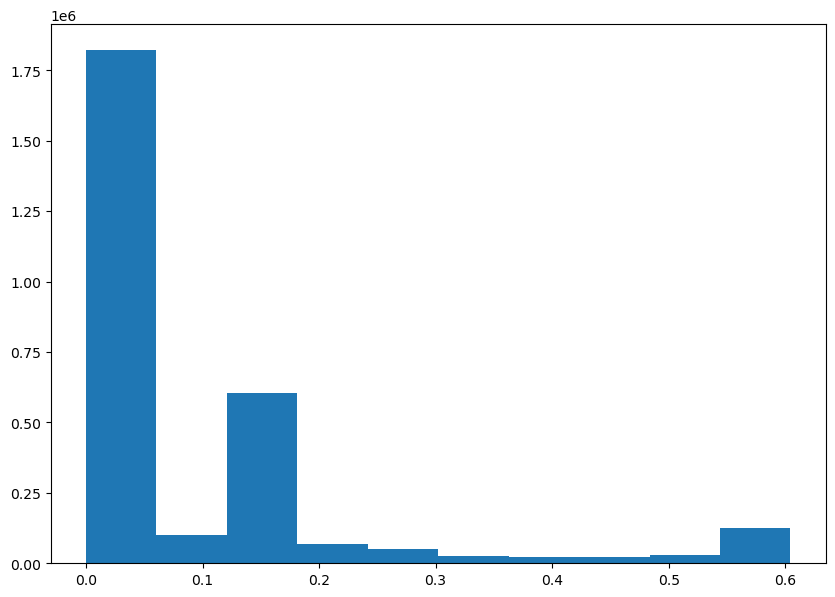

In [14]:
print(np.array(list(component_indices['melts-liquid'].values()))[np.arange(1,len(Oxides)+1)])
print(component_indices['melts-liquid'])
print(oxToEl)
print(Minv)
del Big_Table.molar
gc.collect()
#Big_Table.table1 = np.copy(Big_Table.table)
retrieve_component_moles(Big_Table)

plt.hist(Big_Table.molar[:,-2])

In [46]:
for i, name in enumerate(Big_Table.header):
    print(f"{i}:{name}")
print(label_indices['clinopyroxene'][1:8])
print(np.arange(20)[10:17])

0:Pressure(System_main)
1:Temperature(System_main)
2:logfO2-QFM(System_main)
3:mass (gm)(olivine)
4:tephroite(olivine)
5:fayalite(olivine)
6:ni-olivine(olivine)
7:monticellite(olivine)
8:forsterite(olivine)
9:mass (gm)(orthopyroxene)
10:diopside(orthopyroxene)
11:clinoenstatite(orthopyroxene)
12:hedenbergite(orthopyroxene)
13:alumino-buffonite(orthopyroxene)
14:buffonite(orthopyroxene)
15:essenite(orthopyroxene)
16:jadeite(orthopyroxene)
17:mass (gm)(clinopyroxene)
18:diopside(clinopyroxene)
19:clinoenstatite(clinopyroxene)
20:hedenbergite(clinopyroxene)
21:alumino-buffonite(clinopyroxene)
22:buffonite(clinopyroxene)
23:essenite(clinopyroxene)
24:jadeite(clinopyroxene)
25:mass (gm)(spinel)
26:chromite(spinel)
27:hercynite(spinel)
28:magnetite(spinel)
29:spinel(spinel)
30:ulvospinel(spinel)
31:mass (gm)(plagioclase)
32:albite(plagioclase)
33:anorthite(plagioclase)
34:highsanidine(plagioclase)
35:mass (gm)(k-feldspar)
36:albite(k-feldspar)
37:anorthite(k-feldspar)
38:sanidine(k-feldspar)

In [5]:
Big_Table = BigMetaTable('MELTS_TrainsetJune27MnNiFree_Cooling')
print(Big_Table.table.size)

[TIMER] Parsed Metadata to Lists: completed in 3.14 seconds
[TIMER] Metadata Lists to arrays: completed in 1.75 seconds
[INFO] Preparing to process ~2872344 rows with 137 columns...


[INFO] Loaded 2872344 valid rows into memmap (skipped 0)
[TIMER] Completed in 117.65 seconds
393511128


In [16]:
del Big_Table.molar
gc.collect()

633

(array([2.748454e+06, 4.956500e+04, 4.502800e+04, 2.878500e+04,
        3.090000e+02, 6.800000e+01, 8.900000e+01, 1.000000e+01,
        1.300000e+01, 2.300000e+01]),
 array([ 0.        ,  9.89591026, 19.79182053, 29.68772888, 39.58364105,
        49.47954941, 59.37545776, 69.27136993, 79.1672821 , 89.06318665,
        98.95909882]),
 <BarContainer object of 10 artists>)

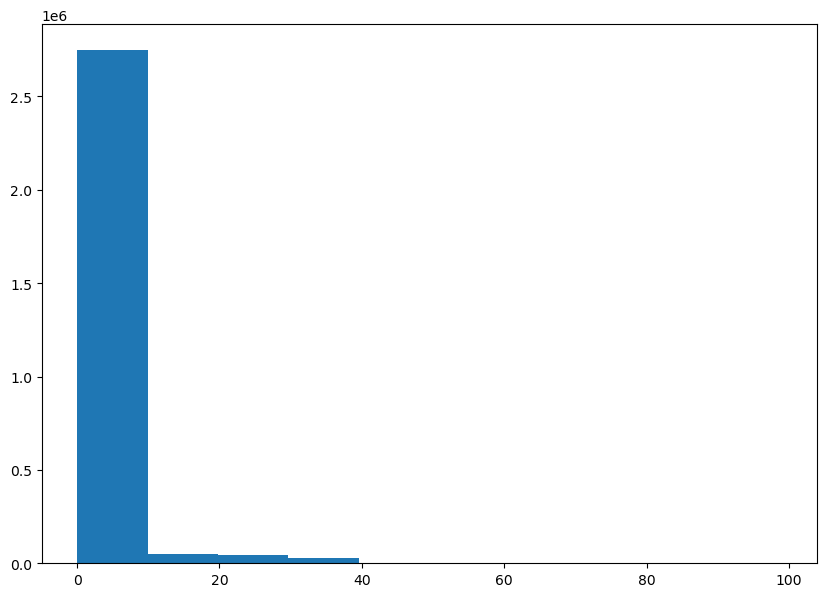

In [6]:
plt.hist(Big_Table.table[:,component_indices['melts-liquid']['wt% H2O']])

[[1.         0.         0.         0.         0.         0.
  0.        ]
 [0.5        0.         0.         0.         0.         0.
  0.5       ]
 [0.66666667 0.33333333 0.         0.         0.         0.
  0.        ]
 [0.5        0.         0.25       0.25       0.         0.
  0.        ]
 [0.5        0.         0.25       0.         0.25       0.
  0.        ]
 [0.5        0.         0.         0.25       0.25       0.
  0.        ]
 [0.4        0.         0.         0.2        0.         0.4
  0.        ]]


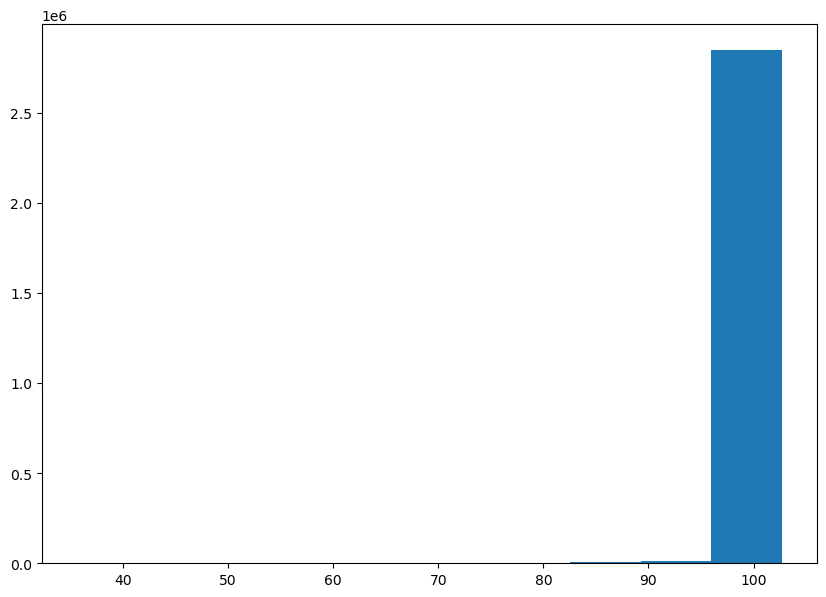

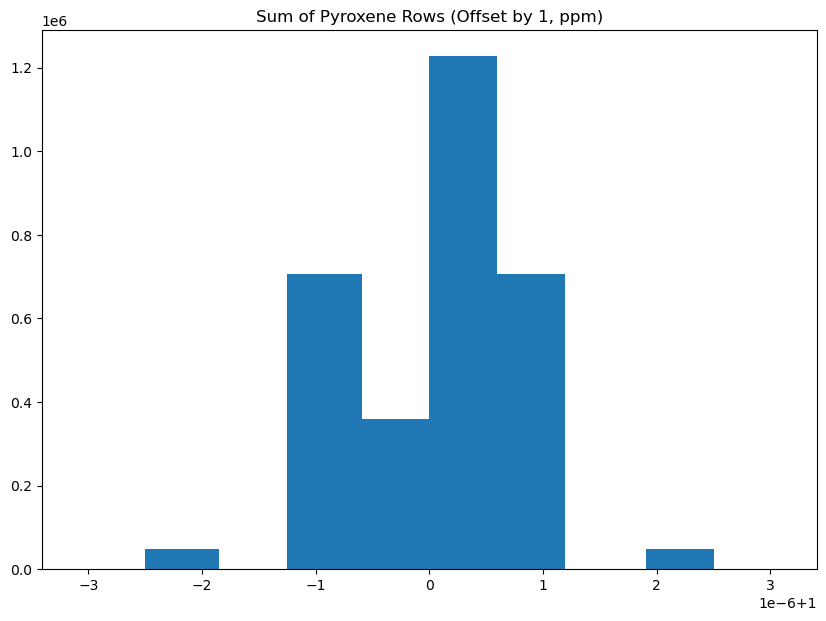

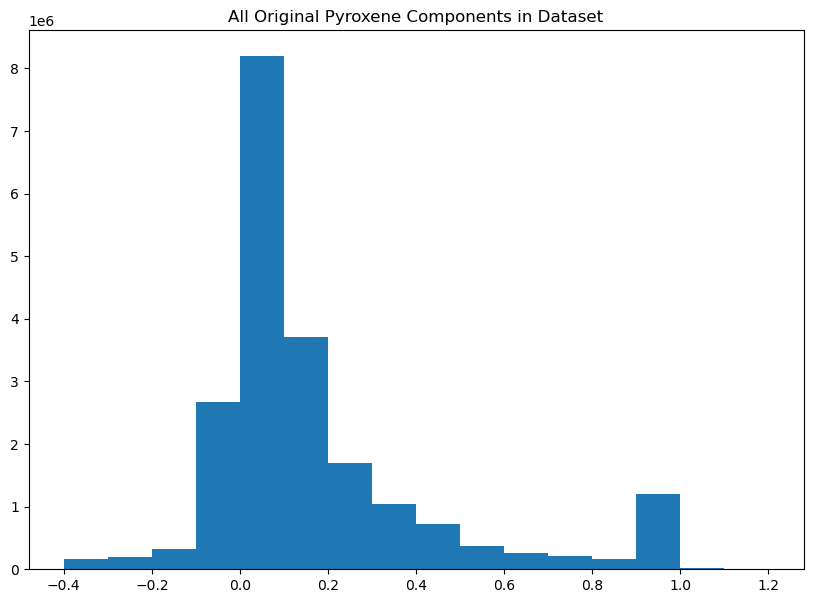

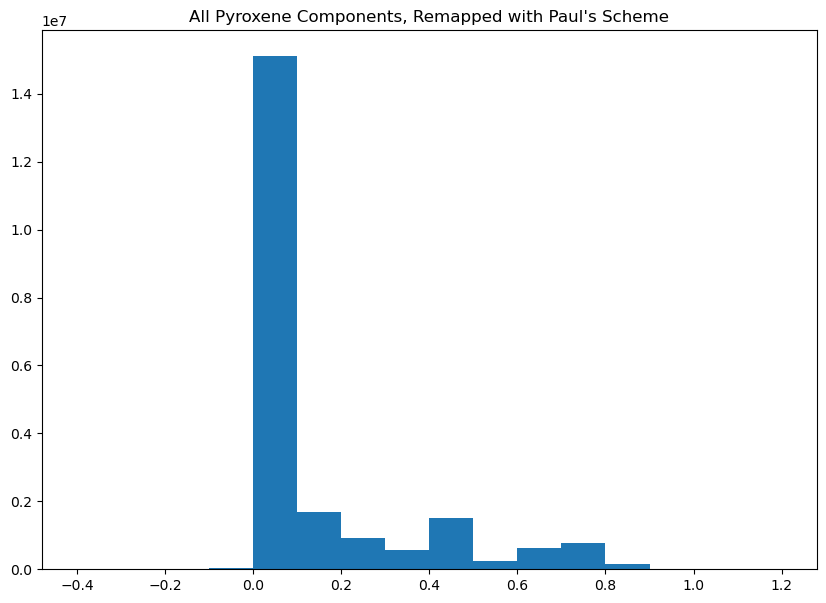

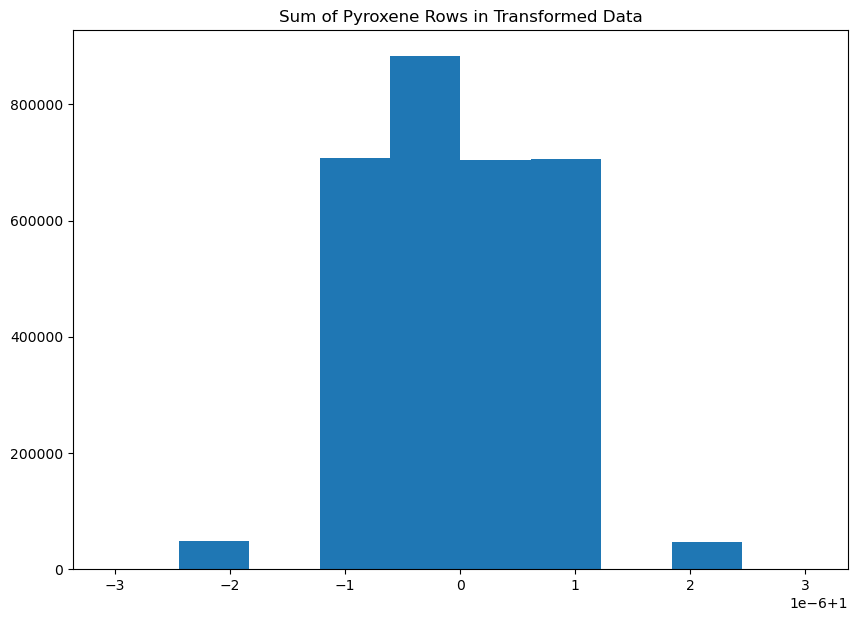

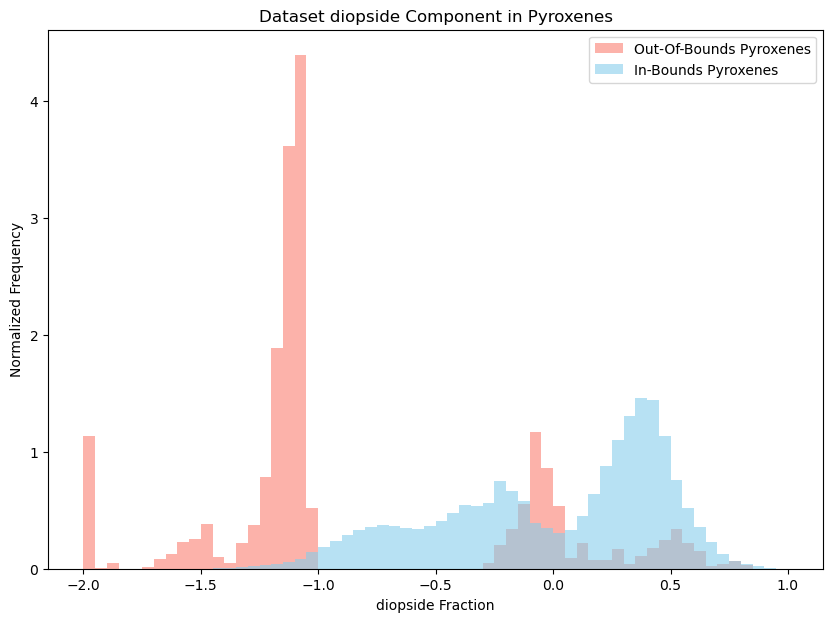

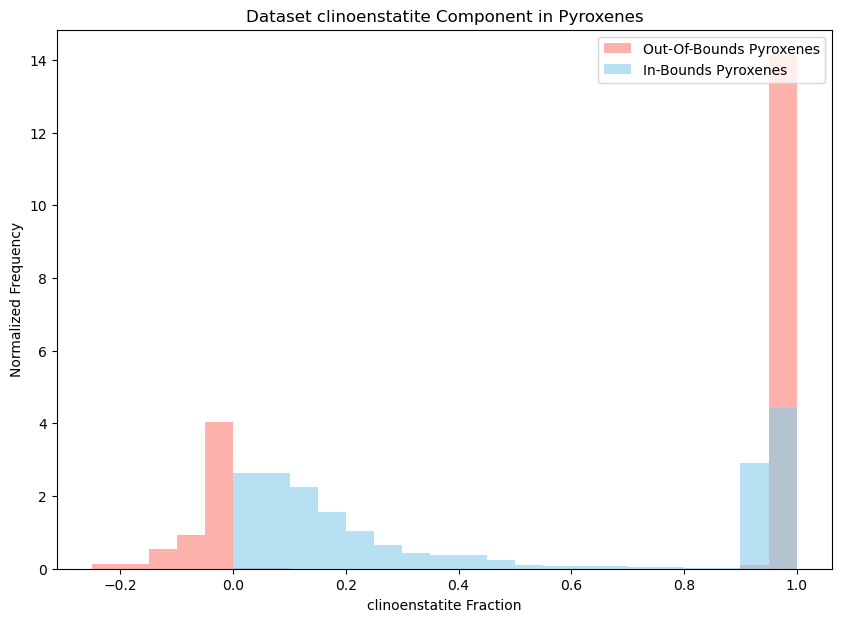

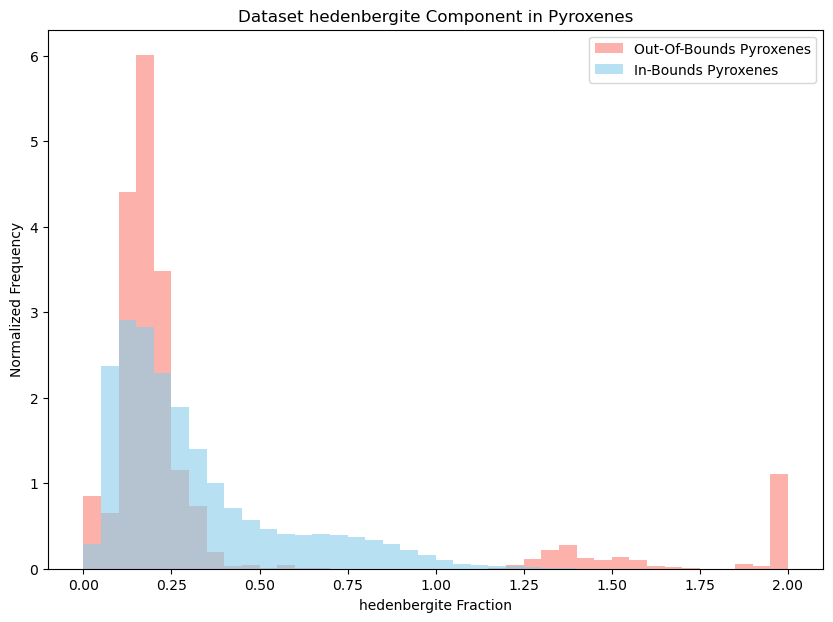

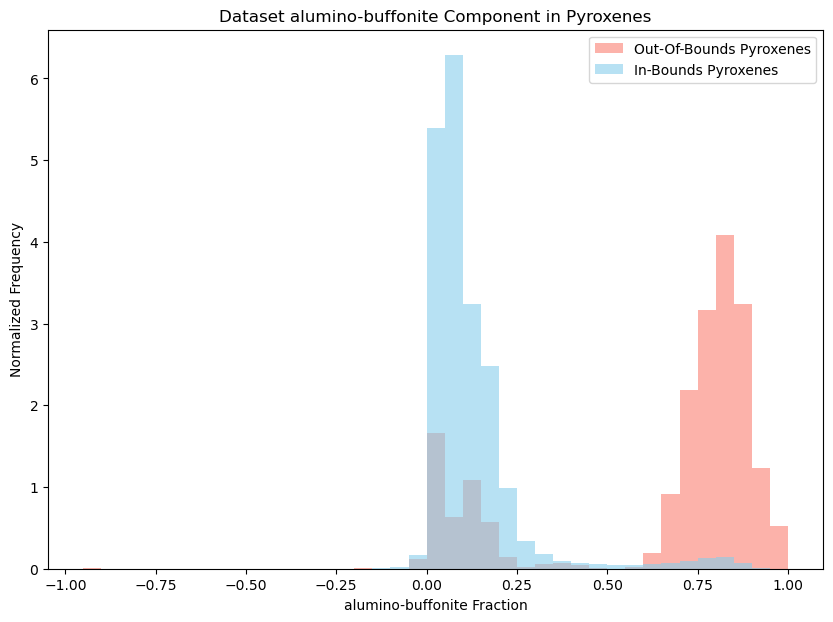

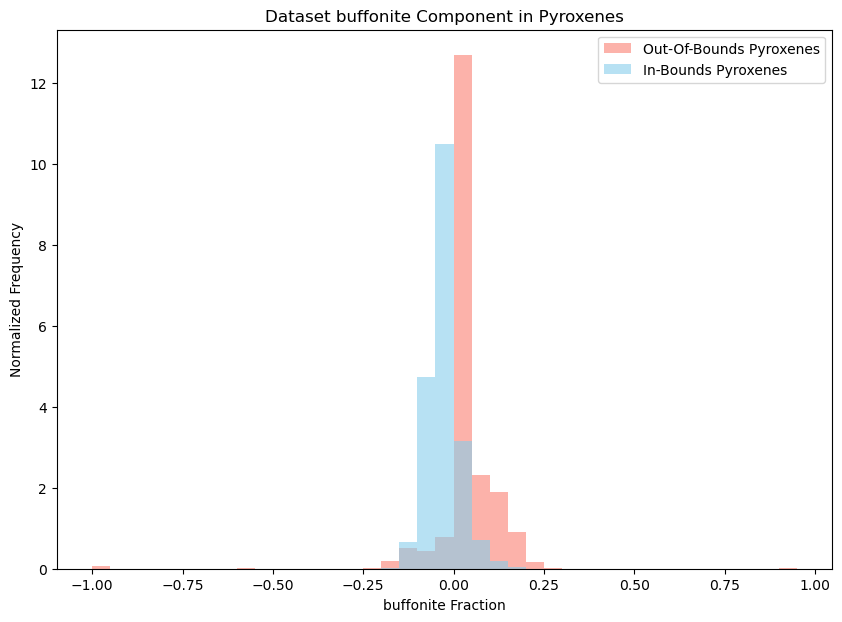

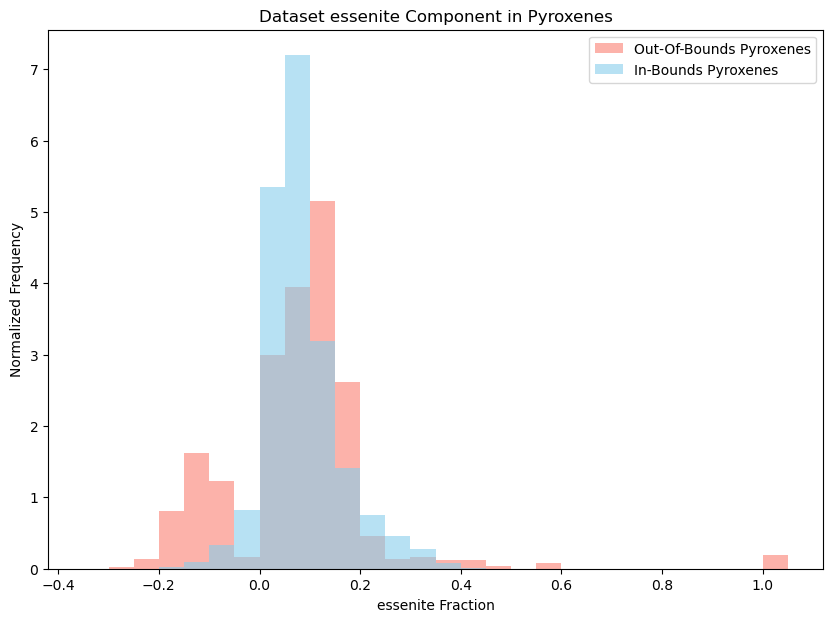

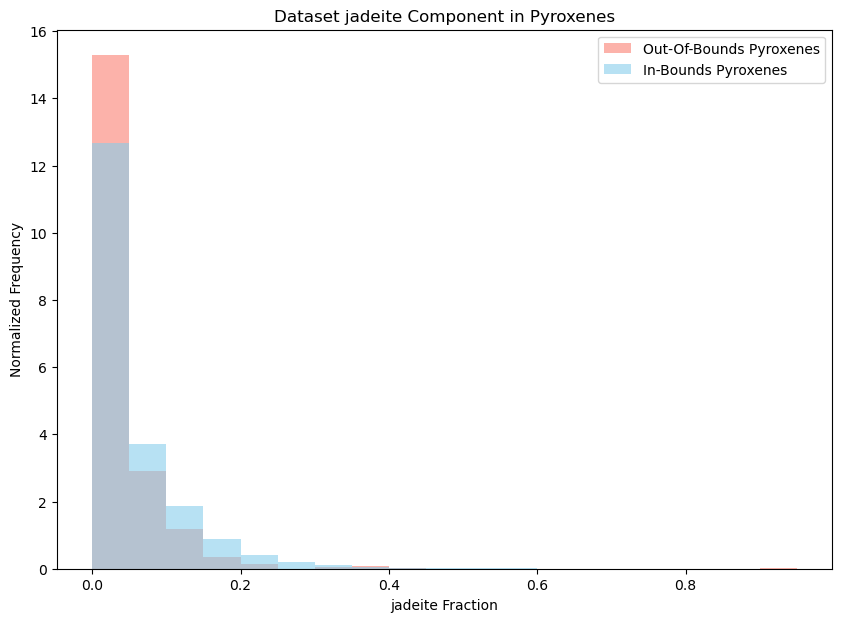

In [44]:
px_names = ['diopside',
 'clinoenstatite',
 'hedenbergite',
 'alumino-buffonite',
 'buffonite',
 'essenite',
 'jadeite'] # Paul's ordering is the same as MELTS, as is this model's

"""g2x = np.array([[1,-2,-1,-1,-1,-0.5,-1],
               [0,0,0,0,0,0,1],
               [0,2,0,0,0,0,0],
               [0,0,1,1,-1,-0.5,0],
               [0,0,1,-1,1,0.5,0],
               [0,0,-1,1,1,-0.5,0],
               [0,0,0,0,0,1,0]]).T"""
"""x2g = np.array([[1,-2,-1,-1,-1,-0.5,-1],
               [0,0,0,0,0,0,1],
               [0,2,0,0,0,0,0],
               [0,0,1,1,-1,-0.5,0],
               [0,0,1,-1,1,0.5,0],
               [0,0,-1,1,1,-0.5,0],
               [0,0,0,0,0,1,0]])"""

x2g = np.array([[1,0,0,0,0,0,0],
               [0.5,0,0,0,0,0,0.5],
               [2/3,1/3,0,0,0,0,0],
               [0.5,0,0.25,0.25,0,0,0],
               [0.5,0,0.25,0,0.25,0,0],
               [0.5,0,0,0.25,0.25,0,0],
               [0.4,0,0,0.2,0,0.4,0]])

#x2g = (np.where(g2x!=0, 1/g2x, 0)).T
#x2g = np.linalg.inv(g2x)
g2x = np.linalg.inv(x2g)

print(x2g)
#g2x = np.linalg.pinv(M_opt)
#print(

"""      1     –2        –1        –1         –1    –0.5      –1
      0     0     0     0     0     0     1 
      0       2      0      0        0       0            0  
      0     0     1          1          –1     –0.5      0
      0     0     1          –1          1     +0.5      0
      0     0     –1          1          1     –0.5      0
      0     0     0     0     0     1     0"""
"""# Paul's x2g
      #0     0    0.5     0     0     0     0
      #0     0     0     0.5    0.5     0     0
      #0     0     0    0.5    0     0.5   0.5
      #0     0     0     0    0.5    0.5    0
      #0     0     0     0     0     0     1
      #0     1     0     0     0     0     0"""

plt.hist(np.sum(Big_Table.table[:,mass_indices], axis=1))
plt.show()
cpx_present = Big_Table.table[:,component_indices['clinopyroxene']['mass (gm)']] != 0
opx_present = Big_Table.table[:,component_indices['orthopyroxene']['mass (gm)']] != 0

px_components = np.append(Big_Table.table[np.ix_(opx_present,np.arange(10,17))],Big_Table.table[np.ix_(cpx_present,np.arange(18,25))],axis = 0)
#px_components = Big_Table.table[np.ix_(cpx_present,np.arange(18,25))]

plt.hist(np.sum(px_components, axis = 1))
plt.title('Sum of Pyroxene Rows (Offset by 1, ppm)')
#plt.savefig('PxCompSumHist.png')
plt.show()

plt.hist(px_components.flatten(), bins = np.linspace(-0.4,1.2,17))
plt.title('All Original Pyroxene Components in Dataset')
#plt.savefig('PxCompsHist.png')
plt.show()

#plt.hist(px_components[np.where(cpx_components < 0)])
#plt.show()

transformed_components = px_components @ x2g
plt.hist(transformed_components.flatten(), bins = np.linspace(-0.4,1.2,17))
plt.title("All Pyroxene Components, Remapped with Paul's Scheme")
plt.savefig('PaulPXremap.png')
plt.show()

plt.hist(np.sum(transformed_components, axis=1))
plt.title('Sum of Pyroxene Rows in Transformed Data')
plt.savefig('PaulPxSumHist.png')
plt.show()

retransformed_components = transformed_components @ g2x


"""plt.plot([-2,2],[-2,2], linestyle = '--', color = 'black')
plt.scatter(px_components,retransformed_components, s= 5, alpha = 0.4)
plt.title('Pyroxene Remapping to MELTS Components')
plt.xlabel('Original MELTS Components')
plt.ylabel('Remapped MELTS Components')
plt.savefig('PaulPXRemapping.png')
plt.show()"""

#OOB = ((transformed_components > 1).astype(float) + (transformed_components < 0).astype(float)).astype(bool)
Bad_Row = np.unique(np.where(OOB)[0])
Good_Row = np.arange(transformed_components.shape[0])
Good_Row = Good_Row[~np.isin(Good_Row, Bad_Row)] # Exclude OOB IDs

def make_bins(data, bin_size = 0.2):
    bottom = (np.min(data) // bin_size)*bin_size
    top = ((np.max(data) // bin_size)*bin_size)+(1*bin_size)
    return np.linspace(bottom, top, 1+int((top-bottom)/bin_size))

colnames = np.array(['diopside', 'clinoenstatite', 'hedenbergite', 'alumino-buffonite', 'buffonite', 'essenite', 'jadeite'])
for i, name in enumerate(colnames):
    bins = make_bins(px_components[:,i], 0.05)
    plt.hist(px_components[Bad_Row,i], density = True, color = 'salmon', alpha = 0.6, label = 'Out-Of-Bounds Pyroxenes', bins = bins)
    plt.hist(px_components[Good_Row,i], density = True, color = 'skyblue', alpha = 0.6, label = 'In-Bounds Pyroxenes', bins = bins)
    plt.legend(loc = 'upper right')
    plt.title(f'Dataset {name} Component in Pyroxenes')
    plt.ylabel('Normalized Frequency')
    plt.xlabel(f'{name} Fraction')
    plt.savefig(f'Dataset{name}')
    plt.show()

In [9]:
rand_IDs = np.random.choice(np.arange(px_components.shape[0]),size = 1000, replace = False)
colnames = np.array(['diopside', 'clinoenstatite', 'hedenbergite', 'alumino-buffonite', 'buffonite', 'essenite', 'jadeite'])
pd.DataFrame(px_components[rand_IDs], columns = colnames).to_csv('Pyroxene_Comps.csv')

In [43]:
rand_IDs = np.random.choice(np.arange(px_components.shape[0]),size = 1000, replace = False)
colnames = np.array(['diopside', 'clinoenstatite', 'hedenbergite', 'alumino-buffonite', 'buffonite', 'essenite', 'jadeite'])
pd.DataFrame(px_components[rand_IDs], columns = colnames).to_csv('Pyroxene_Comps.csv')

array([-2. , -1.8, -1.6, -1.4, -1.2, -1. , -0.8, -0.6, -0.4, -0.2,  0. ,
        0.2,  0.4,  0.6,  0.8,  1. ])

In [155]:

for i, name in enumerate(Big_Table.header):
    print(f"{i}:{name}")
    
print(component_indices['clinopyroxene'])

0:Pressure(System_main)
1:Temperature(System_main)
2:logfO2-QFM(System_main)
3:mass (gm)(olivine)
4:tephroite(olivine)
5:fayalite(olivine)
6:ni-olivine(olivine)
7:monticellite(olivine)
8:forsterite(olivine)
9:mass (gm)(orthopyroxene)
10:diopside(orthopyroxene)
11:clinoenstatite(orthopyroxene)
12:hedenbergite(orthopyroxene)
13:alumino-buffonite(orthopyroxene)
14:buffonite(orthopyroxene)
15:essenite(orthopyroxene)
16:jadeite(orthopyroxene)
17:mass (gm)(clinopyroxene)
18:diopside(clinopyroxene)
19:clinoenstatite(clinopyroxene)
20:hedenbergite(clinopyroxene)
21:alumino-buffonite(clinopyroxene)
22:buffonite(clinopyroxene)
23:essenite(clinopyroxene)
24:jadeite(clinopyroxene)
25:mass (gm)(spinel)
26:chromite(spinel)
27:hercynite(spinel)
28:magnetite(spinel)
29:spinel(spinel)
30:ulvospinel(spinel)
31:mass (gm)(plagioclase)
32:albite(plagioclase)
33:anorthite(plagioclase)
34:highsanidine(plagioclase)
35:mass (gm)(k-feldspar)
36:albite(k-feldspar)
37:anorthite(k-feldspar)
38:sanidine(k-feldspar)

In [55]:
spinel_elements = Big_Table.table[sp_]

tensor([[0.0111, 0.0301, 0.0819, 0.2225, 0.6048, 0.0496]])

tensor([[ 1.0001e+00, -0.0000e+00, -0.0000e+00,  0.0000e+00, -0.0000e+00,
         -0.0000e+00, -0.0000e+00],
        [ 5.3463e-01,  4.6546e-01, -0.0000e+00, -0.0000e+00,  0.0000e+00,
          0.0000e+00, -0.0000e+00],
        [ 7.3329e-01, -3.5248e-02,  3.0205e-01,  0.0000e+00,  0.0000e+00,
          0.0000e+00, -0.0000e+00],
        [ 5.7879e-01, -2.0613e-01,  8.1360e-02,  5.4608e-01, -0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.2031e-02, -1.1520e-01,  2.7668e-01,  4.0626e-01,  4.1028e-01,
         -0.0000e+00, -0.0000e+00],
        [ 4.2335e-01, -3.8422e-01,  9.6365e-02,  1.4809e-01,  4.2072e-01,
          2.9580e-01,  0.0000e+00],
        [-8.8735e-02,  7.9773e-01, -4.0718e-01,  1.3005e-01,  4.0041e-06,
          5.6135e-01,  7.5149e-03]])
tensor([1.0001, 1.0001, 1.0001,  ..., 1.0001, 1.0001, 1.0001])


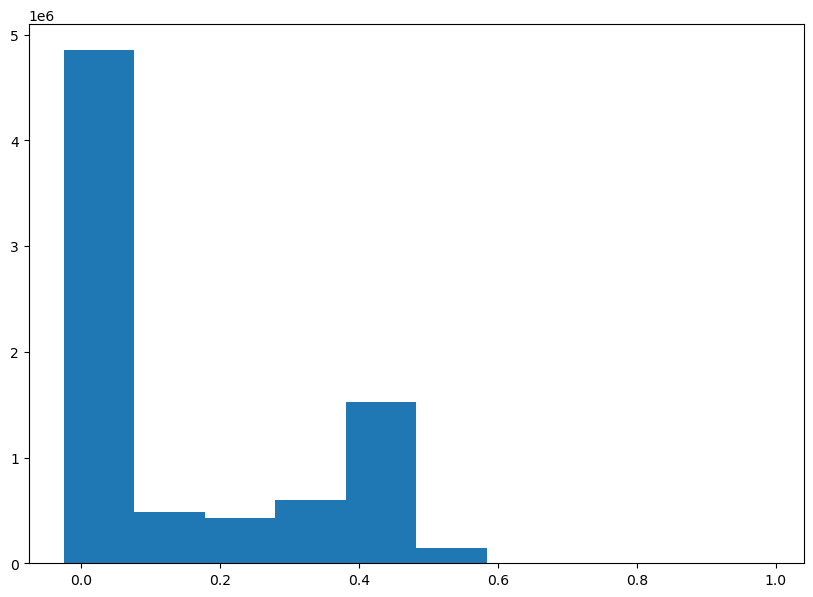

lr = 0.01
Step 0: Loss = 0.040998
lr = 0.01
Step 500: Loss = -0.000127
lr = 0.01
Step 1000: Loss = -0.000140
lr = 0.01
Step 1500: Loss = -0.000133
lr = 0.01
Step 2000: Loss = -0.000140
lr = 0.01
Step 2500: Loss = -0.000142
lr = 0.01
Step 3000: Loss = -0.000142
lr = 0.01
Step 3500: Loss = -0.000142
lr = 0.01
Step 4000: Loss = -0.000143
lr = 0.01
Step 4500: Loss = -0.000143
lr = 0.001
Step 5000: Loss = -0.000143
lr = 0.001
Step 5500: Loss = -0.000143
lr = 0.001
Step 6000: Loss = -0.000143
lr = 0.001
Step 6500: Loss = -0.000143
lr = 0.001
Step 7000: Loss = -0.000143
lr = 0.001
Step 7500: Loss = -0.000143
lr = 0.001
Step 8000: Loss = -0.000143
lr = 0.001
Step 8500: Loss = -0.000143
lr = 0.001
Step 9000: Loss = -0.000143
lr = 0.001
Step 9500: Loss = -0.000143
lr = 0.0001
Step 10000: Loss = -0.000143
lr = 0.0001
Step 10500: Loss = -0.000143
lr = 0.0001
Step 11000: Loss = -0.000143
lr = 0.0001
Step 11500: Loss = -0.000143
lr = 0.0001
Step 12000: Loss = -0.000143
lr = 0.0001
Step 12500: Loss =

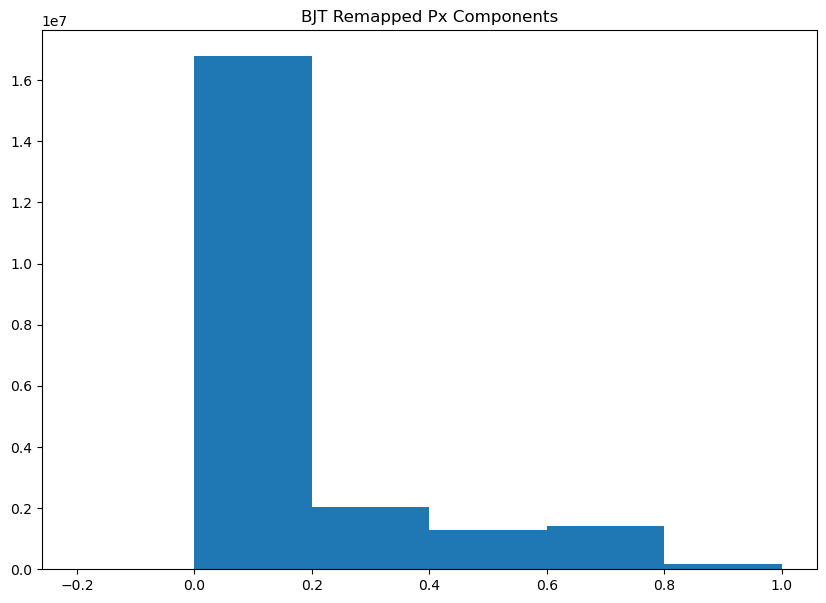

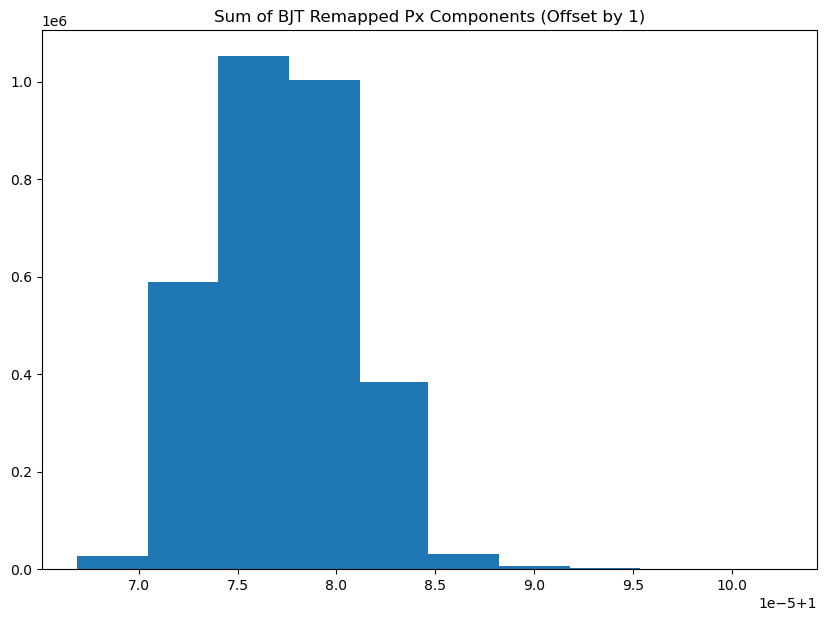

tensor(104)


In [164]:
import torch
import torch.nn as nn
import torch.optim as optim

def solve_remap_with_leakyrelu(X, lr=1e-2, steps=10000, leak=0.001, verbose=False):
    """
    Solves for matrix A such that X @ A ≈ G using gradient descent
    with a LeakyReLU penalty on negative predicted G.

    Parameters:
        X (torch.Tensor): Shape (n_samples, n_features)
        G (torch.Tensor): Shape (n_samples, n_targets)
        lr (float): Learning rate
        steps (int): Number of optimization steps
        leak (float): Negative slope for LeakyReLU
        verbose (bool): Print loss every 100 steps

    Returns:
        A (torch.Tensor): Shape (n_features, n_targets)
    """

    # Ensure float tensors
    X = X.float()
    #G = G.float()

    # Initialize A with requires_grad=True
    A = torch.randn(X.size()[1], X.size()[1], requires_grad=True, device = 'cuda')

    # LeakyReLU for penalizing negative values
    leaky_relu = nn.LeakyReLU(negative_slope=leak)

    optimizer = optim.Adam([A], lr=lr)

    for step in range(steps):
        optimizer.zero_grad()

        # Predicted G
        G_pred = X @ A

        # Reconstruction loss (MSE)
        mse_loss = torch.mean((1-G_pred.sum(dim=1))**2)

        # Negative penalty: Apply LeakyReLU to -G_pred so negatives are penalized
        neg_penalty = torch.mean(leaky_relu(-G_pred))
        #print(f"MSE Loss / neg_penalty: {mse_loss/neg_penalty}")
        # Total loss
        loss = mse_loss + neg_penalty

        loss.backward()
        optimizer.step()

        if verbose and step % 100 == 0:
            print(f"Step {step}: Loss={loss.item():.6f}, MSE={mse_loss.item():.6f}, NegPenalty={neg_penalty.item():.6f}")

    return A.detach()

#A = solve_remap_with_leakyrelu(torch.tensor(cpx_components, requires_grad=True, device = 'cuda'), verbose = True).detach().cpu()
print(A)
print((torch.tensor(cpx_components) @ A).sum(dim=1))
plt.hist((torch.tensor(cpx_components) @ A).detach().numpy().flatten())
plt.show()

import torch
import torch.nn as nn
import torch.optim as optim

def solve_masked_A(x, mask=None, lr=0.01, steps=20000, leak=0.001, seed=0):
    """
    Solve for matrix A such that x @ A = g
    using gradient descent on a leaky ReLU loss of -g,
    with some entries fixed to zero but keeping A invertible.

    Args:
        x: (B, N) tensor
        g: (B, M) tensor
        mask: (N, M) binary mask where 1 = learnable, 0 = fixed zero
        lr: learning rate
        steps: number of gradient descent steps
        leak: negative slope for leaky ReLU
        seed: random seed for reproducibility
    """
    torch.manual_seed(seed)

    N = x.shape[1]

    if mask is None:
        # Default mask: lower-triangular with ones, so guaranteed full rank
        mask = torch.tril(torch.ones(N, N, device='cuda'))

    mask = mask.to(torch.float32)

    # Initialize A with small random numbers where mask = 1
    A_params = nn.Parameter(torch.randn(N, N, device = 'cuda') * 0.1)

    # Keep diagonal entries nonzero for invertibility
    with torch.no_grad():
        for i in range(min(N, N)):
            if mask[i, i] == 1:
                A_params[i, i] = 1.0

    
    optimizer = optim.Adam([A_params], lr=lr)
    activation = nn.LeakyReLU(negative_slope=leak)

    for step in range(steps):
        A = A_params * mask  # Apply mask
        pred = x @ A
        mse_loss = torch.mean((1-pred.sum(dim=1))**2)
        neg_penalty = torch.mean(leaky_relu(-pred))
        
        loss = mse_loss + neg_penalty  # Leaky ReLU loss on -pred

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Re-enforce diagonal non-zeros for invertibility
        with torch.no_grad():
            for i in range(N):
                if mask[i, i] == 1 and A_params[i, i].abs() < 1e-3:
                    A_params[i, i] = 1.0

        if step % 500 == 0:
            print(f"lr = {lr}")
            print(f"Step {step}: Loss = {loss.item():.6f}")

        if (step+1) % 5000 == 0:
            lr /= 10
            optimizer = optim.Adam([A_params], lr=lr)
            
        """        if (step+1) % 7500 == 0:
            lr /= 10
            optimizer = optim.Adam([A_params], lr=lr)"""
        
    return (A_params * mask).detach()


Apx = solve_masked_A(torch.tensor(px_components, requires_grad=True, device = 'cuda'), steps = 15000).detach().cpu().numpy()
print(Apx)
print((torch.tensor(px_components) @ Apx).sum(dim=1))
plt.hist((torch.tensor(px_components) @ Apx).detach().numpy().flatten(), bins = [-0.2,0,0.2,0.4,0.6,0.8,1.0])
plt.title('BJT Remapped Px Components')
plt.savefig('BJTPxRemapedComps.png')

plt.show()

plt.hist((torch.tensor(px_components) @ Apx).sum(dim=1))
plt.title('Sum of BJT Remapped Px Components (Offset by 1)')
plt.savefig('BJTPxRemapSums.png')
plt.show()
print(((torch.tensor(px_components) @ Apx) > 1).sum() + ((torch.tensor(px_components) @ Apx) < 0).sum())


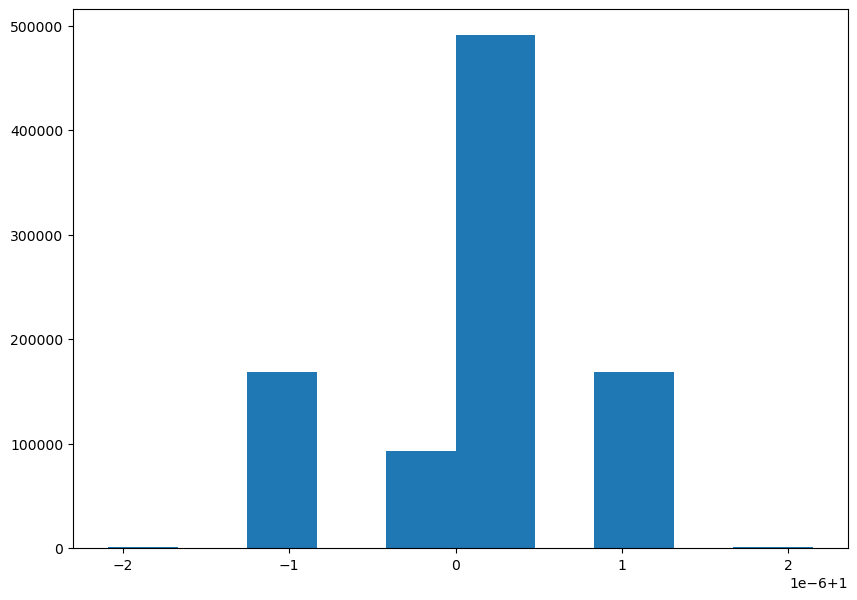

lr = 0.01
Step 0: Loss = 0.061666
lr = 0.01
Step 500: Loss = -0.000183
lr = 0.01
Step 1000: Loss = -0.000198
lr = 0.01
Step 1500: Loss = -0.000199
lr = 0.01
Step 2000: Loss = -0.000200
lr = 0.001
Step 2500: Loss = -0.000200
lr = 0.001
Step 3000: Loss = -0.000200
lr = 0.001
Step 3500: Loss = -0.000200
lr = 0.001
Step 4000: Loss = -0.000200
lr = 0.001
Step 4500: Loss = -0.000200
lr = 0.0001
Step 5000: Loss = -0.000200
lr = 0.0001
Step 5500: Loss = -0.000200
lr = 0.0001
Step 6000: Loss = -0.000200
lr = 0.0001
Step 6500: Loss = -0.000200
lr = 0.0001
Step 7000: Loss = -0.000200
lr = 1e-05
Step 7500: Loss = -0.000200
lr = 1e-05
Step 8000: Loss = -0.000200
lr = 1e-05
Step 8500: Loss = -0.000200
lr = 1e-05
Step 9000: Loss = -0.000200
lr = 1e-05
Step 9500: Loss = -0.000200
[[  1.00   0.00   0.00   0.00   0.00]
 [  0.00   1.00   0.00   0.00   0.00]
 [  0.00   0.40   0.60   0.00   0.00]
 [  0.00   0.95   0.00   0.05   0.00]
 [  0.00   0.28   0.00   0.00   0.72]]


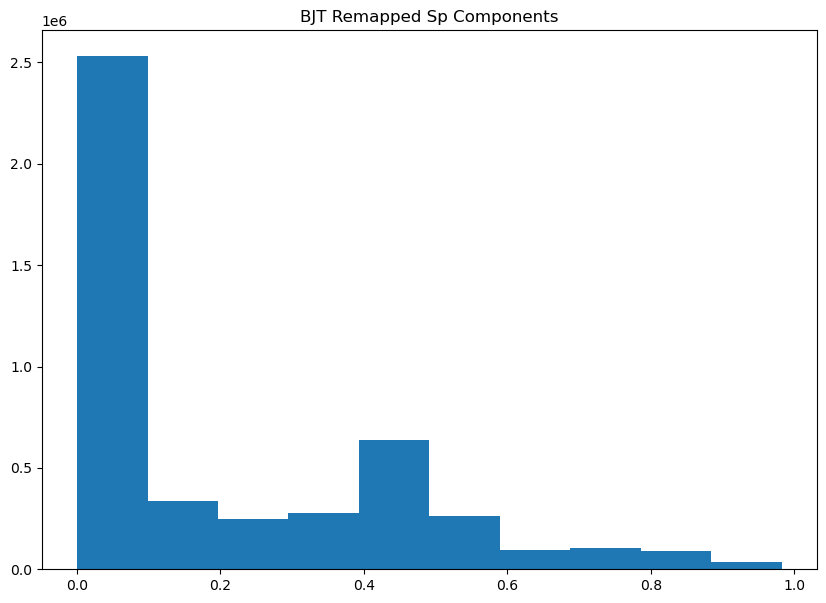

MINIMUM REMAP: 0.0, MAXIMUM: 0.9824732542037964


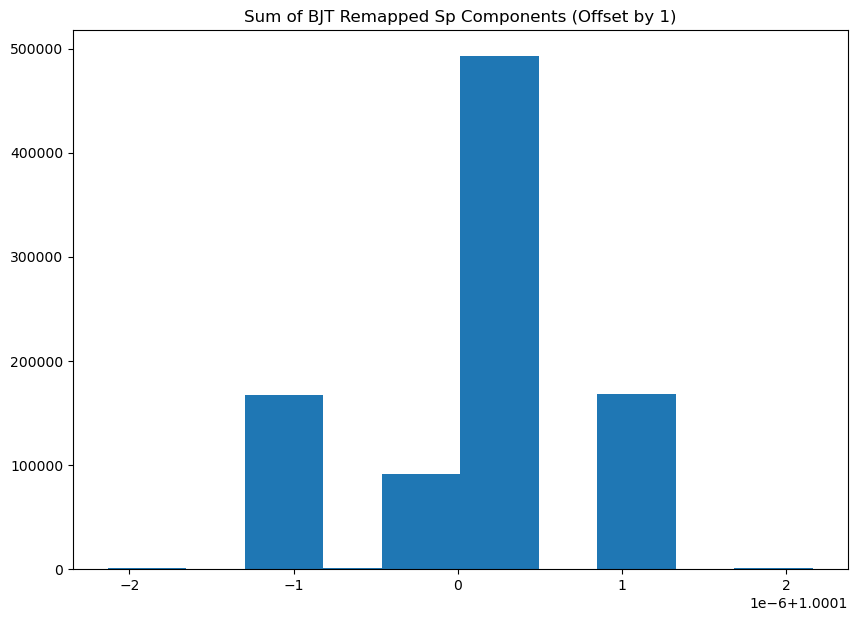

NameError: name 'px_components' is not defined

In [13]:
"""Spinel Solver"""

import torch
import torch.nn as nn
import torch.optim as optim

def solve_masked_A(x, mask=None, lr=0.01, steps=20000, leak=0.001, seed=0):
    """
    Solve for matrix A such that x @ A = g
    using gradient descent on a leaky ReLU loss of -g,
    with some entries fixed to zero but keeping A invertible.

    Args:
        x: (B, N) tensor
        g: (B, M) tensor
        mask: (N, M) binary mask where 1 = learnable, 0 = fixed zero
        lr: learning rate
        steps: number of gradient descent steps
        leak: negative slope for leaky ReLU
        seed: random seed for reproducibility
    """
    torch.manual_seed(seed)

    N = x.shape[1]

    if mask is None:
        # Default mask: lower-triangular with ones, so guaranteed full rank
        mask = torch.tril(torch.ones(N, N, device='cuda'))

    mask = mask.to(torch.float32)
    mask[1:,0] = 0 #Reserve Chromite its own Component

    # Initialize A with small random numbers where mask = 1
    A_params = nn.Parameter(torch.randn(N, N, device = 'cuda') * 0.1)

    # Keep diagonal entries nonzero for invertibility
    with torch.no_grad():
        for i in range(min(N, N)):
            if mask[i, i] == 1:
                A_params[i, i] = 1.0

    best_loss = np.inf
    
    optimizer = optim.Adam([A_params], lr=lr)
    activation = nn.LeakyReLU(negative_slope=leak)

    for step in range(steps):
        A = A_params * mask  # Apply mask
        pred = x @ A
        mse_loss = torch.mean((1-pred.sum(dim=1))**2)
        neg_penalty = torch.mean(activation(-pred))
        
        loss = mse_loss + neg_penalty  # Leaky ReLU loss on -pred

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Re-enforce diagonal non-zeros for invertibility
        with torch.no_grad():
            for i in range(N):
                if mask[i, i] == 1 and A_params[i, i].abs() < 1e-3:
                    A_params[i, i] = 1.0
                    

        if step % 500 == 0:
            print(f"lr = {lr}")
            print(f"Step {step}: Loss = {loss.item():.6f}")
            if loss.item() < best_loss:
                with torch.no_grad():
                    best_loss = loss.item()
                    best_params = A_params.clone()
                
            for i in range(N):
                for j in range(N):
                    if A_params[i,j] < 0.05: # Zero out small coefficients
                        with torch.no_grad():
                            A_params[i,j] = 0

        if (step+1) % 2500 == 0:
            lr /= 10
            optimizer = optim.Adam([A_params], lr=lr)
            
        """        if (step+1) % 7500 == 0:
            lr /= 10
            optimizer = optim.Adam([A_params], lr=lr)"""
        
    return (A_params * mask).detach()



sp_present = np.where(Big_Table.table[:,component_indices['spinel']['mass (gm)']] != 0)[0]
sp_components = Big_Table.table[np.ix_(sp_present,np.arange(26,31))]

plt.hist(sp_components.sum(axis = 1))
plt.show()



Asp = solve_masked_A(torch.tensor(sp_components, requires_grad=True, device = 'cuda'), steps = 10000).detach().cpu().numpy()
AspInv = np.linalg.inv(Asp)


transformed = sp_components @ Asp
retransformed = transformed @ AspInv

print(np.array2string(Asp, formatter={'float_kind':lambda x: f"{x:6.2f}"}))
#print(transformed.sum(axis=1))
plt.hist((transformed).flatten())#, bins = [-0.2,0,0.2,0.4,0.6,0.8,1.0])
plt.title('BJT Remapped Sp Components')
plt.savefig('BJTSpRemapedComps.png')

plt.show()

print(f"MINIMUM REMAP: {np.min(transformed)}, MAXIMUM: {np.max(transformed)}")

plt.hist((transformed).sum(axis=1))
plt.title('Sum of BJT Remapped Sp Components (Offset by 1)')
plt.savefig('BJTSpRemapSums.png')
plt.show()
print((transformed > 1).sum() + (transformed < 0).sum())

plt.plot([-1.5,1.5],[-1.5,1.5], linestyle = '--', color = 'black')
plt.scatter(sp_components, retransformed, s= 5, alpha = 0.4)
#plt.scatter(sp_components[np.where(wrong_comps)[0]], retransformed[np.where(wrong_comps)[0]], s = 7, alpha = 0.7, marker = 'x', color = 'red')
plt.title('Spinel Remapping to MELTS Components')
plt.xlabel('Original MELTS Components')
plt.ylabel('Remapped MELTS Components')
plt.savefig('BJTrecastedSP.png')


[[  1.00   0.00   0.00   0.00   0.00]
 [  0.00   1.00   0.00   0.00   0.00]
 [  0.00   0.40   0.60   0.00   0.00]
 [  0.00   0.95   0.00   0.05   0.00]
 [  0.00   0.20   0.00   0.00   0.80]]
[[  1.00   0.00   0.00   0.00   0.00]
 [  0.00   1.00   0.00   0.00   0.00]
 [  0.00  -0.67   1.67   0.00   0.00]
 [  0.00 -19.00   0.00  20.00   0.00]
 [  0.00  -0.25   0.00   0.00   1.25]]


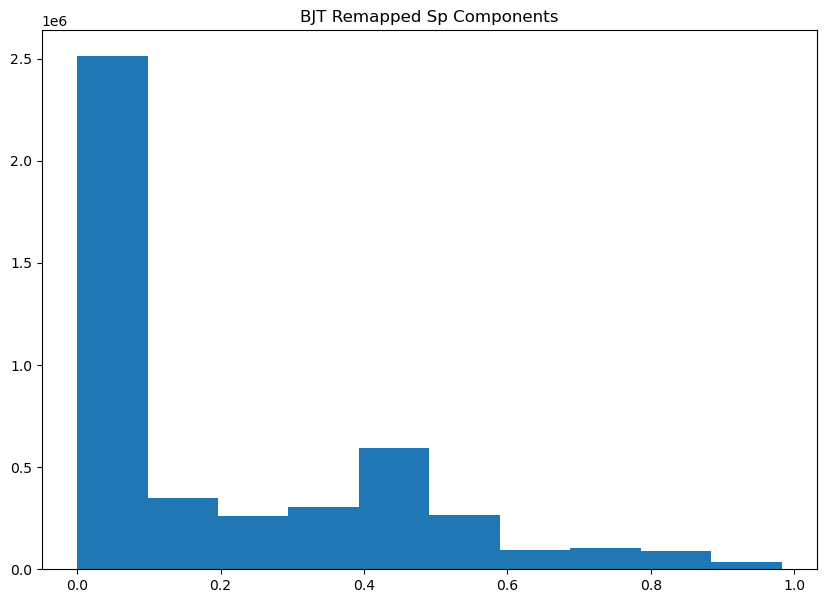

MINIMUM REMAP: 0.0, MAXIMUM: 0.9823750257492065


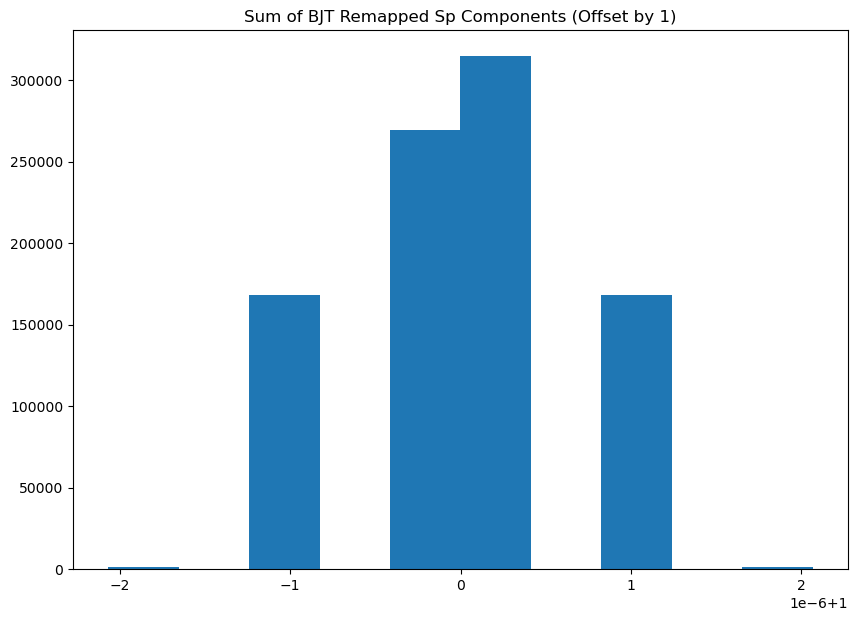

0


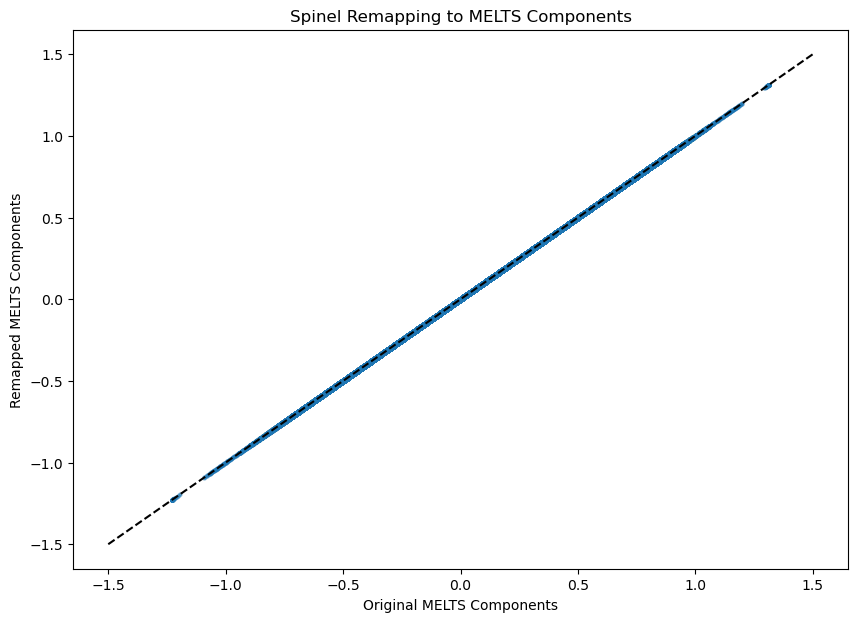

In [21]:
Asp = np.array([[  1.00,   0.00,  0.00,  0.00,   0.00],
 [  0.00,   1.00,   0.00,   0.00,   0.00],
 [  0.00,   0.40,   0.60,   0.00,   0.00],
 [  0.00,  0.95,   0.00,   0.05,  0.00],
 [  0.00,   0.2,   0.00,   0.00,  0.8]])
AspInv = np.linalg.inv(Asp)


transformed = sp_components @ Asp
retransformed = transformed @ AspInv

print(np.array2string(Asp, formatter={'float_kind':lambda x: f"{x:6.2f}"}))
print(np.array2string(AspInv, formatter={'float_kind':lambda x: f"{x:6.2f}"}))

#print(transformed.sum(axis=1))
plt.hist((transformed).flatten())#, bins = [-0.2,0,0.2,0.4,0.6,0.8,1.0])
plt.title('BJT Remapped Sp Components')
plt.savefig('BJTSpRemapedComps.png')

plt.show()

print(f"MINIMUM REMAP: {np.min(transformed)}, MAXIMUM: {np.max(transformed)}")

plt.hist((transformed).sum(axis=1))
plt.title('Sum of BJT Remapped Sp Components (Offset by 1)')
plt.savefig('BJTSpRemapSums.png')
plt.show()
print((transformed > 1).sum() + (transformed < 0).sum())

plt.plot([-1.5,1.5],[-1.5,1.5], linestyle = '--', color = 'black')
plt.scatter(sp_components, retransformed, s= 5, alpha = 0.4)
#plt.scatter(sp_components[np.where(wrong_comps)[0]], retransformed[np.where(wrong_comps)[0]], s = 7, alpha = 0.7, marker = 'x', color = 'red')
plt.title('Spinel Remapping to MELTS Components')
plt.xlabel('Original MELTS Components')
plt.ylabel('Remapped MELTS Components')
plt.savefig('BJTrecastedSP.png')

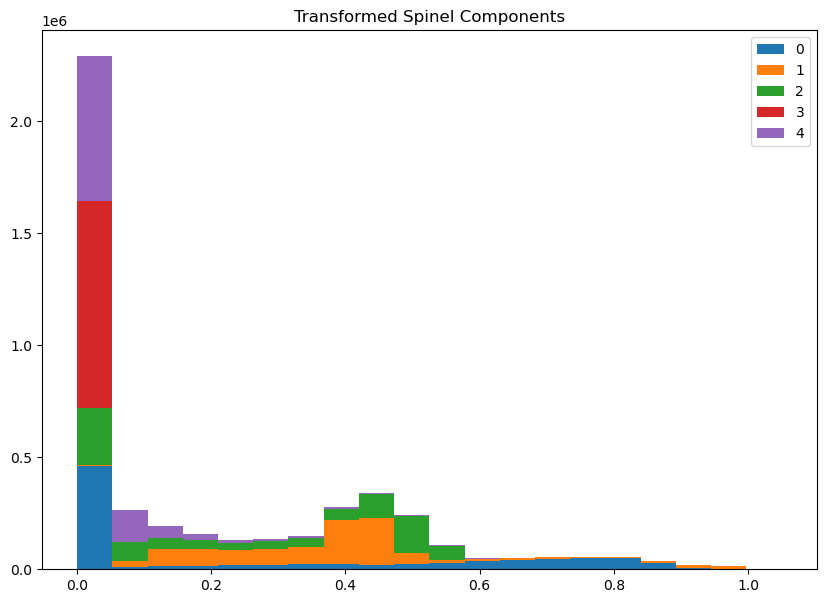

In [20]:
plt.hist([transformed[:,c] for c in np.arange(transformed.shape[1])],stacked=True,bins = np.linspace(0,1.05,21), label=np.arange(transformed.shape[1]))
plt.legend()
plt.title('Transformed Spinel Components')
plt.savefig('RecastSpHistogram.png')

[[ 1.     -0.     -0.      0.     -0.     -0.     -0.    ]
 [ 0.6558  0.3442 -0.     -0.      0.      0.     -0.    ]
 [ 0.6881 -0.0231  0.335   0.      0.      0.     -0.    ]
 [ 0.4588  0.1268  0.0066  0.4078 -0.      0.      0.    ]
 [ 0.3878 -0.114   0.      0.4019  0.3243 -0.     -0.    ]
 [ 0.4588  0.0714  0.0626  0.0807  0.3249  0.0016  0.    ]
 [ 0.0146  0.3078  0.      0.0034  0.0027  0.4183  0.2531]]
tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000])


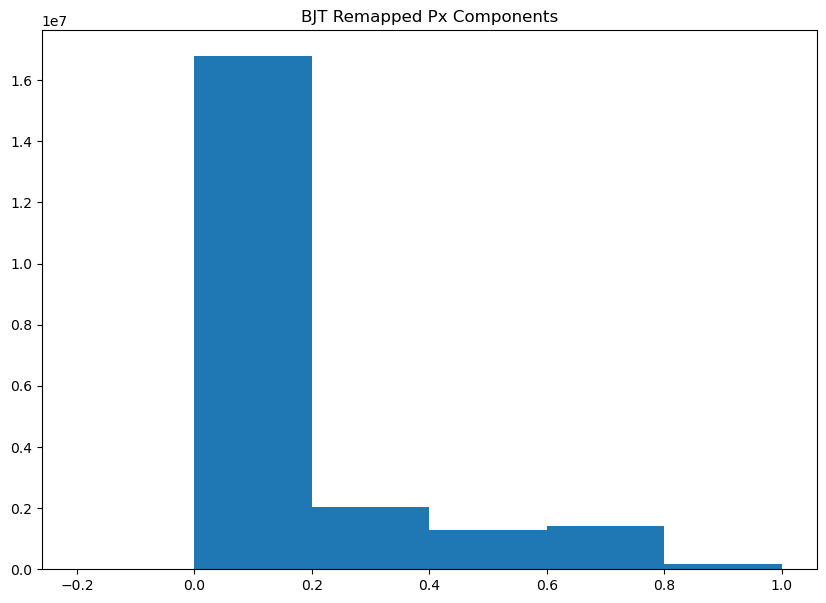

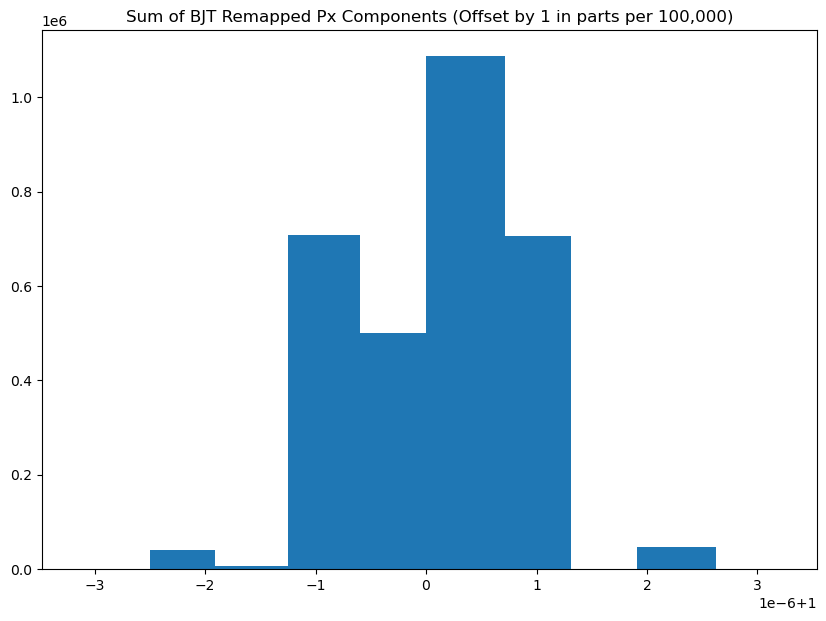

tensor(603)
[-0.0058]
(array([1345800], dtype=int64), array([1], dtype=int64))
(3096460, 7)
21675220
[[ 0.921  -0.0175  0.0292  0.0064  0.0569  0.0026  0.0015]]
[[False  True False False False False False]]
[[0.4549 0.3312 0.2053 ... 0.0014 0.0013 0.0007]
 [0.4508 0.3311 0.2095 ... 0.0014 0.0013 0.0007]
 [0.4468 0.3309 0.2137 ... 0.0014 0.0013 0.0007]
 ...
 [0.7379 0.0659 0.0573 ... 0.001  0.0344 0.0208]
 [0.7353 0.066  0.0576 ... 0.001  0.0345 0.0208]
 [0.7326 0.0661 0.0579 ... 0.001  0.0346 0.0209]]
[[0.4549 0.3312 0.2053 ... 0.0014 0.0013 0.0007]
 [0.4508 0.3311 0.2095 ... 0.0014 0.0013 0.0007]
 [0.4468 0.3309 0.2137 ... 0.0014 0.0013 0.0007]
 ...
 [0.7379 0.0659 0.0573 ... 0.001  0.0344 0.0208]
 [0.7353 0.066  0.0576 ... 0.001  0.0345 0.0208]
 [0.7326 0.0661 0.0579 ... 0.001  0.0346 0.0209]]
[[0.4549 0.3312 0.2053 ... 0.0014 0.0013 0.0007]
 [0.4508 0.3311 0.2095 ... 0.0014 0.0013 0.0007]
 [0.4468 0.3309 0.2137 ... 0.0014 0.0013 0.0007]
 ...
 [0.7379 0.0659 0.0573 ... 0.001  0.0344 

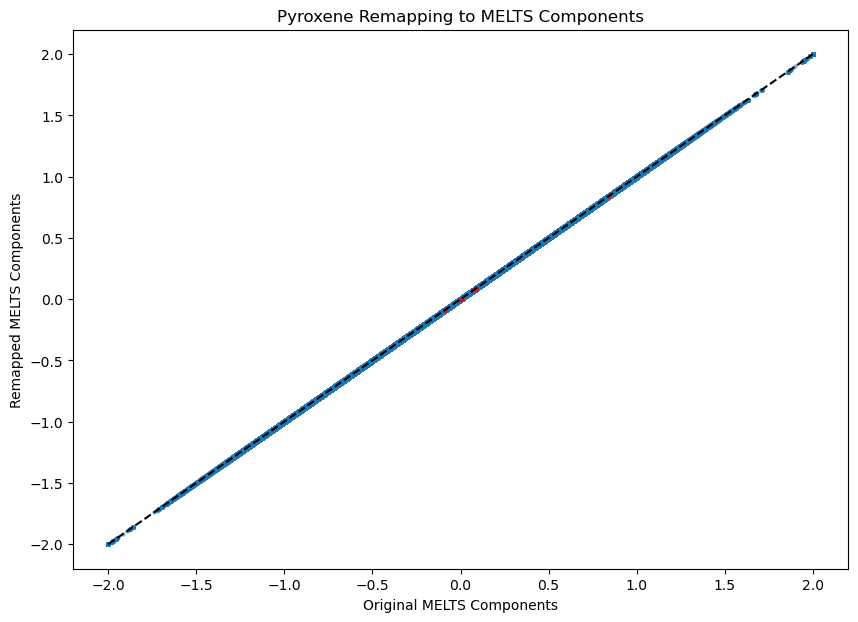

In [221]:


Anp = Apx.detach().cpu().numpy()

#Anp = Anp/1.0001

Anp = np.array([[ 1.    , -0.    , -0.    ,  0.    , -0.    , -0.    , -0.    ],
       [ 0.6558,  0.3442, -0.    , -0.    ,  0.    ,  0.    , -0.    ],
       [ 0.688 , -0.0231,  0.335 ,  0.    ,  0.    ,  0.    , -0.    ],
       [ 0.4588,  0.1268,  0.0066,  0.4078, -0.    ,  0.    ,  0.    ],
       [ 0.3883, -0.1142, 0,  0.4025,  0.3248, -0.    , -0.    ],
       [ 0.4588,  0.0714,  0.0626,  0.0807,  0.3249,  0.0016,  0.    ],
       [ 0.0146,  0.308 , 0,  0.0034,  0.0027,  0.4186,  0.2533]]).astype(np.float32)

Anp = Anp / np.sum(Anp, axis = 1).reshape(-1,1)

pickle.dump(Anp, open('PyroxeneMatrixBJT.pkl', 'wb'))

#Apx = solve_masked_A(torch.tensor(px_components, requires_grad=True, device = 'cuda'), steps = 15000).detach().cpu()
print(Anp)
print((torch.tensor(px_components) @ torch.tensor(Anp)).sum(dim=1))
plt.hist((torch.tensor(px_components) @ torch.tensor(Anp)).detach().numpy().flatten(), bins = [-0.2,0,0.2,0.4,0.6,0.8,1.0])
plt.title('BJT Remapped Px Components')
plt.savefig('BJTPxRemapedComps.png')

plt.show()

plt.hist((torch.tensor(px_components) @ torch.tensor(Anp)).sum(dim=1))
plt.title('Sum of BJT Remapped Px Components (Offset by 1 in parts per 100,000)')
#plt.savefig('BJTPxRemapSums.png')
plt.show()
print(((torch.tensor(px_components) @ torch.tensor(Anp)) > 1).sum() + ((torch.tensor(px_components) @ torch.tensor(Anp)) < 0).sum())
#wrong_comps = (((px_components) @ Anp) > 1) 
#print(px_components[wrong_comps.astype(bool)])
wrong_comps = (((px_components) @ Anp) < -0.001)
#wrong_comps = (((px_components) @ Anp) < 0)

print(px_components[wrong_comps.astype(bool)])
print(np.where(wrong_comps))
print(wrong_comps.shape)


print(px_components.size)

Ainv = np.linalg.inv(Anp)

transformed = px_components @ Anp

print(transformed[np.where(wrong_comps)[0]])
print(transformed[np.where(wrong_comps)[0]] < 0)

print(transformed)

#transformed = transformed / np.sum(transformed, axis = 1).reshape(-1,1)

print(transformed)

#transformed = np.clip(transformed,0,1)

print(transformed)

retransformed = transformed @ Ainv

retransformed = retransformed / np.sum(retransformed, axis = 1).reshape(-1,1)

plt.plot([-2,2],[-2,2], linestyle = '--', color = 'black')
plt.scatter(px_components, retransformed, s= 5, alpha = 0.4)
plt.scatter(px_components[np.where(wrong_comps)[0]], retransformed[np.where(wrong_comps)[0]], s = 7, alpha = 0.7, marker = 'x', color = 'red')
plt.title('Pyroxene Remapping to MELTS Components')
plt.xlabel('Original MELTS Components')
plt.ylabel('Remapped MELTS Components')
plt.savefig('BJTrecastedPX.png')

	chromite:0.0	hercynite:-1.09	magnetite:0.28	spinel:1.15	ulvospinel:0.67
	chromite:0.0	hercynite:-1.09	magnetite:0.28	spinel:1.14	ulvospinel:0.67
	chromite:0.0	hercynite:-1.09	magnetite:0.28	spinel:1.14	ulvospinel:0.67
	chromite:0.0	hercynite:-1.08	magnetite:0.28	spinel:1.14	ulvospinel:0.66
	chromite:0.0	hercynite:-1.08	magnetite:0.29	spinel:1.13	ulvospinel:0.66
	chromite:0.0	hercynite:-1.08	magnetite:0.29	spinel:1.13	ulvospinel:0.66
	chromite:0.0	hercynite:-1.07	magnetite:0.29	spinel:1.13	ulvospinel:0.66
	chromite:0.0	hercynite:-1.07	magnetite:0.29	spinel:1.12	ulvospinel:0.65
	chromite:0.0	hercynite:-1.07	magnetite:0.3	spinel:1.12	ulvospinel:0.65
	chromite:0.0	hercynite:-1.06	magnetite:0.3	spinel:1.12	ulvospinel:0.65
	chromite:0.0	hercynite:-1.06	magnetite:0.3	spinel:1.11	ulvospinel:0.65
	chromite:0.0	hercynite:-1.06	magnetite:0.3	spinel:1.11	ulvospinel:0.64
	chromite:0.0	hercynite:-1.05	magnetite:0.31	spinel:1.11	ulvospinel:0.64
	chromite:0.0	hercynite:-1.05	magnetite:0.31	spinel:1.1

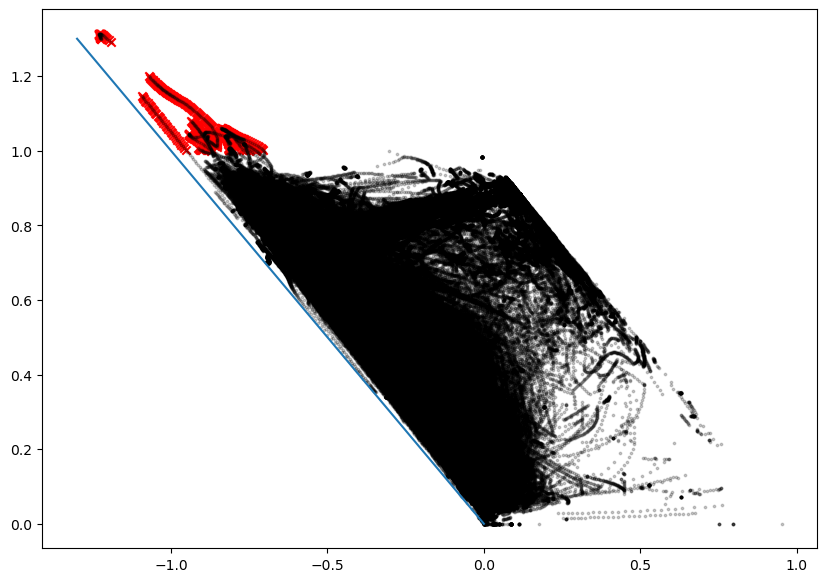

In [67]:
sp_present = np.where(Big_Table.table[:,component_indices['spinel']['mass (gm)']] != 0)[0]
sp_components = Big_Table.table[np.ix_(sp_present,np.arange(26,31))]
impMgO = (sp_components @ compToOx[label_indices['spinel']])[:,oxide_dict['MgO']] > 1

for ind in np.where(impMgO)[0]:
    compstr = ''
    for i, comp in enumerate(['chromite','hercynite','magnetite', 'spinel', 'ulvospinel']):
        compstr += f"\t{comp}:{str(round(sp_components[ind,i],2))}"
    print(compstr)

plt.scatter(sp_components[impMgO,1], sp_components[impMgO,3], marker = 'x', color = 'red')
plt.scatter(sp_components[:,1], sp_components[:,3], s = 3, color = 'black', alpha = 0.2)
plt.plot([-1.3,0], [1.3,0])

In [72]:
# Requires: numpy, cvxpy
# pip install cvxpy

import itertools
import numpy as np
import cvxpy as cp

# ---------- 1) define the linear map g -> x (from your message) ----------
# g = [g0,g1,g2,g3,g4,g5]
def x_from_g(g):
    g0,g1,g2,g3,g4,g5 = g
    x0 = 1 - 2*g0 - g1 - g2 - g3 - 0.5*g4 - g5
    x1 = g5
    x2 = 2*g0
    x3 = g1 + g2 - g3 - 0.5*g4
    x4 = g1 - g2 + g3 + 0.5*g4
    x5 = -g1 + g2 + g3 - 0.5*g4
    x6 = g4
    return np.array([x0,x1,x2,x3,x4,x5,x6], dtype=float)

# Quick sanity check: sum should be 1
# for random g in [0,1]
rg = np.random.rand(6)
assert abs(x_from_g(rg).sum() - 1) < 1e-9

# ---------- 2) generate all 64 vertices x(g) for g in {0,1}^6 ----------
vertices_g = list(itertools.product([0.0, 1.0], repeat=6))
X_vertices = np.vstack([x_from_g(np.array(g)) for g in vertices_g])  # shape (64,7)

# Optional: you can remove duplicate x vectors if some corner map to same x
# (numerical duplicates can happen); keep unique rows:
X_vertices = np.unique(np.round(X_vertices, 12), axis=0)

print("Number of unique vertex x vectors:", X_vertices.shape[0])

# ---------- 3) set up convex optimization for M ----------
# Unknown M is 7x7
n = 7
M = cp.Variable((n,n))

# Constraints:
constraints = []

# (A) column-stochastic: each column sums to 1 (ensures sum_i g_i = 1 for any x with sum 1)
constraints += [cp.sum(M, axis=0) == np.ones(n)]

# (B) positivity: for each vertex x_v, M @ x_v >= 0 (elementwise)
# Collect into matrix form: M @ X.T >= 0
Xtv = X_vertices.T  # shape (7, nv)
constraints += [M @ Xtv >= 0]

# (C) (optional) you may want to keep M reasonably close to identity or to a target T
# I'll use identity as a neutral default target
T = np.eye(n)

# Objective: minimize Frobenius norm squared ||M - T||_F^2 (quadratic convex)
obj = cp.Minimize(cp.sum_squares(M - T))

prob = cp.Problem(obj, constraints)
prob.solve(solver=cp.OSQP, verbose=True)  # or use SCS or OSQP

print("status:", prob.status)
M_opt = M.value
print("M_opt shape:", M_opt.shape)

# ---------- 4) Quick checks ----------
# Check columns sum ~1
print("column sums:", M_opt.sum(axis=0))

# check nonnegativity on all vertex images
G_vertices = (M_opt @ Xtv)
min_entry = G_vertices.min()
print("min entry over vertices (should be >= 0):", min_entry)

# Optionally check what this mapping does to some sample x (including problematic ones)
def apply_M_to_x(x):
    return M_opt @ x

# Example: check some random g, its x, and g_recovered = M @ x
for gg in [np.zeros(6), np.ones(6)*0.5, np.random.rand(6)]:
    xv = x_from_g(gg)
    gv = apply_M_to_x(xv)
    print("g_in:", gg[:6], " -> g_out (sum, min):", gv.sum(), gv.min())


(CVXPY) Aug 10 12:00:55 PM: Your problem has 49 variables, 455 constraints, and 0 parameters.
(CVXPY) Aug 10 12:00:55 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Aug 10 12:00:55 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Aug 10 12:00:55 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Aug 10 12:00:55 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Aug 10 12:00:55 PM: Compiling problem (target solver=OSQP).
(CVXPY) Aug 10 12:00:55 PM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> OSQP
(CVXPY) Aug 10 12:00:55 PM: Applying reduction CvxAttr2Constr
(CVXPY) Aug 10 12:00:55 PM: Applying reduction Qp2SymbolicQp
(CVXPY) Aug 10 12:00:55 PM: Applying reduction QpMatrixStuffing
(CVXPY) Aug 10 12:00:55 PM: Applying reduction OSQP
(CVXPY) Aug 10 12:00:55 PM: Finished problem compilation (

Number of unique vertex x vectors: 64
                                     CVXPY                                     
                                     v1.7.1                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
status: optimal
M_opt shape: (7, 7)
column sums: [1. 1. 1. 1. 1. 1. 1.]
min entry 

In [68]:
torch.nn.functional.softmax(torch.tensor([1,2,3,4,0,-1,-2,-3], dtype = torch.float32))

C:\Users\dashf\AppData\Local\Temp\ipykernel_25368\3193353606.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  torch.nn.functional.softmax(torch.tensor([1,2,3,4,0,-1,-2,-3], dtype = torch.float32))


tensor([3.1482e-02, 8.5577e-02, 2.3262e-01, 6.3233e-01, 1.1582e-02, 4.2606e-03,
        1.5674e-03, 5.7661e-04])

In [10]:
# correcting length of labels, lots of extra zeros at end. Hopefully now corrected in resample_dataset

num_components = label_indices_comp['melts-liquid'][-1]+1

del oldlabels
gc.collect()

for datclass in ['Train', 'Test', 'Valid']:
    name = f'MELTS_{datclass}setJuly28Intensivelabels.npy'
    tempname = f'MELTS_{datclass}setJuly28Intensivelabels_cut.npy'
    
    oldlabels = np.load(name, mmap_mode='r')
    
    newlabels = np.lib.format.open_memmap( # Components in moles
                tempname,
                mode='w+',
                dtype=np.float32,
                shape=(oldlabels.shape[0], num_components)
            )
    
    newlabels[:] = oldlabels[:,:num_components]
    newlabels.flush()
    del newlabels, oldlabels
    gc.collect()
    
    os.replace(tempname, name)


NameError: name 'oldlabels' is not defined

In [ ]:
Oxide_Lower_Bounds = [['k-feldspar', 'K2O', 8],
                      ['clinopyroxene', 'CaO', 7]]

easy_build_oxide_upper_bounds = {'k-feldspar': [['CaO', 1]],
                                 'plagioclase': [['K2O', 8]],
                                 'clinopyroxene': [ ['TiO2', 6], ['Al2O3', 8] ],
                                 'orthopyroxene': [ ['TiO2', 2], ['Al2O3', 8], ['CaO', 4] ],
                                }
                                      
Oxide_Upper_Bounds = []

for phase, boundlist in easy_build_oxide_upper_bounds.items():
    for ox, bound in boundlist:
        Oxide_Upper_Bounds.append([phase, ox, bound])
print(Oxide_Upper_Bounds)    

Component_Upper_Bounds = [ ['plagioclase', 'highsanidine', 0.1] ]

#time.sleep(3600) #1 Hour Sleep, alot 30 minutes for processing

TrainName = 'MELTS_TrainsetSept25BatchCooling_subset'
#del TrainMELTS
gc.collect()
TrainMELTS = BigMetaTable(TrainName)
TrainMELTS.separate_analcime_old()
#TrainMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
#TrainMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
TrainMELTS.filter_full_metadata()
TrainMELTS.filter_legal()


assert TrainMELTS.blurredbinaries is not None

print(np.shape(TrainMELTS.table))
print(np.shape(TrainMELTS.blurredbinaries))
TrainMELTS.filename = f"{TrainName}Filtered"
TrainMELTS.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.8,1.1), n_resamples=10, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=2, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)


balance_lowF(TrainMELTS)

TrainMELTS.filename = f'{TrainName}Intensive'


#del TrainMELTS.masslabels, TrainMELTS.table1

resampling_to_datasets(TrainMELTS,[[1,1],[.8,1],[0.5,1]])
deep_filter(f'{TrainName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
#train_plot_directory = 'Training_Dataset_July28Intensive'


#make_harkers(TrainMELTS, train_plot_directory+'/')
#make_Tplots(TrainMELTS, train_plot_directory+'/') 
#F_phase_plots(partition_directory=train_plot_directory, filename=TrainMELTS.filename)

del TrainMELTS.table
del TrainMELTS
gc.collect()


#del TestMELTS.table, ValidMELTS.table
#del TestMELTS, ValidMELTS
gc.collect()

ValidName = "MELTS_ValidsetSept25BatchCooling_subset"
TestName = "MELTS_TestsetSept25BatchCooling_subset"

ValidMELTS = BigMetaTable(ValidName)
ValidMELTS.separate_analcime_old()
#ValidMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
ValidMELTS.filter_full_metadata()
ValidMELTS.filter_legal()
ValidMELTS, TestMELTS = ValidMELTS.split(0.15)

print(np.shape(TestMELTS.blurredbinaries))
print(np.sum((TestMELTS.blurredbinaries != 0).astype(int) * (TestMELTS.blurredbinaries != 1).astype(int)))
print(TestMELTS.blurredbinaries)
zeros = np.sum((TestMELTS.blurredbinaries== 0).astype(int))
ones = np.sum((TestMELTS.blurredbinaries == 1).astype(int))
threes = np.sum((TestMELTS.blurredbinaries == 0.3).astype(int))
sevens = np.sum((TestMELTS.blurredbinaries == 0.7).astype(int))
print(zeros)
print(ones)
print(threes)
print(sevens)
print(np.product(TestMELTS.blurredbinaries.shape))
print(np.sum([ones,zeros,threes,sevens]))



print(np.shape(TestMELTS.table))
print(np.shape(TestMELTS.blurredbinaries))
print(np.shape(ValidMELTS.table))
print(np.shape(ValidMELTS.blurredbinaries))

TestMELTS.filename = f"{TestName}Filtered"
TestMELTS.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.99,1.01), n_resamples=10, overwrite=True)
TestMELTS.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=2, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)

print("################ After resampling ####################")

print(np.shape(TestMELTS.blurredbinaries))
print(np.sum((TestMELTS.blurredbinaries != 0).astype(int) * (TestMELTS.blurredbinaries != 1).astype(int)))
print(TestMELTS.blurredbinaries)
zeros = np.sum((TestMELTS.blurredbinaries== 0).astype(int))
ones = np.sum((TestMELTS.blurredbinaries == 1).astype(int))
threes = np.sum((TestMELTS.blurredbinaries == 0.3).astype(int))
sevens = np.sum((TestMELTS.blurredbinaries == 0.7).astype(int))
print(zeros)
print(ones)
print(threes)
print(sevens)
print(np.product(TestMELTS.blurredbinaries.shape))
print(np.sum([ones,zeros,threes,sevens]))

balance_lowF(TestMELTS)
balance_lowF(ValidMELTS)

TestMELTS.filename = f'{TestName}Intensive'
ValidMELTS.filename = f'{ValidName}Intensive'

resampling_to_datasets(TestMELTS)
resampling_to_datasets(ValidMELTS)

deep_filter(f'{TestName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
deep_filter(f'{ValidName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)

valid_plot_directory = f"{ValidName}Plots"

make_harkers(ValidMELTS, valid_plot_directory+'/')
make_Tplots(ValidMELTS, valid_plot_directory+'/') 
#F_phase_plots(partition_directory=valid_plot_directory, filename=ValidMELTS.filename)

del TestMELTS.table, ValidMELTS.table
del TestMELTS, ValidMELTS
gc.collect()

In [ ]:
Oxide_Lower_Bounds = [['k-feldspar', 'K2O', 8],
                      ['clinopyroxene', 'CaO', 7]]

easy_build_oxide_upper_bounds = {'k-feldspar': [['CaO', 1]],
                                 'plagioclase': [['K2O', 8]],
                                 'clinopyroxene': [ ['TiO2', 6], ['Al2O3', 8] ],
                                 'orthopyroxene': [ ['TiO2', 2], ['Al2O3', 8], ['CaO', 4] ],
                                }
                                      
Oxide_Upper_Bounds = []

for phase, boundlist in easy_build_oxide_upper_bounds.items():
    for ox, bound in boundlist:
        Oxide_Upper_Bounds.append([phase, ox, bound])
print(Oxide_Upper_Bounds)    

Component_Upper_Bounds = [ ['plagioclase', 'highsanidine', 0.1] ]


#del TrainMELTS
gc.collect()
train_name = "MELTS_TrainsetSept25FxtalCooling_subset"
TrainMELTS = BigMetaTable(train_name)
TrainMELTS.separate_analcime_old()
#TrainMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
TrainMELTS.filter_full_metadata()
TrainMELTS.filter_legal()


assert TrainMELTS.blurredbinaries is not None

print(np.shape(TrainMELTS.table))
print(np.shape(TrainMELTS.blurredbinaries))
TrainMELTS.filename = train_name+"Filtered"
TrainMELTS.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.8,1.1), n_resamples=10, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=2, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=2, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)


balance_Superliquidus_fxtal(TrainMELTS)

TrainMELTS.filename = train_name+'Intensive'


#del TrainMELTS.masslabels, TrainMELTS.table1

resampling_to_datasets(TrainMELTS,[[1,1],[.8,1],[0.5,1]])
deep_filter(train_name+'Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
#train_plot_directory = 'Training_Dataset_July28Intensive'


#make_harkers(TrainMELTS, train_plot_directory+'/')
#make_Tplots(TrainMELTS, train_plot_directory+'/') 
#F_phase_plots(partition_directory=train_plot_directory, filename=TrainMELTS.filename)

del TrainMELTS.table
del TrainMELTS
gc.collect()


#del TestMELTS.table, ValidMELTS.table
#del TestMELTS, ValidMELTS
valid_name = "MELTS_ValidsetSept25FxtalCooling"
test_name = "MELTS_TestsetSept25FxtalCooling"
gc.collect()
ValidMELTS = BigMetaTable(valid_name)
ValidMELTS.separate_analcime_old(valid_name)
#ValidMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
ValidMELTS.filter_legal()
ValidMELTS.filter_full_metadata()

ValidMELTS, TestMELTS = ValidMELTS.split(0.15)

print(np.shape(TestMELTS.blurredbinaries))
print(np.sum((TestMELTS.blurredbinaries != 0).astype(int) * (TestMELTS.blurredbinaries != 1).astype(int)))
print(TestMELTS.blurredbinaries)
zeros = np.sum((TestMELTS.blurredbinaries== 0).astype(int))
ones = np.sum((TestMELTS.blurredbinaries == 1).astype(int))
threes = np.sum((TestMELTS.blurredbinaries == 0.3).astype(int))
sevens = np.sum((TestMELTS.blurredbinaries == 0.7).astype(int))
print(zeros)
print(ones)
print(threes)
print(sevens)
print(np.product(TestMELTS.blurredbinaries.shape))
print(np.sum([ones,zeros,threes,sevens]))



print(np.shape(TestMELTS.table))
print(np.shape(TestMELTS.blurredbinaries))
print(np.shape(ValidMELTS.table))
print(np.shape(ValidMELTS.blurredbinaries))

TestMELTS.filename = test_name + 'Filtered'
TestMELTS.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.99,1.01), n_resamples=10, overwrite=True)
TestMELTS.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=2, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)

print("################ After resampling ####################")

print(np.shape(TestMELTS.blurredbinaries))
print(np.sum((TestMELTS.blurredbinaries != 0).astype(int) * (TestMELTS.blurredbinaries != 1).astype(int)))
print(TestMELTS.blurredbinaries)
zeros = np.sum((TestMELTS.blurredbinaries== 0).astype(int))
ones = np.sum((TestMELTS.blurredbinaries == 1).astype(int))
threes = np.sum((TestMELTS.blurredbinaries == 0.3).astype(int))
sevens = np.sum((TestMELTS.blurredbinaries == 0.7).astype(int))
print(zeros)
print(ones)
print(threes)
print(sevens)
print(np.product(TestMELTS.blurredbinaries.shape))
print(np.sum([ones,zeros,threes,sevens]))

balance_Superliquidus_fxtal(TestMELTS)
balance_Superliquidus_fxtal(ValidMELTS)

TestMELTS.filename = test_name+'Intensive'
ValidMELTS.filename = talid_name+'Intensive'

resampling_to_datasets(TestMELTS)
resampling_to_datasets(ValidMELTS)

deep_filter(test_name+'Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
deep_filter(valid_name+'Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)

valid_plot_directory = 'Validation_fxtal_Dataset_Sept19Intensive'

make_harkers(ValidMELTS, valid_plot_directory+'/')
make_Tplots(ValidMELTS, valid_plot_directory+'/') 
#F_phase_plots(partition_directory=valid_plot_directory, filename=ValidMELTS.filename)

del TestMELTS.table, ValidMELTS.table
del TestMELTS, ValidMELTS
gc.collect()

[['k-feldspar', 'CaO', 1], ['plagioclase', 'K2O', 8], ['clinopyroxene', 'TiO2', 6], ['clinopyroxene', 'Al2O3', 8], ['orthopyroxene', 'TiO2', 2], ['orthopyroxene', 'Al2O3', 8], ['orthopyroxene', 'CaO', 4]]
Preparing to read 4000000 rows of text


Reading Text...: 100%|███████████████████████████████████████████████████| 4000000/4000000 [00:06<00:00, 630178.86it/s]


[TIMER] Parsed 4000000 Metadata to Lists: completed in 19.86 seconds
[TIMER] Metadata Lists to arrays: completed in 2.40 seconds
[INFO] Preparing to process 4000000 of 4000000 total rows with 138 columns...


Reading MELTS_TrainsetSept25FxtalCooling_subset.csv: 3742090it [02:40, 30110.17it/s]                                   

In [4]:
Oxide_Lower_Bounds = [['k-feldspar', 'K2O', 8],
                      ['clinopyroxene', 'CaO', 7]]

easy_build_oxide_upper_bounds = {'k-feldspar': [['CaO', 1]],
                                 'plagioclase': [['K2O', 8]],
                                 'clinopyroxene': [ ['TiO2', 6], ['Al2O3', 8] ],
                                 'orthopyroxene': [ ['TiO2', 2], ['Al2O3', 8], ['CaO', 4] ],
                                }
                                      
Oxide_Upper_Bounds = []

for phase, boundlist in easy_build_oxide_upper_bounds.items():
    for ox, bound in boundlist:
        Oxide_Upper_Bounds.append([phase, ox, bound])
print(Oxide_Upper_Bounds)    

Component_Upper_Bounds = [ ['plagioclase', 'highsanidine', 0.1] ]



deep_filter('MELTS_TrainsetSept19Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
deep_filter('MELTS_TestsetSept19Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
deep_filter('MELTS_ValidsetSept19Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)

[['k-feldspar', 'CaO', 1], ['plagioclase', 'K2O', 8], ['clinopyroxene', 'TiO2', 6], ['clinopyroxene', 'Al2O3', 8], ['orthopyroxene', 'TiO2', 2], ['orthopyroxene', 'Al2O3', 8], ['orthopyroxene', 'CaO', 4]]
Deleting 369117 for 0.1 Upper Bound plagioclase highsanidine
olivine present in 16.359670443480436% of assemblages
orthopyroxene present in 41.55162947223695% of assemblages
clinopyroxene present in 63.70645002653712% of assemblages
spinel present in 43.15404833835348% of assemblages
plagioclase present in 64.06124969753348% of assemblages
k-feldspar present in 12.19341802895252% of assemblages
garnet present in 20.445770273333135% of assemblages
nepheline present in 3.3779659828633672% of assemblages
leucite present in 3.9636643836585983% of assemblages
biotite present in 17.670938751135136% of assemblages
rhm-oxide present in 20.517363034920248% of assemblages
alloy-solid present in 0.2504997254694871% of assemblages
analcime present in 2.213563589243733% of assemblages
apatite pres

C:\Users\dashf\AppData\Local\Temp\ipykernel_9020\639348412.py:1076: RuntimeWarning: divide by zero encountered in divide
  oxides_GT = oxides_GT * (100/np.sum(oxides_GT,axis=1)).reshape(-1,1)
C:\Users\dashf\AppData\Local\Temp\ipykernel_9020\639348412.py:1076: RuntimeWarning: invalid value encountered in multiply
  oxides_GT = oxides_GT * (100/np.sum(oxides_GT,axis=1)).reshape(-1,1)
C:\Users\dashf\AppData\Local\Temp\ipykernel_9020\639348412.py:1091: RuntimeWarning: divide by zero encountered in divide
  oxides_GT = oxides_GT * (100/np.sum(oxides_GT,axis=1)).reshape(-1,1)
C:\Users\dashf\AppData\Local\Temp\ipykernel_9020\639348412.py:1091: RuntimeWarning: invalid value encountered in multiply
  oxides_GT = oxides_GT * (100/np.sum(oxides_GT,axis=1)).reshape(-1,1)


Deleting 229 for 1 Lower Bound k-feldspar CaO
Deleting 263 for 8 Lower Bound plagioclase K2O
Deleting 7746 for 6 Lower Bound clinopyroxene TiO2
Deleting 25272 for 8 Lower Bound clinopyroxene Al2O3
Deleting 1709 for 2 Lower Bound orthopyroxene TiO2
Deleting 1981 for 8 Lower Bound orthopyroxene Al2O3
Deleting 172 for 4 Lower Bound orthopyroxene CaO
Deleting 825 for 8 Lower Bound k-feldspar K2O
Deleting 2587 for 7 Lower Bound clinopyroxene CaO
Deleting 817 for 1 Lower Bound k-feldspar CaO
Deleting 520 for 8 Lower Bound plagioclase K2O
Deleting 8398 for 6 Lower Bound clinopyroxene TiO2
Deleting 25142 for 8 Lower Bound clinopyroxene Al2O3
Deleting 993 for 2 Lower Bound orthopyroxene TiO2
Deleting 1104 for 8 Lower Bound orthopyroxene Al2O3
Deleting 397 for 4 Lower Bound orthopyroxene CaO
Deleting 437 for 8 Lower Bound k-feldspar K2O
Deleting 2360 for 7 Lower Bound clinopyroxene CaO
Deleting 393 for 1 Lower Bound k-feldspar CaO
Deleting 295 for 8 Lower Bound plagioclase K2O
Deleting 8696 for 

Deleting 17069 for 8 Lower Bound k-feldspar K2O
Deleting 536 for 7 Lower Bound clinopyroxene CaO
Deleting 16584 for 1 Lower Bound k-feldspar CaO
Deleting 288 for 8 Lower Bound plagioclase K2O
Deleting 59566 for 6 Lower Bound clinopyroxene TiO2
Deleting 91815 for 8 Lower Bound clinopyroxene Al2O3
Deleting 3384 for 2 Lower Bound orthopyroxene TiO2
Deleting 3438 for 8 Lower Bound orthopyroxene Al2O3
Deleting 6431 for 4 Lower Bound orthopyroxene CaO
Deleting 1321 for 8 Lower Bound k-feldspar K2O
Deleting 3223 for 7 Lower Bound clinopyroxene CaO
Deleting 1247 for 1 Lower Bound k-feldspar CaO
Deleting 263 for 8 Lower Bound plagioclase K2O
Deleting 9415 for 6 Lower Bound clinopyroxene TiO2
Deleting 27299 for 8 Lower Bound clinopyroxene Al2O3
Deleting 1721 for 2 Lower Bound orthopyroxene TiO2
Deleting 1993 for 8 Lower Bound orthopyroxene Al2O3
Deleting 840 for 4 Lower Bound orthopyroxene CaO
Deleting 825 for 8 Lower Bound k-feldspar K2O
Deleting 2581 for 7 Lower Bound clinopyroxene CaO
Deletin

Deleting 362 for 8 Lower Bound plagioclase K2O
Deleting 9794 for 6 Lower Bound clinopyroxene TiO2
Deleting 29287 for 8 Lower Bound clinopyroxene Al2O3
Deleting 1911 for 2 Lower Bound orthopyroxene TiO2
Deleting 2288 for 8 Lower Bound orthopyroxene Al2O3
Deleting 244 for 4 Lower Bound orthopyroxene CaO
Deleting 173 for 8 Lower Bound k-feldspar K2O
Deleting 1801 for 7 Lower Bound clinopyroxene CaO
Deleting 203 for 1 Lower Bound k-feldspar CaO
Deleting 331 for 8 Lower Bound plagioclase K2O
Deleting 4520 for 6 Lower Bound clinopyroxene TiO2
Deleting 34037 for 8 Lower Bound clinopyroxene Al2O3
Deleting 2115 for 2 Lower Bound orthopyroxene TiO2
Deleting 2816 for 8 Lower Bound orthopyroxene Al2O3
Deleting 122 for 4 Lower Bound orthopyroxene CaO
Rows after deleting: 314569
Deleting!
Saving!
Deleting!
Saving!
Deleting!
Saving!
Deleting!
Saving!
Deleting!
Saving!


array([     2,      3,      4, ..., 399477, 399478, 399479], dtype=int64)

In [14]:
"""BATCHWISE PROCESSING OF BATCH MELT/CRYST TRAINING CALCULATION"""

batch_size = 3E6

Oxide_Lower_Bounds = [['k-feldspar', 'K2O', 8],
                      ['clinopyroxene', 'CaO', 7]]

easy_build_oxide_upper_bounds = {'k-feldspar': [['CaO', 1]],
                                 'plagioclase': [['K2O', 8]],
                                 'clinopyroxene': [ ['TiO2', 6], ['Al2O3', 8] ],
                                 'orthopyroxene': [ ['TiO2', 2], ['Al2O3', 8], ['CaO', 4] ],
                                }
                                      
Oxide_Upper_Bounds = []

for phase, boundlist in easy_build_oxide_upper_bounds.items():
    for ox, bound in boundlist:
        Oxide_Upper_Bounds.append([phase, ox, bound])
print(Oxide_Upper_Bounds)    

Component_Upper_Bounds = [ ['plagioclase', 'highsanidine', 0.1] ]

#time.sleep(3600) #1 Hour Sleep, alot 30 minutes for processing

TrainName = 'MELTS_TrainsetSept25BatchCooling'
#del TrainMELTS
gc.collect()
 
def TrainFilter(BMT):
    BMT.separate_analcime_old()
    BMT.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))

    assert BMT.blurredbinaries is not None

    print(np.shape(BMT.table))
    print(np.shape(BMT.blurredbinaries))
    BMT.filename = f"{TrainName}Filtered"
    BMT.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.8,1.1), n_resamples=10, overwrite=True)
    BMT.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=2, overwrite=True)
    BMT.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
    BMT.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)
    BMT.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
    BMT.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)
    BMT.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)


    balance_lowF(BMT)

    BMT.filename = f'{TrainName}Intensive'


#del TrainMELTS.masslabels, TrainMELTS.table1

TrainMELTS = None # Placeholder for first merge pass
L = 0
U = batch_size
count = 1
TempTrain = BigMetaTable(TrainName, lower_idx=L, upper_idx=U)
while TempTrain is not None:
    count += 1
    TrainFilter(TempTrain)
    TrainMELTS = merge_big_meta_tables((TrainMELTS, TempTrain), new_filename=TrainName+str(count))
    L += batch_size
    U += batch_size
    TempTrain = BigMetaTable(TrainName, lower_idx=L, upper_idx=U)
    

resampling_to_datasets(TrainMELTS,[[1,1],[.8,1],[0.5,1]])
deep_filter(f'{TrainName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
#train_plot_directory = 'Training_Dataset_July28Intensive'


#make_harkers(TrainMELTS, train_plot_directory+'/')
#make_Tplots(TrainMELTS, train_plot_directory+'/') 
#F_phase_plots(partition_directory=train_plot_directory, filename=TrainMELTS.filename)

del TrainMELTS.table
del TrainMELTS
gc.collect()


#del TestMELTS.table, ValidMELTS.table
#del TestMELTS, ValidMELTS
gc.collect()

ValidName = "MELTS_ValidsetSept25BatchCooling"
TestName = "MELTS_TestsetSept25BatchCooling"

ValidMELTS = BigMetaTable(ValidName)
ValidMELTS.separate_analcime_old()
ValidMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
ValidMELTS, TestMELTS = ValidMELTS.split(0.15)

print(np.shape(TestMELTS.blurredbinaries))
print(np.sum((TestMELTS.blurredbinaries != 0).astype(int) * (TestMELTS.blurredbinaries != 1).astype(int)))
print(TestMELTS.blurredbinaries)
zeros = np.sum((TestMELTS.blurredbinaries== 0).astype(int))
ones = np.sum((TestMELTS.blurredbinaries == 1).astype(int))
threes = np.sum((TestMELTS.blurredbinaries == 0.3).astype(int))
sevens = np.sum((TestMELTS.blurredbinaries == 0.7).astype(int))
print(zeros)
print(ones)
print(threes)
print(sevens)
print(np.product(TestMELTS.blurredbinaries.shape))
print(np.sum([ones,zeros,threes,sevens]))



print(np.shape(TestMELTS.table))
print(np.shape(TestMELTS.blurredbinaries))
print(np.shape(ValidMELTS.table))
print(np.shape(ValidMELTS.blurredbinaries))

TestMELTS.filename = f"{TestName}Filtered"
TestMELTS.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.99,1.01), n_resamples=10, overwrite=True)
TestMELTS.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=2, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)

print("################ After resampling ####################")

print(np.shape(TestMELTS.blurredbinaries))
print(np.sum((TestMELTS.blurredbinaries != 0).astype(int) * (TestMELTS.blurredbinaries != 1).astype(int)))
print(TestMELTS.blurredbinaries)
zeros = np.sum((TestMELTS.blurredbinaries== 0).astype(int))
ones = np.sum((TestMELTS.blurredbinaries == 1).astype(int))
threes = np.sum((TestMELTS.blurredbinaries == 0.3).astype(int))
sevens = np.sum((TestMELTS.blurredbinaries == 0.7).astype(int))
print(zeros)
print(ones)
print(threes)
print(sevens)
print(np.product(TestMELTS.blurredbinaries.shape))
print(np.sum([ones,zeros,threes,sevens]))

balance_lowF(TestMELTS)
balance_lowF(ValidMELTS)

TestMELTS.filename = f'{TestName}Intensive'
ValidMELTS.filename = f'{ValidName}Intensive'

resampling_to_datasets(TestMELTS)
resampling_to_datasets(ValidMELTS)

deep_filter(f'{TestName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
deep_filter(f'{ValidName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)

valid_plot_directory = f"{ValidName}Plots"

make_harkers(ValidMELTS, valid_plot_directory+'/')
make_Tplots(ValidMELTS, valid_plot_directory+'/') 
#F_phase_plots(partition_directory=valid_plot_directory, filename=ValidMELTS.filename)

del TestMELTS.table, ValidMELTS.table
del TestMELTS, ValidMELTS
gc.collect()

Index: 0: DB header: Pressure(System_main),		 component_index: System_main-Pressure
Index: 1: DB header: Temperature(System_main),		 component_index: System_main-Temperature
Index: 2: DB header: logfO2-QFM(System_main),		 component_index: System_main-logfO2-QFM
Index: 3: DB header: mass (gm)(olivine),		 component_index: olivine-mass (gm)
Index: 4: DB header: tephroite(olivine),		 component_index: olivine-tephroite
Index: 5: DB header: fayalite(olivine),		 component_index: olivine-fayalite
Index: 6: DB header: ni-olivine(olivine),		 component_index: olivine-ni-olivine
Index: 7: DB header: monticellite(olivine),		 component_index: olivine-monticellite
Index: 8: DB header: forsterite(olivine),		 component_index: olivine-forsterite
Index: 9: DB header: mass (gm)(orthopyroxene),		 component_index: orthopyroxene-mass (gm)
Index: 10: DB header: diopside(orthopyroxene),		 component_index: orthopyroxene-diopside
Index: 11: DB header: clinoenstatite(orthopyroxene),		 component_index: orthopyroxe

In [9]:
MarsRocks = pd.read_csv('chassignites_nakhlites.csv')
names = MarsRocks['names']
for i, name in enumerate(names):
    MarsSims = BigMetaTable(f"Applications/{name}_BatchMELTS")
    MarsSims.separate_analcime_old()
    resampling_to_datasets(MarsSims)
    del MarsSims.table
    del MarsSims
    gc.collect()

[TIMER] Parsed Metadata to Lists: completed in 0.05 seconds
[TIMER] Metadata Lists to arrays: completed in 0.63 seconds
[INFO] Preparing to process ~5197 rows with 138 columns...


[INFO] Loaded 5197 valid rows into memmap (skipped 0)
[TIMER] Completed in 0.30 seconds
Total Length:5197, Leucites: 1565, of which 0 are analcime
INITIALIZE


Generating Molar Features and Labels:   0%|                                                      | 0/1 [00:00<?, ?it/s]

SAMPLE: 0
5 to 0
7 to 1
8 to 2
10 to 3
11 to 4
12 to 5
13 to 6
14 to 7
15 to 8
16 to 9
18 to 10
19 to 11
20 to 12
21 to 13
22 to 14
23 to 15
24 to 16
26 to 17
27 to 18
28 to 19
29 to 20
30 to 21
32 to 22
33 to 23
34 to 24
36 to 25
37 to 26
38 to 27
40 to 28
41 to 29
42 to 30
44 to 31
45 to 32
46 to 33
47 to 34
49 to 35
50 to 36
51 to 37
53 to 38
54 to 39
56 to 40
57 to 41
58 to 42
60 to 43
64 to 44
65 to 45
66 to 46


Removed 1 invalid rows.
[TIMER] Parsed Metadata to Lists: completed in 0.01 seconds
[TIMER] Metadata Lists to arrays: completed in 0.14 seconds
[INFO] Preparing to process ~5369 rows with 138 columns...


...

No mismatches to filter.
[TIMER] Parsed Metadata to Lists: completed in 0.01 seconds
[TIMER] Metadata Lists to arrays: completed in 0.16 seconds
[INFO] Preparing to process ~5569 rows with 138 columns...


[INFO] Loaded 5569 valid rows into memmap (skipped 0)
[TIMER] Completed in 0.24 seconds
Total Length:5569, Leucites: 1417, of which 0 are analcime
INITIALIZE


Generating Molar Features and Labels:   0%|                                                      | 0/1 [00:00<?, ?it/s]

SAMPLE: 0
5 to 0
7 to 1
8 to 2
10 to 3
11 to 4
12 to 5
13 to 6
14 to 7
15 to 8
16 to 9
18 to 10
19 to 11
20 to 12
21 to 13
22 to 14
23 to 15
24 to 16
26 to 17
27 to 18
28 to 19
29 to 20
30 to 21
32 to 22
33 to 23
34 to 24
36 to 25
37 to 26
38 to 27
40 to 28
41 to 29
42 to 30
44 to 31
45 to 32
46 to 33
47 to 34
49 to 35
50 to 36
51 to 37
53 to 38
54 to 39
56 to 40
57 to 41
58 to 42
60 to 43
64 to 44
65 to 45
66 to 46


Removed 7 invalid rows.


In [21]:
canRead = BigMetaTable('MORB_Phase_Diagram_PTgridNoCrHarkersFxtal')
canRead.separate_analcime_old()
resampling_to_datasets(canRead)
del canRead.table, canRead
gc.collect()

[TIMER] Parsed Metadata to Lists: completed in 0.01 seconds
[TIMER] Metadata Lists to arrays: completed in 0.36 seconds
[INFO] Preparing to process ~5253 rows with 138 columns...


[INFO] Loaded 5253 valid rows into memmap (skipped 0)
[TIMER] Completed in 0.31 seconds
Total Length:5253, Leucites: 0, of which 0 are analcime
INITIALIZE


Generating Molar Features and Labels:   0%|                                                      | 0/1 [00:00<?, ?it/s]

SAMPLE: 0
5 to 0
7 to 1
8 to 2
10 to 3
11 to 4
12 to 5
13 to 6
14 to 7
15 to 8
16 to 9
18 to 10
19 to 11
20 to 12
21 to 13
22 to 14
23 to 15
24 to 16
26 to 17
27 to 18
28 to 19
29 to 20
30 to 21
32 to 22
33 to 23
34 to 24
36 to 25
37 to 26
38 to 27
40 to 28
41 to 29
42 to 30
44 to 31
45 to 32
46 to 33
47 to 34
49 to 35
50 to 36
51 to 37
53 to 38
54 to 39
56 to 40
57 to 41
58 to 42
60 to 43
64 to 44
65 to 45
66 to 46


Removed 2 invalid rows.


55

In [11]:
canRead = BigMetaTable('MELTS_TrainsetSept25FxtalCooling')
del canRead.table, canRead
gc.collect()

[TIMER] Parsed Metadata to Lists: completed in 2.39 seconds
[TIMER] Metadata Lists to arrays: completed in 1.76 seconds
[INFO] Preparing to process ~1344342 rows with 138 columns...


[INFO] Loaded 1342502 valid rows into memmap (skipped 1840)
[TIMER] Completed in 67.48 seconds


11